# 8_Python_Ninjas_3.Prescriptive
## Category 3 — Prescriptive / Multivariate Analysis
**Team 8 · Python Ninjas** · Python Hackathon (September 2026)

**Goal:** find which groups of markers **influence heart-failure outcomes** in this cohort, and show the evidence *from this dataset*.
Category 2 described the baseline; here we test relationships.

How each question is written
1. **Markers chosen** — the variables and the outcome.
2. **Why these markers / how they influence HF** — the biological mechanism.
3. **Code** — rates with 95 % confidence intervals, statistical tests and a chart.
4. **Evidence** — what *this* data shows, with the size of the effect and the p-value.

**Outcomes used:** `death_within_6_months` (57 events, 2.8 %) and `re_admission_within_6_months` (773 events, 38.5 %) — chosen in Category 2
because they have the most events at a clinically meaningful horizon. 28-day death and length of stay are used where the mechanism is short-term.

**Statistics used (all in the helper cell):**
* **Rate with 95 % Wilson CI** — event % per group, with uncertainty (important for rare deaths).
* **Chi-square test** — does the rate differ between groups? **Cochran–Armitage trend test** — does it rise step by step across ordered groups?
* **Mann–Whitney U** and **Kruskal–Wallis** — compare distributions without assuming normality (most labs are skewed).
* **Spearman ρ** — monotonic correlation between two markers.
* **AUC** — how well one marker alone separates patients with/without the outcome (0.5 = chance, 1 = perfect).
* **Logistic regression odds ratios (OR)** — the association *after adjusting* for age, sex or severity (reduces confounding).

**Caution:** this is observational data — associations are evidence of *correlation*, not proof of *causation*. Where confounding is likely we say so.

**Input:** `8_Python_Ninjas_cleaned_data.csv` — the team's cleaned dataset (one row per admission, 2,008 rows × 192 columns); place it in the same folder.

**About the cleaned file (affects how results are read):**
* Numeric columns with **< 10 % missing** values were **median-imputed** during cleaning (e.g. BNP, eGFR, sodium, albumin, D-dimer, lipids);
  columns with ≥ 10 % missing (e.g. LVEF, blood gas, CRP, phosphate) keep their gaps. Imputed values pull a few patients to the median, so
  spreads are slightly narrower than in the raw data.
* Text categories are stored in capitalised form (e.g. `Emergency` / `Nonemergency`, `Imv` / `Nimv`, `Dischargeagainstorder`).
* The loader converts `type_ii_respiratory_failure` (`Typeii` / `Nontypeii`) to a 0/1 flag and **excludes 20 physically impossible echo values**
  (mitral E/A velocities > 10 m/s, LV diameter < 10 mm) from analysis in memory — the file itself is not changed.

## Setup — data, helper functions and derived variables

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 180)

DATA_DIR = "."   # folder that contains the cleaned data file
df = pd.read_csv(os.path.join(DATA_DIR, "8_Python_Ninjas_cleaned_data.csv"),
                 parse_dates=["admission_date"]).copy()

# --- CSV files do not store dtypes -> re-apply meaningful types for analysis ---
df["nyha_cardiac_function_classification"] = pd.Categorical(df["nyha_cardiac_function_classification"], [1, 2, 3, 4], ordered=True)
df["killip_grade"] = pd.Categorical(df["killip_grade"], [1, 2, 3, 4], ordered=True)
age_order = sorted(df["agecat"].dropna().unique(), key=lambda s: int(s.split("-")[0]))
df["agecat"] = pd.Categorical(df["agecat"], age_order, ordered=True)
df["consciousness"] = pd.Categorical(df["consciousness"],
    ["Nonresponsive", "Responsivetopain", "Responsivetosound", "Clear"], ordered=True)
# the cleaned file stores type II respiratory failure as text ("Typeii" / "Nontypeii") -> 0/1 flag like the other comorbidities
df["type_ii_respiratory_failure"] = (df["type_ii_respiratory_failure"] == "Typeii").astype(int)

# --- Analysis guard: a few physically impossible echo values remain in the cleaned file.
#     They are excluded from analysis here (set to NaN in memory only — the data file is not changed).
guard = {"mitral_valve_ems": df["mitral_valve_ems"] > 10,                           # E-wave > 10 m/s (values 36-409)
         "mitral_valve_ams": df["mitral_valve_ams"] > 10,                           # A-wave > 10 m/s (values 40-408)
         "left_ventricular_end_diastolic_diameter_lv": df["left_ventricular_end_diastolic_diameter_lv"] < 10}  # < 10 mm
for col, mask in guard.items():
    df.loc[mask, col] = np.nan
print("Impossible echo values excluded from analysis:", {k: int(v.sum()) for k, v in guard.items()})

# Consistent chart style (one hue per job; blue = main series, orange = comparison)
BLUE, ORANGE, AQUA, GREY = "#2a78d6", "#eb6834", "#1baf7a", "#8a8984"
sns.set_theme(style="whitegrid", font_scale=0.95)
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 100})

df = df.copy()   # de-fragment after adding columns
print(f"Loaded {len(df):,} admissions x {df.shape[1]} columns")

Impossible echo values excluded from analysis: {'mitral_valve_ems': 11, 'mitral_valve_ams': 7, 'left_ventricular_end_diastolic_diameter_lv': 2}
Loaded 2,008 admissions x 192 columns


In [2]:
from scipy.stats import norm, chi2_contingency, mannwhitneyu, spearmanr, kruskal
from sklearn.metrics import roc_auc_score
import statsmodels.formula.api as smf

DEATH, READM = "death_within_6_months", "re_admission_within_6_months"
LABEL = {DEATH: "6-month death", READM: "6-month readmission",
         "death_within_28_days": "28-day death", "dischargeday": "length of stay (days)"}

def wilson(k, n, z=1.96):
    """95% Wilson confidence interval for a proportion k/n (in %)."""
    if n == 0:
        return np.nan, np.nan
    p = k / n
    centre = (p + z**2 / (2*n)) / (1 + z**2 / n)
    half = z * np.sqrt(p*(1-p)/n + z**2/(4*n**2)) / (1 + z**2 / n)
    return 100*(centre - half), 100*(centre + half)

def trend_p(table):
    """Cochran-Armitage test for a linear trend in proportions across ordered groups."""
    n, x = table["n"].values.astype(float), table["events"].values.astype(float)
    t = np.arange(len(n)); N, p = n.sum(), x.sum() / n.sum()
    T = np.sum(t * (x - n*p))
    var = p*(1-p) * (np.sum(n*t**2) - np.sum(n*t)**2 / N)
    return 2 * norm.sf(abs(T / np.sqrt(var)))

def rate_by(group, outcome, data=None, ax=None, ordered=True, title=None, color=None):
    """Event rate (with 95% CI) of a 0/1 outcome across the groups of `group`.
    Returns the table; prints chi-square p (any difference) and trend p (ordered groups).
    Chart (if ax given): ordered groups -> trend line with a shaded 95% CI band; unordered -> dots with 95% CI whiskers."""
    d = (df if data is None else data)[[group, outcome]].dropna()
    g = d.groupby(group, observed=True)[outcome]
    tab = pd.DataFrame({"n": g.size(), "events": g.sum().astype(int)})
    tab["rate %"] = (tab["events"] / tab["n"] * 100).round(1)
    ci = [wilson(k, n) for k, n in zip(tab["events"], tab["n"])]
    tab["95% CI"] = [f"{lo:.1f}–{hi:.1f}" for lo, hi in ci]
    chi_p = chi2_contingency(pd.crosstab(d[group], d[outcome]))[1]
    msg = f"{LABEL.get(outcome, outcome)} by {group}: chi-square p = {chi_p:.2g}"
    if ordered and len(tab) > 2:
        msg += f" | trend p = {trend_p(tab):.2g}"
    print(msg)
    if ax is not None:
        r = tab["rate %"].to_numpy(); lo = np.array([c[0] for c in ci]); hi = np.array([c[1] for c in ci])
        x = np.arange(len(tab)); c = color or BLUE
        line = ordered and len(tab) > 2
        if line:      # ordered groups: trend line with a shaded 95% CI band
            ax.fill_between(x, lo, hi, color=c, alpha=0.15, lw=0)
            ax.plot(x, r, color=c, lw=2, marker="o", ms=8, mec="white", mew=1.5, zorder=3)
        else:         # unordered groups: dots with 95% CI whiskers
            ax.errorbar(x, r, yerr=[r - lo, hi - r], fmt="o", ms=9, color=c, mec="white", mew=1.5,
                        elinewidth=2, capsize=0, zorder=3)
        for i, v in enumerate(r):    # value labels: above the point on a line, beside it on a dot
            ax.annotate(f"{v:.1f}%", (i, v), xytext=(0, 9) if line else (10, 0), textcoords="offset points",
                        ha="center" if line else "left", va="bottom" if line else "center", fontsize=8, color="#333333")
        ax.set_xticks(x); ax.set_xlim(-0.5, len(tab) - 0.5 + (0 if line else 0.3))
        ax.set_ylim(0, max(hi.max(), r.max()) * 1.12); ax.grid(axis="x", visible=False)
        ax.set_xticklabels([f"{g}\nn={n}" for g, n in zip(tab.index.astype(str), tab["n"])], fontsize=8)
        ax.set_ylabel(f"{LABEL.get(outcome, outcome)} (%)")
        ax.set_title(title or f"{LABEL.get(outcome, outcome)} by {group}", loc="left", fontsize=10)
    return tab

def two_outcomes(group, data=None, ordered=True, suptitle=""):
    """Side-by-side rates of 6-month death and 6-month readmission across groups."""
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
    t1 = rate_by(group, DEATH, data, axes[0], ordered, color=ORANGE)
    t2 = rate_by(group, READM, data, axes[1], ordered, color=BLUE)
    fig.suptitle(suptitle, x=0.01, ha="left", fontsize=11, fontweight="bold")
    plt.tight_layout(); plt.show()
    return pd.concat({"6-month death": t1, "6-month readmission": t2}, axis=1)

def compare(var, outcome, data=None, log=False, ax=None):
    """Median (IQR) of a numeric marker in patients with vs without the outcome + Mann-Whitney p + AUC."""
    d = (df if data is None else data)[[var, outcome]].dropna()
    a, b = d.loc[d[outcome] == 1, var], d.loc[d[outcome] == 0, var]
    p = mannwhitneyu(a, b).pvalue
    auc = roc_auc_score(d[outcome], d[var])
    res = pd.DataFrame({"n": [len(a), len(b)], "median": [a.median(), b.median()],
                        "Q1": [a.quantile(.25), b.quantile(.25)], "Q3": [a.quantile(.75), b.quantile(.75)]},
                       index=[f"{LABEL.get(outcome, outcome)} = yes", "no"]).round(2)
    print(f"{var}: Mann-Whitney p = {p:.2g} | AUC for {LABEL.get(outcome, outcome)} = {auc:.3f}")
    if ax is not None:
        vals = [b, a]
        if log:
            vals = [np.log10(v.clip(lower=1e-3)) for v in vals]
        bp = ax.boxplot(vals, widths=0.5, patch_artist=True, showfliers=False)
        for patch, c in zip(bp["boxes"], [BLUE, ORANGE]):
            patch.set_facecolor(c); patch.set_alpha(0.7)
        ax.set_xticks([1, 2]); ax.set_xticklabels(["no", "yes"])
        ax.set_xlabel(LABEL.get(outcome, outcome)); ax.set_ylabel(var + (" (log10)" if log else ""))
    return res

def corr(x, y, data=None, ax=None, logx=False, logy=False):
    """Spearman correlation between two numeric markers + scatter with binned medians."""
    d = (df if data is None else data)[[x, y]].dropna()
    rho, p = spearmanr(d[x], d[y])
    print(f"Spearman rho({x}, {y}) = {rho:.3f}, p = {p:.2g}, n = {len(d)}")
    if ax is not None:
        xs = np.log10(d[x]) if logx else d[x]; ys = np.log10(d[y]) if logy else d[y]
        ax.scatter(xs, ys, s=8, alpha=0.35, color=BLUE, edgecolors="none")
        bins = pd.qcut(xs, 10, duplicates="drop")
        med = pd.DataFrame({"x": xs, "y": ys}).groupby(bins, observed=True).median()
        ax.plot(med["x"], med["y"], color=ORANGE, lw=2, marker="o", ms=4, label="median per decile")
        ax.set_xlabel(x + (" (log10)" if logx else "")); ax.set_ylabel(y + (" (log10)" if logy else ""))
        ax.legend(frameon=False, fontsize=8)

def adjusted_or(formula, data=None, show=None):
    """Logistic regression -> odds ratios with 95% CI (adjusted for the other terms in the formula)."""
    d = df if data is None else data
    m = smf.logit(formula, data=d).fit(disp=0)
    t = pd.DataFrame({"OR": np.exp(m.params), "CI low": np.exp(m.conf_int()[0]),
                      "CI high": np.exp(m.conf_int()[1]), "p": m.pvalues}).drop(index="Intercept")
    if show:
        t = t.loc[[i for i in t.index if any(s in i for s in show)]]
    print(f"Logistic regression (n = {int(m.nobs)}): {formula}")
    return t.round(3)

In [3]:
# ---- Derived variables used in several questions (each is explained where it is first used) ----
df["age_mid"] = df["agecat"].astype(str).str.split("-").apply(lambda s: (int(s[0]) + int(s[1])) / 2)
df["age_group"] = pd.cut(df["age_mid"], [0, 69, 79, 200], labels=["<69", "69-79", "79+"])
df["male"] = (df["gender"] == "Male").astype(int)
df["log_bnp"] = np.log10(df["brain_natriuretic_peptide"])
df["bnp_quartile"] = pd.qcut(df["brain_natriuretic_peptide"], 4, labels=["Q1 low", "Q2", "Q3", "Q4 high"])
df["hf_phenotype"] = pd.cut(df["lvef"], [0, 40, 49, 100], labels=["HFrEF ≤40", "HFmrEF 41-49", "HFpEF ≥50"])
df["ckd_stage"] = pd.cut(df["glomerular_filtration_rate"], [0, 30, 45, 60, 90, 1000], right=False,
                         labels=["<30", "30-44", "45-59", "60-89", "≥90"])
df["killip"] = df["killip_grade"].astype(float)
df["nyha"] = df["nyha_cardiac_function_classification"].astype(float)
df = df.copy()
print("Outcome base rates: 6-month death", f"{df[DEATH].mean()*100:.1f}%", "| 6-month readmission", f"{df[READM].mean()*100:.1f}%")

Outcome base rates: 6-month death 2.8% | 6-month readmission 38.5%


In [4]:
# ---- Extra chart helpers: risk curves, violins, ROC curves, forest plots, heatmaps, donuts ----
import matplotlib.ticker as mticker
from sklearn.metrics import roc_curve
from statsmodels.nonparametric.smoothers_lowess import lowess

PURPLE = "#7b52c9"
INK = "#333333"                                   # text colour for direct labels (never the series colour)
OUT_COLOR = {DEATH: ORANGE, READM: BLUE, "death_within_28_days": AQUA}

def _yn(d, col):
    """Map a 0/1 column to 'no'/'yes' labels so charts read naturally."""
    if set(d[col].dropna().unique()) <= {0, 1}:
        d[col] = d[col].map({0: "no", 1: "yes"})
    return d

def risk_curve(var, outcome, data=None, ax=None, logx=False, bins=10, title=None):
    """Observed event rate in equal-size bins of a continuous marker (open dots, 95% CI) + LOWESS smooth
    (central 95% of values).
    Shows the *shape* of the risk (linear, threshold, U-shape) without choosing cut-points."""
    d = (df if data is None else data)[[var, outcome]].dropna()
    lo_q, hi_q = d[var].quantile([0.025, 0.975])
    d = d[d[var].between(lo_q, hi_q)]                      # central 95%: sparse tails would make the smooth swing
    ax = ax or plt.subplots(figsize=(7, 3.6))[1]
    x = (np.log10(d[var].clip(lower=1e-3)) if logx else d[var]).to_numpy(float)
    y = d[outcome].to_numpy(float)
    t = (pd.DataFrame({"x": x, "y": y}).groupby(pd.qcut(x, bins, duplicates="drop"), observed=True)
           .agg(xm=("x", "median"), n=("y", "size"), ev=("y", "sum")))
    t["rate"] = t["ev"] / t["n"] * 100
    ci = np.array([wilson(e, m) for e, m in zip(t["ev"], t["n"])])
    c = OUT_COLOR.get(outcome, BLUE)
    sm = lowess(y, x, frac=0.6, it=0)                     # it=0: no robustness step (it would discount rare events)
    ax.plot(sm[:, 0], np.clip(sm[:, 1], 0, None) * 100, color=c, lw=2, label="smoothed risk (LOWESS)")
    ax.errorbar(t["xm"], t["rate"], yerr=[t["rate"] - ci[:, 0], ci[:, 1] - t["rate"]], fmt="o", ms=7, color=c,
                mfc="white", mew=1.5, elinewidth=1, ecolor=GREY, capsize=0, label=f"observed rate in {len(t)} equal-size bins (95% CI)")
    base = y.mean() * 100
    ax.axhline(base, color=GREY, ls="--", lw=1)
    ax.annotate(f"cohort average {base:.1f}%", (ax.get_xlim()[0], base), xytext=(4, 4), textcoords="offset points",
                fontsize=8, color=INK)
    ax.set_ylim(bottom=0); ax.set_xlabel(var + (" (log10)" if logx else ""))
    ax.set_ylabel(f"{LABEL.get(outcome, outcome)} (%)"); ax.legend(frameon=False, fontsize=8, loc="best")
    ax.set_title(title or f"{LABEL.get(outcome, outcome)} across {var}", loc="left", fontsize=10)
    return ax

def violin(var, by, data=None, ax=None, log=False, order=None, title=None, clip_q=None):
    """Violin (full distribution) with quartile lines, split by a group or a 0/1 outcome."""
    d = (df if data is None else data)[[var, by]].dropna().copy()
    ax = ax or plt.subplots(figsize=(6, 3.6))[1]
    is_outcome = set(d[by].unique()) <= {0, 1}
    d = _yn(d, by)
    if clip_q:                                             # trim extreme tail so the shape is readable
        d = d[d[var] <= d[var].quantile(clip_q)]
    if log:
        d[var] = np.log10(d[var].clip(lower=1e-3))
    if order is None:
        order = ["no", "yes"] if is_outcome else (list(d[by].cat.categories) if isinstance(d[by].dtype, pd.CategoricalDtype)
                                                  else sorted(d[by].unique()))
    order = [o for o in order if o in set(d[by])]
    pal = [BLUE, ORANGE] if is_outcome else [BLUE, ORANGE, AQUA, PURPLE][:len(order)]
    d[by] = d[by].astype(str); order = [str(o) for o in order]
    sns.violinplot(data=d, x=by, y=var, order=order, hue=by, hue_order=order, palette=pal, legend=False,
                   inner="quartile", cut=0, linewidth=1, saturation=1, ax=ax)
    for pc in ax.collections:
        pc.set_alpha(0.6)
    cnt = d[by].value_counts()
    ax.set_xticks(range(len(order))); ax.set_xticklabels([f"{o}\nn={cnt[o]}" for o in order], fontsize=8)
    ax.set_xlabel(LABEL.get(by, by)); ax.set_ylabel(var + (" (log10)" if log else ""))
    ax.grid(axis="x", visible=False)
    ax.set_title(title or f"{var} by {LABEL.get(by, by)}", loc="left", fontsize=10)
    return ax

def roc_plot(markers, outcome, data=None, ax=None, title=None):
    """ROC curves. markers = {label: column}; prefix the column with '-' when LOW values mean HIGH risk (e.g. eGFR)."""
    base = df if data is None else data
    ax = ax or plt.subplots(figsize=(5, 4))[1]
    for k, (lab, col) in enumerate(markers.items()):
        sign = -1 if col.startswith("-") else 1
        d = base[[col.lstrip("-"), outcome]].dropna()
        score = sign * d[col.lstrip("-")].astype(float)
        fpr, tpr, _ = roc_curve(d[outcome], score)
        ax.plot(fpr, tpr, lw=2, color=[BLUE, ORANGE, AQUA, PURPLE][k % 4],
                label=f"{lab}  AUC {roc_auc_score(d[outcome], score):.2f}")
    ax.plot([0, 1], [0, 1], ls="--", color=GREY, lw=1)
    ax.annotate("chance (AUC 0.50)", (0.55, 0.5), fontsize=8, color=INK)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.01)
    ax.set_xlabel("1 − specificity (false-positive rate)"); ax.set_ylabel("sensitivity")
    ax.legend(frameon=False, fontsize=8, loc="lower right")
    ax.set_title(title or f"ROC · {LABEL.get(outcome, outcome)}", loc="left", fontsize=10)
    return ax

def forest(tab, ax=None, title=None):
    """Forest plot of odds ratios with 95% CI (log scale). Blue = CI excludes 1 (significant), grey = not."""
    t = tab.iloc[::-1]
    ax = ax or plt.subplots(figsize=(6, 0.6 * len(t) + 1.2))[1]
    y = np.arange(len(t))
    sig = (t["CI low"] > 1) | (t["CI high"] < 1)
    cols = [BLUE if s else GREY for s in sig]
    ax.hlines(y, t["CI low"], t["CI high"], color=cols, lw=2)
    ax.scatter(t["OR"], y, s=70, color=cols, edgecolor="white", linewidth=1.5, zorder=3)
    ax.axvline(1, color=GREY, ls="--", lw=1)
    for yi, (o, lo, hi, p) in zip(y, t[["OR", "CI low", "CI high", "p"]].to_numpy()):
        ax.annotate(f"{o:.2f} ({lo:.2f}–{hi:.2f}), " + ("p<0.001" if p < 0.001 else f"p={p:.2g}"), (hi, yi), xytext=(6, 0), textcoords="offset points",
                    va="center", fontsize=8, color=INK)
    ax.set_xscale("log")
    ax.set_xlim(min(t["CI low"].min(), 1) * 0.7, max(t["CI high"].max(), 1) * 4)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:g}"))
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())
    ax.set_yticks(y); ax.set_yticklabels(t.index, fontsize=8); ax.set_ylim(-0.6, len(t) - 0.4)
    ax.set_xlabel("odds ratio, log scale (← lower risk | higher risk →)"); ax.grid(axis="y", visible=False)
    ax.set_title(title or "Odds ratios (95% CI)", loc="left", fontsize=10)
    return ax

def heat(table, ax=None, title=None, fmt=".1f", cbar_label="%", cmap="Blues", annot=None, **kw):
    """Annotated heatmap (single-hue sequential scale by default) with white cell gaps."""
    ax = ax or plt.subplots(figsize=(6, 3.6))[1]
    sns.heatmap(table, annot=table if annot is None else annot, fmt=fmt, cmap=cmap, linewidths=2, linecolor="white",
                cbar_kws={"label": cbar_label}, annot_kws={"fontsize": 9}, ax=ax, **kw)
    ax.set_title(title or "", loc="left", fontsize=10); ax.tick_params(axis="both", labelsize=8)
    return ax

def donut(counts, ax, title=None, colors=(ORANGE, "#d9d8d4"), center=None):
    """Donut chart for a part-of-whole with two parts (e.g. died vs survived)."""
    ax.pie(counts.values, colors=colors, startangle=90, counterclock=False,
           wedgeprops={"width": 0.35, "edgecolor": "white", "linewidth": 2})
    ax.text(0, 0, center or f"{counts.iloc[0] / counts.sum() * 100:.1f}%\ndied", ha="center", va="center",
            fontsize=13, fontweight="bold", color=INK)
    ax.set_title(title or "", fontsize=10); ax.set_aspect("equal")
    return ax

print("Extra chart helpers loaded: risk_curve, violin, roc_plot, forest, heat, donut")

Extra chart helpers loaded: risk_curve, violin, roc_plot, forest, heat, donut


### About the *Correlation* step in each question
Just above each question's **Evidence** there is a **Correlation** step. It reports the **Spearman rank correlation (ρ)** between the question's markers and its outcomes (or a second marker):
* ρ runs from **−1 to +1**. The sign gives the direction (**+** = higher marker goes with more events / higher values; **−** = the opposite).
* Size: |ρ| < 0.1 negligible · 0.1–0.3 weak · 0.3–0.5 moderate · ≥ 0.5 strong.
* Spearman works on ranks, so it is robust to skewed labs (BNP, troponin, CRP) and suits ordinal grades (Killip, NYHA).

**Important:** when the outcome is a rare 0/1 event (6-month death is 2.8 %), ρ is small *by construction* even for large effects — e.g. Killip 4 has a 33-fold higher death rate, yet ρ = 0.16. Read ρ for **direction and significance**; the **size** of an effect comes from the event rates, AUC and odds ratios above it.

In [ ]:
# ---- Correlation helper: Spearman rank correlation between each question's markers and outcomes ----
def corr_strength(r):
    a = abs(r)
    return "negligible" if a < 0.1 else "weak" if a < 0.3 else "moderate" if a < 0.5 else "strong"

def spearman_table(xs, ys, data=None):
    """Spearman rho for every marker x outcome pair (pairwise complete cases).
    Spearman uses ranks, so it suits skewed labs and ordinal grades. With a rare 0/1 outcome (e.g. 2.8 % deaths)
    rho is small by construction - read it for direction and significance, and use AUC / odds ratios for size."""
    d0 = df if data is None else data
    rows = []
    for x in xs:
        for y in ys:
            d = d0[[x, y]].dropna().astype(float)
            rho, p = spearmanr(d[x], d[y])
            rows.append({"marker": x, "correlated with": LABEL.get(y, y), "Spearman ρ": round(rho, 3),
                         "direction": "positive (+)" if rho > 0 else "negative (−)", "strength": corr_strength(rho),
                         "p-value": f"{p:.2g}", "significant (p < 0.05)": "yes" if p < 0.05 else "no", "n": len(d)})
    return pd.DataFrame(rows)

print("Correlation helper loaded: spearman_table(markers, outcomes)")

Correlation helper loaded: spearman_table(markers, outcomes)


---
# A. Severity of heart failure and heart structure (Q1–Q7)

---
## Q1. Does the Killip grade on admission predict death within 6 months?
**Markers chosen:** `killip_grade` (1–4) → `death_within_6_months`

**Why these markers / how they influence HF:** Killip grade measures **physical signs of congestion and shock**: crackles in the lungs (2), pulmonary oedema (3) and cardiogenic shock (4).
Fluid in the lungs means the left ventricle cannot empty, and shock means organs are under-perfused. Both are expected to raise the risk of
death, and Killip is recorded for every patient — so it could be a simple bedside risk tool.

6-month death by killip_grade: chi-square p = 1.2e-31 | trend p = 2.3e-18
                 n  events  rate %     95% CI
killip_grade                                 
1              527       4     0.8    0.3–1.9
2             1029      16     1.6    1.0–2.5
3              392      21     5.4    3.5–8.1
4               60      16    26.7  17.1–39.0
Logistic regression (n = 2008): death_within_6_months ~ killip + age_mid + male
           OR  CI low  CI high    p
killip  4.059   2.883    5.714  0.0
6-month death by killip_grade: chi-square p = 1.2e-31 | trend p = 2.3e-18


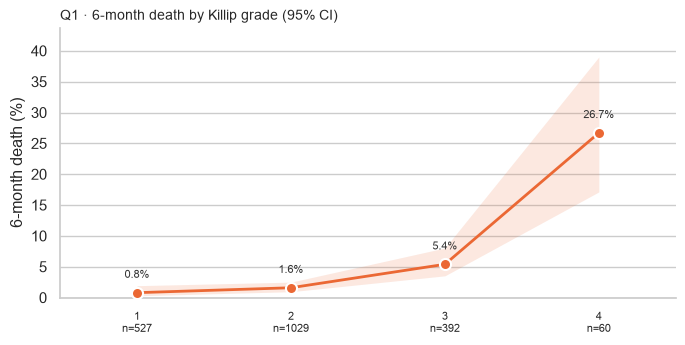

In [5]:
tab = rate_by("killip_grade", DEATH)
display(tab)
display(adjusted_or("death_within_6_months ~ killip + age_mid + male", show=["killip"]))
fig, ax = plt.subplots(figsize=(7, 3.6))
rate_by("killip_grade", DEATH, ax=ax, color=ORANGE, title="Q1 · 6-month death by Killip grade (95% CI)")
plt.tight_layout(); plt.show()

**Chart type — Q1**
* **Trend line with 95% CI band** — *6-month death by Killip grade 1–4.* How to read it: each dot is the event rate (%) in one group, joined in the groups' natural order; the shaded band is the 95% Wilson confidence interval and n is printed under each group. A line that climbs or falls step by step means a dose–response; a wide band means few patients or few events in that group.

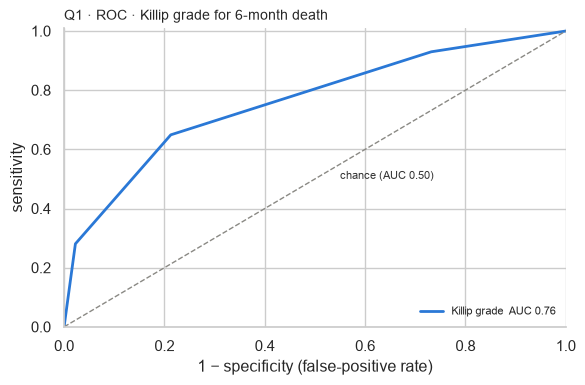

In [6]:
# Q1 · Extra chart: ROC curve of Killip grade as a bedside score
fig, ax = plt.subplots(figsize=(6, 4))
roc_plot({"Killip grade": "killip"}, DEATH, ax=ax, title="Q1 · ROC · Killip grade for 6-month death")
plt.tight_layout(); plt.show()

**Chart type — Q1 (additional charts)**
* **ROC curve** — *Killip grade as a score for 6-month death.* How to read it: plots sensitivity (deaths correctly flagged) against the false-positive rate for every possible cut-off of the marker. The more the curve bows towards the top-left corner the better; the dashed diagonal is chance. The AUC in the legend summarises it (0.5 = chance, 0.7 = acceptable, 0.8 = good, 1 = perfect).

In [ ]:
# Q1 · Correlation: Spearman rank correlation between the markers and outcomes of this question
display(spearman_table(["killip"], [DEATH, "death_within_28_days"]))

marker,correlated with,Spearman ρ,direction,strength,p-value,significant (p < 0.05),n
killip,6-month death,0.163,positive (+),weak,1.8e-13,yes,2008
killip,28-day death,0.175,positive (+),weak,2.5e-15,yes,2008


**Correlation:** Killip grade is positively correlated with both **6-month death (ρ = +0.16, p = 2 × 10⁻¹³)** and **28-day death (ρ = +0.18, p = 3 × 10⁻¹⁵)**: the higher the grade, the more deaths. ρ is only 'weak' because deaths are rare (2.8 %) — the effect itself is large (33-fold rate difference, adjusted OR 4.1 per grade).

**Evidence:** 6-month death climbs steeply with Killip grade — **0.8 % → 1.6 % → 5.4 % → 26.7 %** for grades 1 → 4 (chi-square p = 1.2 × 10⁻³¹; trend p = 2.3 × 10⁻¹⁸). Patients in cardiogenic shock (Killip 4) have a **33-fold** higher death rate than Killip 1. After adjusting for age and sex, each one-grade increase multiplies the odds of death by **4.1 (95 % CI 2.9–5.7)**.

**How it influences HF / action:** congestion and shock are the strongest single bedside signal of death in this cohort. Killip ≥ 3 should trigger an intensive pathway (senior review, close monitoring, early palliative discussion), and Killip is included in the mortality model in Category 4.

---
## Q2. Do patients with worse symptoms (NYHA class) die and return more often?
**Markers chosen:** `nyha_cardiac_function_classification` (II–IV) → 6-month death and 6-month readmission

**Why these markers / how they influence HF:** NYHA class grades **how much activity causes breathlessness**. Worse symptoms reflect a heart that cannot raise its output on demand.
Symptoms drive both mortality (advanced disease) and readmission (patients decompensate again), so we test both outcomes to see which one
NYHA really tracks.

6-month death by nyha_cardiac_function_classification: chi-square p = 0.00094 | trend p = 0.0077
6-month readmission by nyha_cardiac_function_classification: chi-square p = 1.1e-05 | trend p = 2e-06
                                     6-month death                        6-month readmission                         
                                                 n events rate %   95% CI                   n events rate %     95% CI
nyha_cardiac_function_classification                                                                                  
2                                              353      9    2.5  1.3–4.8                 353    103   29.2  24.7–34.1
3                                             1039     18    1.7  1.1–2.7                1039    395   38.0  35.1–41.0
4                                              616     30    4.9  3.4–6.9                 616    275   44.6  40.8–48.6
Logistic regression (n = 2008): re_admission_within_6_months ~ nyha + age_mid + male
  

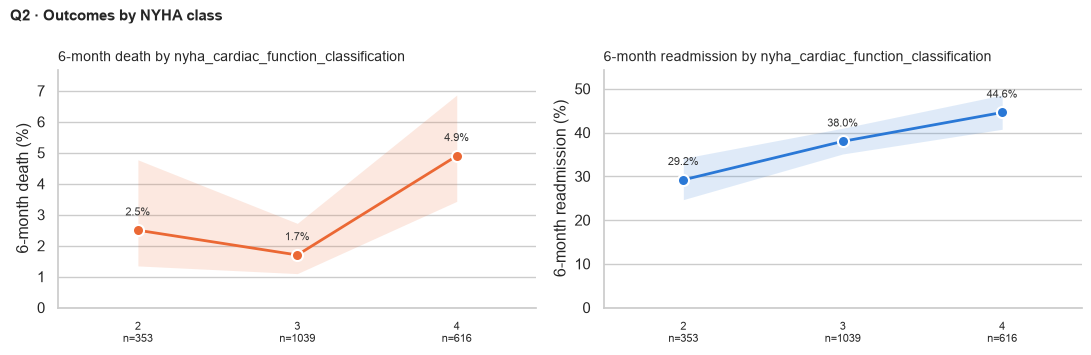

In [7]:
display(two_outcomes("nyha_cardiac_function_classification", suptitle="Q2 · Outcomes by NYHA class"))
display(adjusted_or("re_admission_within_6_months ~ nyha + age_mid + male", show=["nyha"]))

**Chart types — Q2**
* **Trend line with 95% CI band** — *left: 6-month death by NYHA class II–IV.* How to read it: each dot is the event rate (%) in one group, joined in the groups' natural order; the shaded band is the 95% Wilson confidence interval and n is printed under each group. A line that climbs or falls step by step means a dose–response; a wide band means few patients or few events in that group.
* **Trend line with 95% CI band** — *right: 6-month readmission by NYHA class.* How to read it: each dot is the event rate (%) in one group, joined in the groups' natural order; the shaded band is the 95% Wilson confidence interval and n is printed under each group. A line that climbs or falls step by step means a dose–response; a wide band means few patients or few events in that group.

Logistic regression (n = 2008): death_within_6_months ~ nyha + age_mid + male
Logistic regression (n = 2008): re_admission_within_6_months ~ nyha + age_mid + male


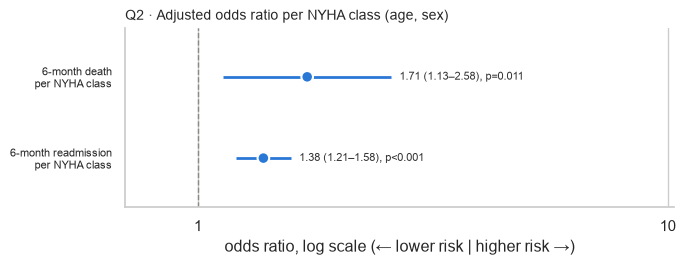

In [8]:
# Q2 · Extra chart: forest plot of adjusted odds ratios per NYHA class
fig, ax = plt.subplots(figsize=(7, 2.8))
ors = pd.concat([adjusted_or(f"{o} ~ nyha + age_mid + male", show=["nyha"]).rename(index={"nyha": f"{LABEL[o]}\nper NYHA class"})
                 for o in [DEATH, READM]])
forest(ors, ax=ax, title="Q2 · Adjusted odds ratio per NYHA class (age, sex)")
plt.tight_layout(); plt.show()

**Chart type — Q2 (additional charts)**
* **Forest plot** — *age/sex-adjusted OR per NYHA class for death and readmission.* How to read it: each dot is an odds ratio (OR) from a logistic regression, with its 95% CI as a horizontal line, on a log scale. The dashed line at OR = 1 means no association; to the right = higher odds of the outcome, to the left = lower. Blue = the CI excludes 1 (statistically significant), grey = not significant. The value, CI and p-value are written beside each line.

In [ ]:
# Q2 · Correlation: Spearman rank correlation between the markers and outcomes of this question
display(spearman_table(["nyha"], [DEATH, READM]))

marker,correlated with,Spearman ρ,direction,strength,p-value,significant (p < 0.05),n
nyha,6-month death,0.063,positive (+),negligible,0.0048,yes,2008
nyha,6-month readmission,0.105,positive (+),weak,2.3e-06,yes,2008


**Correlation:** NYHA class correlates positively with **readmission (ρ = +0.11, p = 2 × 10⁻⁶)** and only negligibly with **death (ρ = +0.06, p = 0.005)** — consistent with NYHA tracking readmission more than mortality.

**Evidence:** NYHA IV patients have the highest death rate (4.9 % vs 1.7–2.5 %, p = 0.0009), but the clearest gradient is for **readmission: 29.2 % (II) → 38.0 % (III) → 44.6 % (IV)** (trend p = 2 × 10⁻⁶). Each NYHA class raises the odds of readmission by **1.38 (1.21–1.58)** after age/sex adjustment.

**How it influences HF / action:** symptoms at rest mean the heart has no reserve, so small triggers (salt, missed diuretic, infection) cause a new admission. NYHA III–IV patients should leave with a scheduled early follow-up and diuretic self-management plan.

---
## Q3. Is a higher BNP linked to higher death and readmission?
**Markers chosen:** `brain_natriuretic_peptide` (quartiles) → 6-month death and readmission

**Why these markers / how they influence HF:** BNP is released by **stretched ventricular muscle**; the more pressure/volume overload, the higher the BNP. It is the guideline biomarker
for diagnosis and prognosis. We split BNP into quartiles (because it is very skewed) and test for a dose-response: if risk rises step by step
across quartiles, BNP is a genuine severity gradient.

6-month death by bnp_quartile: chi-square p = 0.0046 | trend p = 0.00049
6-month readmission by bnp_quartile: chi-square p = 0.12 | trend p = 0.075
             6-month death                        6-month readmission                         
                         n events rate %   95% CI                   n events rate %     95% CI
bnp_quartile                                                                                  
Q1 low                 502      7    1.4  0.7–2.9                 502    188   37.5  33.3–41.8
Q2                     520      9    1.7  0.9–3.3                 520    181   34.8  30.8–39.0
Q3                     484     18    3.7  2.4–5.8                 484    197   40.7  36.4–45.1
Q4 high                502     23    4.6  3.1–6.8                 502    207   41.2  37.0–45.6
                 min     max
bnp_quartile                
Q1 low           3.0   311.0
Q2             312.0   753.0
Q3             755.0  1721.0
Q4 high       1722.0  5000.0
log_bnp: Mann

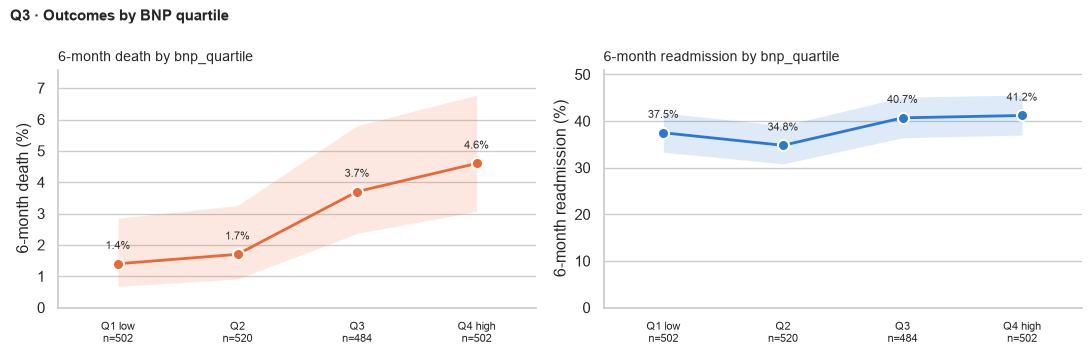

In [9]:
display(two_outcomes("bnp_quartile", suptitle="Q3 · Outcomes by BNP quartile"))
print(df.groupby("bnp_quartile", observed=True)["brain_natriuretic_peptide"].agg(["min", "max"]).round(0))
display(compare("log_bnp", DEATH))

**Chart types — Q3**
* **Trend line with 95% CI band** — *left: 6-month death by BNP quartile.* How to read it: each dot is the event rate (%) in one group, joined in the groups' natural order; the shaded band is the 95% Wilson confidence interval and n is printed under each group. A line that climbs or falls step by step means a dose–response; a wide band means few patients or few events in that group.
* **Trend line with 95% CI band** — *right: 6-month readmission by BNP quartile.* How to read it: each dot is the event rate (%) in one group, joined in the groups' natural order; the shaded band is the 95% Wilson confidence interval and n is printed under each group. A line that climbs or falls step by step means a dose–response; a wide band means few patients or few events in that group.

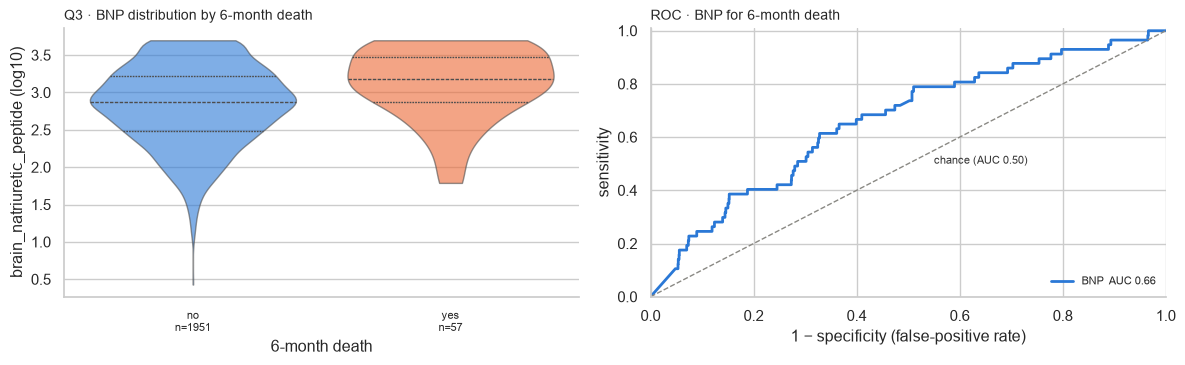

In [10]:
# Q3 · Extra charts: BNP distribution by outcome (violin) + ROC curve
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
violin("brain_natriuretic_peptide", DEATH, log=True, ax=axes[0], title="Q3 · BNP distribution by 6-month death")
roc_plot({"BNP": "brain_natriuretic_peptide"}, DEATH, ax=axes[1], title="ROC · BNP for 6-month death")
plt.tight_layout(); plt.show()

**Chart types — Q3 (additional charts)**
* **Violin plot** — *left: BNP (log10) in patients who died vs survived.* How to read it: the width of each shape shows how many patients have that value (a smoothed distribution); the dashed line is the median and the dotted lines are the quartiles. It shows the whole spread, e.g. whether one group is shifted or has a long tail, not just the average.
* **ROC curve** — *right: BNP for 6-month death.* How to read it: plots sensitivity (deaths correctly flagged) against the false-positive rate for every possible cut-off of the marker. The more the curve bows towards the top-left corner the better; the dashed diagonal is chance. The AUC in the legend summarises it (0.5 = chance, 0.7 = acceptable, 0.8 = good, 1 = perfect).

In [ ]:
# Q3 · Correlation: Spearman rank correlation between the markers and outcomes of this question
display(spearman_table(["brain_natriuretic_peptide"], [DEATH, READM]))

marker,correlated with,Spearman ρ,direction,strength,p-value,significant (p < 0.05),n
brain_natriuretic_peptide,6-month death,0.093,positive (+),negligible,3.1e-05,yes,2008
brain_natriuretic_peptide,6-month readmission,0.033,positive (+),negligible,0.14,no,2008


**Correlation:** BNP correlates positively with **6-month death (ρ = +0.09, p = 3 × 10⁻⁵)** but **not with readmission (ρ = +0.03, p = 0.14)** — the same split as the quartile rates.

**Evidence:** death doubles-to-triples across BNP quartiles — **1.4 % (Q1, ≤ 311 pg/mL) → 4.6 % (Q4, ≥ 1,722)** (trend p = 0.0005). Median BNP is about 1,480 pg/mL in patients who died vs 760 in survivors (log-BNP AUC 0.66). BNP is **not** clearly linked to readmission (34.8–41.2 %, trend p = 0.08).

**How it influences HF / action:** BNP measures the stretch that drives decompensation, so it grades mortality risk; but readmission seems driven by other factors (kidneys, comorbidity — see Q8, Q25). Use BNP for mortality risk, not alone for readmission risk.

---
## Q4. Does BNP reflect how weak the heart muscle is (LVEF)?
**Markers chosen:** `brain_natriuretic_peptide` vs `lvef` and HF phenotype

**Why these markers / how they influence HF:** A weaker ventricle (low LVEF) dilates and its wall stress increases, which should raise BNP. If BNP is strongly (negatively) correlated with LVEF,
BNP can partly stand in for echocardiography — important because 68 % of patients have no LVEF.

Spearman rho(lvef, brain_natriuretic_peptide) = -0.542, p = 8.5e-50, n = 635
              count    25%     50%     75%
hf_phenotype                              
HFrEF ≤40     146.0  910.0  1629.0  2704.0
HFmrEF 41-49  138.0  516.0  1211.0  2648.0
HFpEF ≥50     351.0  184.0   412.0   847.0
Kruskal-Wallis p = 4.3e-36


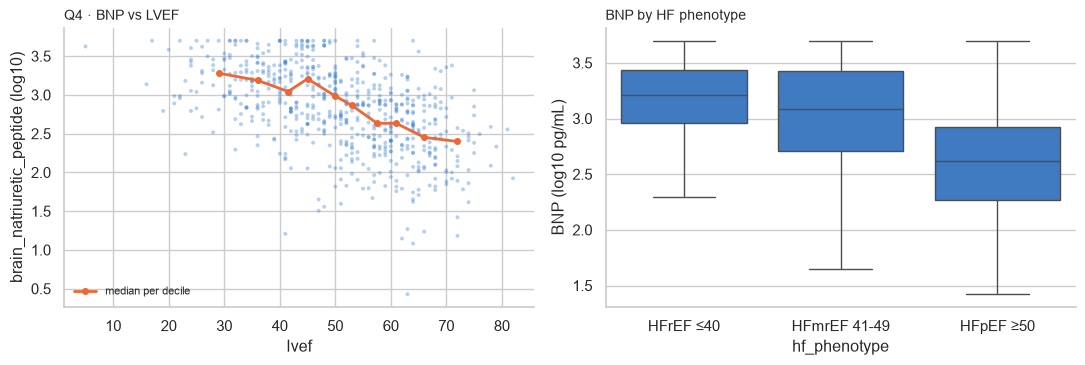

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
corr("lvef", "brain_natriuretic_peptide", ax=axes[0], logy=True)
axes[0].set_title("Q4 · BNP vs LVEF", loc="left", fontsize=10)
d = df.dropna(subset=["hf_phenotype", "log_bnp"])
sns.boxplot(data=d, x="hf_phenotype", y="log_bnp", ax=axes[1], color=BLUE, showfliers=False)
axes[1].set_ylabel("BNP (log10 pg/mL)"); axes[1].set_title("BNP by HF phenotype", loc="left", fontsize=10)
plt.tight_layout(); plt.show()
display(d.groupby("hf_phenotype", observed=True)["brain_natriuretic_peptide"].describe()[["count", "25%", "50%", "75%"]].round(0))
print("Kruskal-Wallis p =", f"{kruskal(*[g['log_bnp'] for _, g in d.groupby('hf_phenotype', observed=True)]).pvalue:.2g}")

**Chart types — Q4**
* **Scatter plot with binned-median trend line** — *left: BNP (log10) against LVEF.* How to read it: each blue dot is one patient; the orange line joins the median y-value within each tenth (decile) of x, so it shows the trend without being pulled by outliers. The Spearman ρ printed above the chart gives its strength.
* **Box plot** — *right: BNP (log10) in HFrEF, HFmrEF and HFpEF.* How to read it: the box covers the middle 50 % of patients (Q1 to Q3) and the line inside it is the median; whiskers reach the furthest values within 1.5 × IQR (outliers hidden). Compare the medians and how far the boxes overlap.

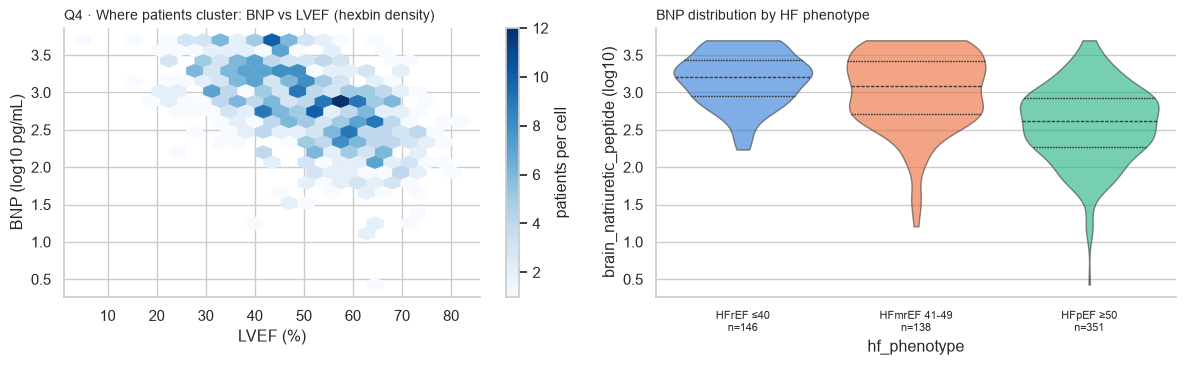

In [12]:
# Q4 · Extra charts: density hexbin of BNP vs LVEF + violin of BNP by HF phenotype
d = df.dropna(subset=["lvef", "brain_natriuretic_peptide"])
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
hb = axes[0].hexbin(d["lvef"], np.log10(d["brain_natriuretic_peptide"]), gridsize=22, cmap="Blues", mincnt=1, linewidths=0.2)
fig.colorbar(hb, ax=axes[0], label="patients per cell")
axes[0].set_xlabel("LVEF (%)"); axes[0].set_ylabel("BNP (log10 pg/mL)")
axes[0].set_title("Q4 · Where patients cluster: BNP vs LVEF (hexbin density)", loc="left", fontsize=10)
violin("brain_natriuretic_peptide", "hf_phenotype", log=True, ax=axes[1], title="BNP distribution by HF phenotype")
plt.tight_layout(); plt.show()

**Chart types — Q4 (additional charts)**
* **Hexbin density plot** — *left: BNP (log10) against LVEF.* How to read it: the plane is divided into hexagons and each is shaded by how many patients fall in it (darker = more). Unlike a plain scatter, it shows where patients concentrate when many points overlap.
* **Violin plot** — *right: BNP (log10) by HF phenotype.* How to read it: the width of each shape shows how many patients have that value (a smoothed distribution); the dashed line is the median and the dotted lines are the quartiles. It shows the whole spread, e.g. whether one group is shifted or has a long tail, not just the average.

In [ ]:
# Q4 · Correlation: Spearman rank correlation between the markers and outcomes of this question
display(spearman_table(["brain_natriuretic_peptide"], ["lvef", DEATH]))

marker,correlated with,Spearman ρ,direction,strength,p-value,significant (p < 0.05),n
brain_natriuretic_peptide,lvef,-0.542,negative (−),strong,8.5e-50,yes,635
brain_natriuretic_peptide,6-month death,0.093,positive (+),negligible,3.1e-05,yes,2008


**Correlation:** BNP and LVEF are **strongly negatively correlated (ρ = −0.54, p = 10⁻⁴⁹, n = 635)**: the weaker the ventricle, the higher the BNP. BNP's correlation with death is positive but small (ρ = +0.09) because deaths are rare.

**Evidence:** BNP is **strongly and negatively correlated with LVEF** (Spearman ρ = −0.54, p = 10⁻⁴⁹, n = 635). Median BNP is **1,629 pg/mL in HFrEF**, 1,211 in HFmrEF and **412 in HFpEF** (Kruskal–Wallis p = 4 × 10⁻³⁶).

**How it influences HF / action:** a weaker ventricle is more stretched and releases more BNP. Because 68 % of patients have no echo, a very high BNP can flag likely HFrEF and prioritise them for echocardiography and HFrEF drugs — this is the basis of the HFrEF model in Category 4.

---
## Q5. Is a dilated left ventricle associated with a weaker ejection fraction?
**Markers chosen:** `left_ventricular_end_diastolic_diameter_lv` (mm) vs `lvef` (%)

**Why these markers / how they influence HF:** After injury the left ventricle **remodels**: it dilates to maintain stroke volume, but dilation increases wall stress and further weakens contraction.
A strong negative correlation between LV diameter and LVEF would confirm this remodelling pattern in the cohort and identify LV size as an
alternative echo marker of systolic dysfunction.

Spearman rho(left_ventricular_end_diastolic_diameter_lv, lvef) = -0.662, p = 1.5e-76, n = 597
             count  median
LV diameter               
≤55 mm         377    57.0
56-65 mm       138    44.0
>65 mm          82    35.0
hf_phenotype                                HFrEF ≤40  HFmrEF 41-49  HFpEF ≥50
left_ventricular_end_diastolic_diameter_lv                                    
≤55 mm                                            9.0          17.5       73.5
56-65 mm                                         34.1          36.2       29.7
>65 mm                                           72.0          19.5        8.5


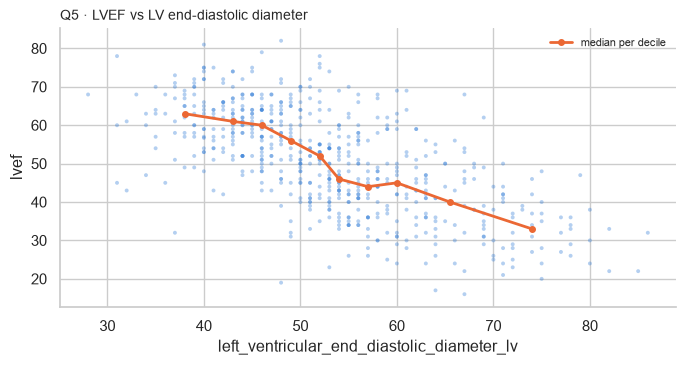

In [13]:
fig, ax = plt.subplots(figsize=(7, 3.8))
corr("left_ventricular_end_diastolic_diameter_lv", "lvef", ax=ax)
ax.set_title("Q5 · LVEF vs LV end-diastolic diameter", loc="left", fontsize=10)
plt.tight_layout(); plt.show()
dil = pd.cut(df["left_ventricular_end_diastolic_diameter_lv"], [0, 55, 65, 200], labels=["≤55 mm", "56-65 mm", ">65 mm"])
display(df.groupby(dil, observed=True)["lvef"].agg(["count", "median"]).rename_axis("LV diameter"))
display(pd.crosstab(dil, df["hf_phenotype"], normalize="index").mul(100).round(1))

**Chart type — Q5**
* **Scatter plot with binned-median trend line** — *LVEF against LV end-diastolic diameter.* How to read it: each blue dot is one patient; the orange line joins the median y-value within each tenth (decile) of x, so it shows the trend without being pulled by outliers. The Spearman ρ printed above the chart gives its strength.

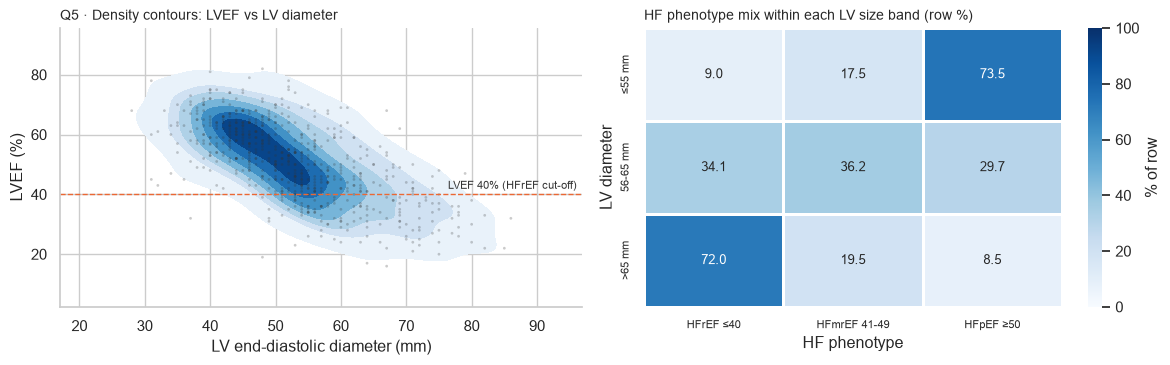

In [14]:
# Q5 · Extra charts: 2-D density of LVEF vs LV diameter + heatmap of phenotype mix by LV size
d = df.dropna(subset=["left_ventricular_end_diastolic_diameter_lv", "lvef"])
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
sns.kdeplot(data=d, x="left_ventricular_end_diastolic_diameter_lv", y="lvef", fill=True, cmap="Blues", levels=8, thresh=0.05, ax=axes[0])
axes[0].scatter(d["left_ventricular_end_diastolic_diameter_lv"], d["lvef"], s=4, color=INK, alpha=0.25, edgecolors="none")
axes[0].axhline(40, color=ORANGE, ls="--", lw=1); axes[0].annotate("LVEF 40% (HFrEF cut-off)", (axes[0].get_xlim()[1], 40),
                                                                  xytext=(-4, 4), textcoords="offset points", ha="right", fontsize=8, color=INK)
axes[0].set_xlabel("LV end-diastolic diameter (mm)"); axes[0].set_ylabel("LVEF (%)")
axes[0].set_title("Q5 · Density contours: LVEF vs LV diameter", loc="left", fontsize=10)
dil5 = pd.cut(df["left_ventricular_end_diastolic_diameter_lv"], [0, 55, 65, 200], labels=["≤55 mm", "56-65 mm", ">65 mm"])
heat(pd.crosstab(dil5, df["hf_phenotype"], normalize="index").mul(100), ax=axes[1], vmin=0, vmax=100,
     title="HF phenotype mix within each LV size band (row %)", cbar_label="% of row")
axes[1].set_xlabel("HF phenotype"); axes[1].set_ylabel("LV diameter")
plt.tight_layout(); plt.show()

**Chart types — Q5 (additional charts)**
* **2-D density contour plot** — *left: LVEF against LV diameter, with the 40 % HFrEF cut-off.* How to read it: the shaded contours show where patients concentrate (darkest = densest), like a topographic map; the grey dots are individual patients. The tilt of the contours shows the direction of the relationship.
* **Heatmap** — *right: HF-phenotype mix (row %) within each LV-diameter band.* How to read it: each cell is shaded by its value on a single-colour scale (darker = higher) and the number is written inside the cell, so you can scan for the darkest corner and still read exact values.

In [ ]:
# Q5 · Correlation: Spearman rank correlation between the markers and outcomes of this question
display(spearman_table(["left_ventricular_end_diastolic_diameter_lv"], ["lvef"]))

marker,correlated with,Spearman ρ,direction,strength,p-value,significant (p < 0.05),n
left_ventricular_end_diastolic_diameter_lv,lvef,-0.662,negative (−),strong,1.5e-76,yes,597


**Correlation:** LV diameter and LVEF are **strongly negatively correlated (ρ = −0.66, p = 10⁻⁷⁶, n = 597)** — the strongest correlation in this notebook: a larger ventricle ejects a smaller fraction of its volume.

**Evidence:** LV diameter and LVEF are **strongly negatively correlated (ρ = −0.66, p = 10⁻⁷⁶, n = 597)**. Median LVEF falls from 57 % (≤ 55 mm) to 44 % (56–65 mm) to **35 % (> 65 mm)**; **72 %** of ventricles > 65 mm are HFrEF vs 9 % of those ≤ 55 mm.

**How it influences HF / action:** this confirms the remodelling pathway — dilation and weak contraction go together. LV diameter (available for 1,309 patients, twice as many as LVEF) can serve as a surrogate systolic-function marker.

---
## Q6. Is ventricular dilation (remodelling) more prognostic than the EF category?
**Markers chosen:** `hf_phenotype` (from `lvef`) and `left_ventricular_end_diastolic_diameter_lv` → 6-month death and readmission

**Why these markers / how they influence HF:** The EF phenotype decides which drugs work, and HFrEF is classically thought to carry the worst prognosis. But EF is a single snapshot,
whereas a **dilated ventricle** reflects long-term remodelling (previous question) and higher wall stress. We compare the two echo markers
head-to-head. (Echo subset only: LVEF n = 635, LV diameter n = 1,309.)

6-month death by hf_phenotype: chi-square p = 0.58
6-month readmission by hf_phenotype: chi-square p = 0.29
             6-month death                        6-month readmission                         
                         n events rate %   95% CI                   n events rate %     95% CI
hf_phenotype                                                                                  
HFrEF ≤40              146      2    1.4  0.4–4.9                 146     64   43.8  36.0–51.9
HFmrEF 41-49           138      1    0.7  0.1–4.0                 138     48   34.8  27.3–43.0
HFpEF ≥50              351      7    2.0  1.0–4.1                 351    142   40.5  35.5–45.7
6-month death by lv_dilation: chi-square p = 0.00052 | trend p = 0.00013
6-month readmission by lv_dilation: chi-square p = 0.046 | trend p = 0.02
            6-month death                         6-month readmission                         
                        n events rate %    95% CI                   n events rat

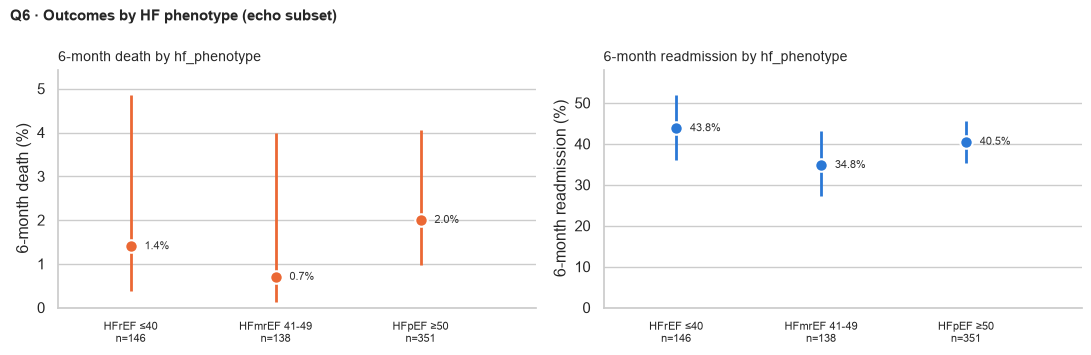

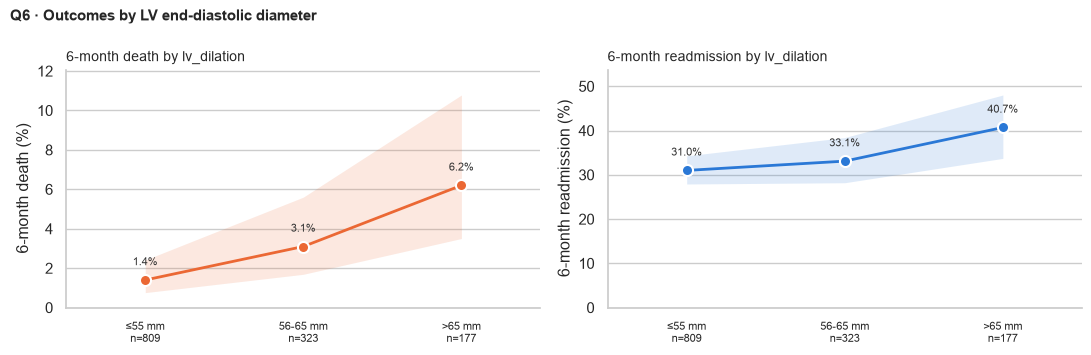

In [15]:
display(two_outcomes("hf_phenotype", ordered=False, suptitle="Q6 · Outcomes by HF phenotype (echo subset)"))
df["lv_dilation"] = pd.cut(df["left_ventricular_end_diastolic_diameter_lv"], [0, 55, 65, 200], labels=["≤55 mm", "56-65 mm", ">65 mm"])
display(two_outcomes("lv_dilation", suptitle="Q6 · Outcomes by LV end-diastolic diameter"))
display(compare("left_ventricular_end_diastolic_diameter_lv", DEATH))
display(pd.crosstab(df["hf_phenotype"], df["gender"], normalize="index").mul(100).round(1))

**Chart types — Q6**
* **Dot plot with 95% CI whiskers** — *first figure: 6-month death and readmission by HF phenotype (EF category, unordered).* How to read it: each dot is the event rate (%) in one group; the groups have no natural order, so they are not joined. The vertical whisker is the 95% Wilson confidence interval — when two groups' whiskers do not overlap, the difference is unlikely to be chance.
* **Trend line with 95% CI band** — *second figure: 6-month death and readmission by LV diameter band (≤55, 56–65, >65 mm).* How to read it: each dot is the event rate (%) in one group, joined in the groups' natural order; the shaded band is the 95% Wilson confidence interval and n is printed under each group. A line that climbs or falls step by step means a dose–response; a wide band means few patients or few events in that group.

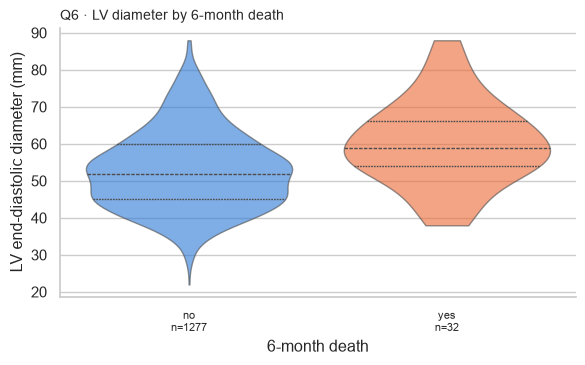

In [16]:
# Q6 · Extra chart: LV diameter distribution by 6-month death (violin)
fig, ax = plt.subplots(figsize=(6, 3.8))
violin("left_ventricular_end_diastolic_diameter_lv", DEATH, ax=ax, title="Q6 · LV diameter by 6-month death")
ax.set_ylabel("LV end-diastolic diameter (mm)")
plt.tight_layout(); plt.show()

**Chart type — Q6 (additional charts)**
* **Violin plot** — *LV end-diastolic diameter in patients who died vs survived.* How to read it: the width of each shape shows how many patients have that value (a smoothed distribution); the dashed line is the median and the dotted lines are the quartiles. It shows the whole spread, e.g. whether one group is shifted or has a long tail, not just the average.

In [ ]:
# Q6 · Correlation: Spearman rank correlation between the markers and outcomes of this question
display(spearman_table(["lvef", "left_ventricular_end_diastolic_diameter_lv"], [DEATH, READM]))

marker,correlated with,Spearman ρ,direction,strength,p-value,significant (p < 0.05),n
lvef,6-month death,0.006,positive (+),negligible,0.87,no,635
lvef,6-month readmission,-0.027,negative (−),negligible,0.5,no,635
left_ventricular_end_diastolic_diameter_lv,6-month death,0.100,positive (+),weak,0.00029,yes,1309
left_ventricular_end_diastolic_diameter_lv,6-month readmission,0.081,positive (+),negligible,0.0034,yes,1309


**Correlation:** LVEF shows **no correlation** with death (ρ = +0.01, p = 0.87) or readmission (ρ = −0.03, p = 0.50), whereas **LV diameter correlates positively with both** (death ρ = +0.10, p = 0.0003; readmission ρ = +0.08, p = 0.003) — dilation, not the EF category, carries the signal.

**Evidence:** EF phenotype does **not** separate outcomes (6-month death 0.7–2.0 %, p = 0.58; readmission 34.8–43.8 %, p = 0.29) — HFpEF patients do as badly as HFrEF. In contrast, **LV dilation shows a clear gradient: death 1.4 % → 3.1 % → 6.2 %** (≤ 55 → > 65 mm; trend p = 0.0001) and readmission 31.0 % → 40.7 % (trend p = 0.02). Median LV diameter is 59 mm in patients who died vs 52 mm (AUC 0.69). HFpEF is 64 % female.

**How it influences HF / action:** in this elderly cohort, remodelling (a dilated ventricle) carries more prognostic information than the EF category. HFpEF must not be treated as 'low risk'. Report LV diameter alongside EF on echo reports.

---
## Q7. Do high filling pressures on echo (mitral E-wave velocity) predict readmission?
**Markers chosen:** `mitral_valve_ems` (E-wave, m/s) and `brain_natriuretic_peptide` → 6-month readmission

**Why these markers / how they influence HF:** The mitral **E-wave** is the speed of blood flowing into the left ventricle in early diastole. When left-atrial pressure is high (a congested,
stiff heart), blood rushes in faster, so a high E velocity is an echo sign of **elevated filling pressure** — the pressure that pushes fluid
into the lungs. Persistently high filling pressure should mean early re-decompensation. We also check that E velocity tracks BNP.

           min   max
e_wave_q            
Q1 low    0.03  0.76
Q2        0.77  1.00
Q3        1.01  1.26
Q4 high   1.27  3.90
6-month death by e_wave_q: chi-square p = 0.5 | trend p = 0.43
6-month readmission by e_wave_q: chi-square p = 0.00026 | trend p = 1.4e-05
         6-month death                        6-month readmission                         
                     n events rate %   95% CI                   n events rate %     95% CI
e_wave_q                                                                                  
Q1 low             245      4    1.6  0.6–4.1                 245     55   22.4  17.7–28.1
Q2                 242      6    2.5  1.1–5.3                 242     67   27.7  22.4–33.6
Q3                 240      2    0.8  0.2–3.0                 240     84   35.0  29.2–41.2
Q4 high            242      3    1.2  0.4–3.6                 242     95   39.3  33.3–45.5
mitral_valve_ems: Mann-Whitney p = 8.6e-06 | AUC for 6-month readmission = 0.589
                 

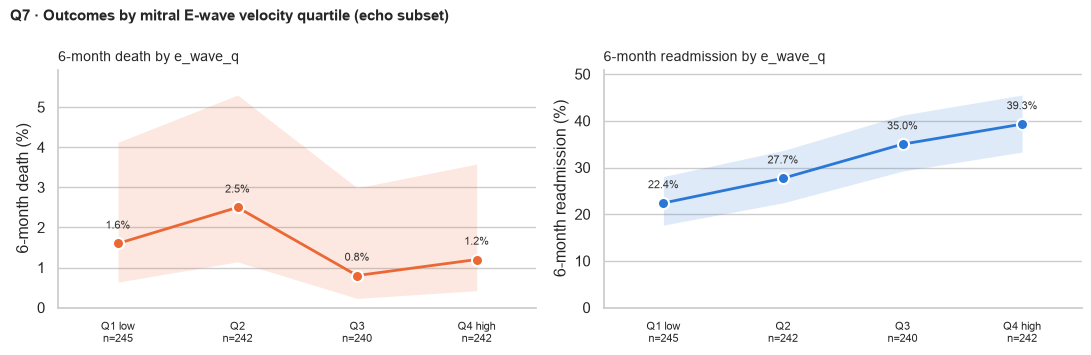

In [17]:
df["e_wave_q"] = pd.qcut(df["mitral_valve_ems"], 4, labels=["Q1 low", "Q2", "Q3", "Q4 high"])
print(df.groupby("e_wave_q", observed=True)["mitral_valve_ems"].agg(["min", "max"]))
display(two_outcomes("e_wave_q", suptitle="Q7 · Outcomes by mitral E-wave velocity quartile (echo subset)"))
display(compare("mitral_valve_ems", READM))
corr("mitral_valve_ems", "brain_natriuretic_peptide")

**Chart type — Q7**
* **Trend line with 95% CI band** — *6-month death (left) and readmission (right) by mitral E-wave quartile.* How to read it: each dot is the event rate (%) in one group, joined in the groups' natural order; the shaded band is the 95% Wilson confidence interval and n is printed under each group. A line that climbs or falls step by step means a dose–response; a wide band means few patients or few events in that group.

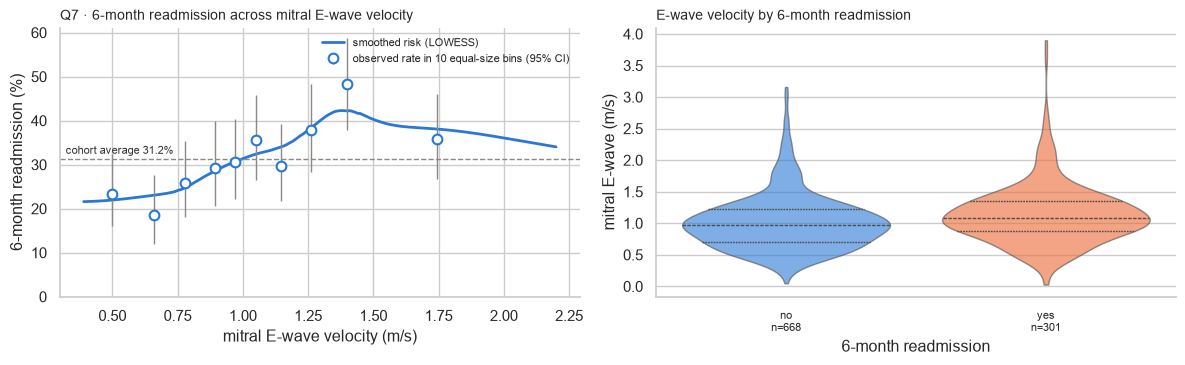

In [18]:
# Q7 · Extra charts: continuous risk curve of readmission vs E-wave + violin by readmission
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
risk_curve("mitral_valve_ems", READM, ax=axes[0], title="Q7 · 6-month readmission across mitral E-wave velocity")
axes[0].set_xlabel("mitral E-wave velocity (m/s)")
violin("mitral_valve_ems", READM, ax=axes[1], title="E-wave velocity by 6-month readmission")
axes[1].set_ylabel("mitral E-wave (m/s)")
plt.tight_layout(); plt.show()

**Chart types — Q7 (additional charts)**
* **Risk curve (binned rates + LOWESS smooth)** — *left: 6-month readmission across mitral E-wave velocity.* How to read it: the marker is kept continuous instead of being cut into groups. Open dots are the observed event rate in equal-size bins of the marker (with 95% CI); the solid line is a LOWESS smooth of the risk; the dashed line is the cohort average. It reveals the shape of the risk — straight, threshold or U-shaped. Only the central 95 % of values is shown, because sparse tails make the smooth unreliable.
* **Violin plot** — *right: E-wave velocity by readmission.* How to read it: the width of each shape shows how many patients have that value (a smoothed distribution); the dashed line is the median and the dotted lines are the quartiles. It shows the whole spread, e.g. whether one group is shifted or has a long tail, not just the average.

In [ ]:
# Q7 · Correlation: Spearman rank correlation between the markers and outcomes of this question
display(spearman_table(["mitral_valve_ems"], [READM, DEATH, "brain_natriuretic_peptide"]))

marker,correlated with,Spearman ρ,direction,strength,p-value,significant (p < 0.05),n
mitral_valve_ems,6-month readmission,0.143,positive (+),weak,7.9e-06,yes,969
mitral_valve_ems,6-month death,-0.022,negative (−),negligible,0.5,no,969
mitral_valve_ems,brain_natriuretic_peptide,0.034,positive (+),negligible,0.29,no,969


**Correlation:** E-wave velocity correlates positively with **readmission (ρ = +0.14, p = 8 × 10⁻⁶)** but not with death (ρ = −0.02, p = 0.5) and **not with BNP (ρ = +0.03, p = 0.29)** — so it adds information that BNP does not.

**Evidence:** readmission rises steadily with E-wave velocity — **22.4 % (lowest quartile, ≤ 0.76 m/s) → 39.3 % (highest, ≥ 1.27 m/s)** (trend p = 1.4 × 10⁻⁵, n = 969). Patients readmitted had a higher median E velocity (1.09 vs 0.98 m/s, p = 9 × 10⁻⁶). E velocity is **not** related to death (p = 0.5) and is **not** correlated with BNP (ρ = 0.03, p = 0.29).

**How it influences HF / action:** high filling pressure means the lungs congest easily, so these patients re-decompensate — a readmission (not mortality) signal. Because it is independent of BNP, it adds *new* information: an echo showing a high E-wave should prompt tighter diuretic follow-up.

---
# B. Kidneys, electrolytes, metabolism and nutrition (Q8–Q14)

---
## Q8. Does kidney function (eGFR) drive death and readmission — the cardiorenal link?
**Markers chosen:** `glomerular_filtration_rate` (KDIGO stage) → 6-month death and readmission

**Why these markers / how they influence HF:** In **cardiorenal syndrome** a failing heart lowers kidney perfusion and raises venous pressure, and failing kidneys retain salt and water,
which loads the heart further. Low eGFR also forces lower doses of key drugs. Category 2 showed 44 % have eGFR < 60, so this is a
high-prevalence, high-impact question.

6-month death by ckd_stage: chi-square p = 1.1e-06 | trend p = 1e-05
6-month readmission by ckd_stage: chi-square p = 2.1e-07 | trend p = 7e-06
          6-month death                         6-month readmission                         
                      n events rate %    95% CI                   n events rate %     95% CI
ckd_stage                                                                                   
<30                 252     21    8.3  5.5–12.4                 252     98   38.9  33.1–45.0
30-44               304      9    3.0   1.6–5.5                 304    152   50.0  44.4–55.6
45-59               330      5    1.5   0.6–3.5                 330    147   44.5  39.3–49.9
60-89               631     14    2.2   1.3–3.7                 631    225   35.7  32.0–39.5
≥90                 491      8    1.6   0.8–3.2                 491    151   30.8  26.8–35.0
Logistic regression (n = 2008): re_admission_within_6_months ~ I(glomerular_filtration_rate/10) + age_mid + male

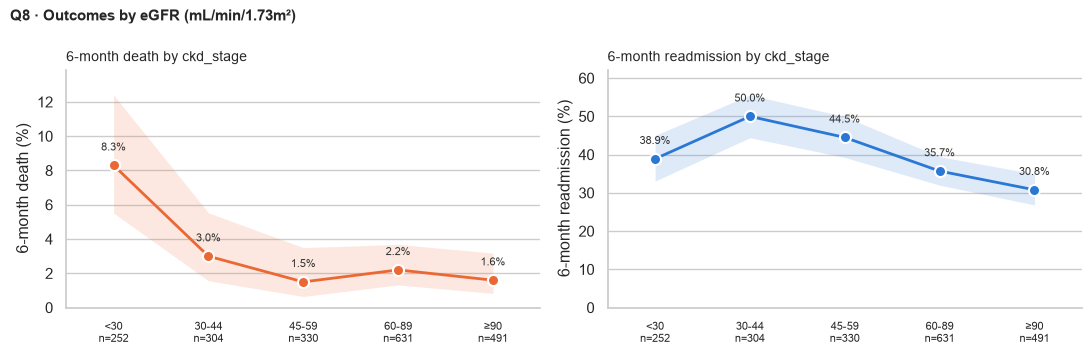

In [19]:
display(two_outcomes("ckd_stage", suptitle="Q8 · Outcomes by eGFR (mL/min/1.73m²)"))
display(adjusted_or("re_admission_within_6_months ~ I(glomerular_filtration_rate/10) + age_mid + male + nyha",
                    show=["glomerular"]))
print("OR is per 10 mL/min/1.73m² higher eGFR")

**Chart type — Q8**
* **Trend line with 95% CI band** — *6-month death (left) and readmission (right) by eGFR stage.* How to read it: each dot is the event rate (%) in one group, joined in the groups' natural order; the shaded band is the 95% Wilson confidence interval and n is printed under each group. A line that climbs or falls step by step means a dose–response; a wide band means few patients or few events in that group.

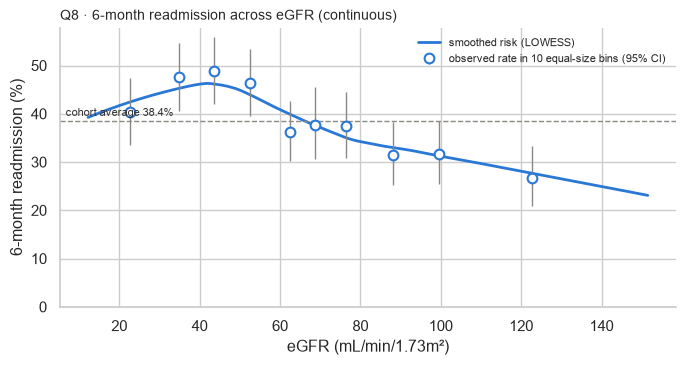

In [20]:
# Q8 · Extra chart: continuous readmission risk curve across eGFR
fig, ax = plt.subplots(figsize=(7, 3.8))
risk_curve("glomerular_filtration_rate", READM, ax=ax, title="Q8 · 6-month readmission across eGFR (continuous)")
ax.set_xlabel("eGFR (mL/min/1.73m²)")
plt.tight_layout(); plt.show()

**Chart type — Q8 (additional charts)**
* **Risk curve (binned rates + LOWESS smooth)** — *6-month readmission across eGFR as a continuous value.* How to read it: the marker is kept continuous instead of being cut into groups. Open dots are the observed event rate in equal-size bins of the marker (with 95% CI); the solid line is a LOWESS smooth of the risk; the dashed line is the cohort average. It reveals the shape of the risk — straight, threshold or U-shaped. Only the central 95 % of values is shown, because sparse tails make the smooth unreliable.

In [ ]:
# Q8 · Correlation: Spearman rank correlation between the markers and outcomes of this question
display(spearman_table(["glomerular_filtration_rate"], [DEATH, READM]))

marker,correlated with,Spearman ρ,direction,strength,p-value,significant (p < 0.05),n
glomerular_filtration_rate,6-month death,-0.097,negative (−),negligible,1.4e-05,yes,2008
glomerular_filtration_rate,6-month readmission,-0.109,negative (−),weak,9.5e-07,yes,2008


**Correlation:** eGFR correlates negatively with **death (ρ = −0.10, p = 10⁻⁵)** and **readmission (ρ = −0.11, p = 10⁻⁶)**: lower kidney function goes with worse outcomes. The readmission link is not linear (it peaks at eGFR 30–44, see the risk curve), so a single ρ understates it.

**Evidence:** the kidney–heart link is clear. **6-month death is 8.3 % with eGFR < 30** vs 1.5–2.3 % with eGFR ≥ 45 (trend p = 10⁻⁵). **Readmission rises from 30.8 % (eGFR ≥ 90) to 50.0 % (30–44)** (trend p = 7 × 10⁻⁶). After adjusting for age, sex and NYHA, each 10-unit fall in eGFR raises readmission odds by about 5 % (OR 0.954 per 10 higher, 95 % CI 0.927–0.981).

**How it influences HF / action:** cardiorenal syndrome drives both outcomes. Kidney function should be checked before discharge and 1–2 weeks after; patients with eGFR < 45 need joint cardiology–nephrology planning of diuretic and RAAS-drug doses.

---
## Q9. Which kidney marker best separates patients who die: urea, creatinine, cystatin C or eGFR?
**Markers chosen:** `urea`, `creatinine_enzymatic_method`, `cystatin`, `glomerular_filtration_rate` → 6-month death

**Why these markers / how they influence HF:** All four measure kidney function, but they react differently: **urea** also rises with low cardiac output and neurohormonal activation
(so it is partly a heart marker), creatinine depends on muscle mass (low in this lean, elderly cohort), and cystatin C does not.
Comparing their discrimination (AUC) tells us which marker to use in the dashboard and the model.

                                n  median (died)  median (survived)  AUC for 6-month death Mann-Whitney p
marker                                                                                                   
urea                         2008          11.62               8.03                   0.69          2e-06
creatinine_enzymatic_method  2008         121.60              86.90                   0.68          4e-06
cystatin                     2008           1.96               1.55                   0.66          5e-05
glomerular_filtration_rate   2008          38.87              64.79                   0.67          1e-05


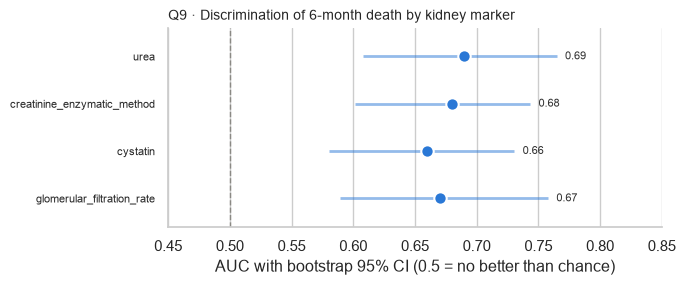

In [21]:
rows = []
for v in ["urea", "creatinine_enzymatic_method", "cystatin", "glomerular_filtration_rate"]:
    d = df[[v, DEATH]].dropna()
    auc = roc_auc_score(d[DEATH], d[v] if v != "glomerular_filtration_rate" else -d[v])
    rows.append({"marker": v, "n": len(d), "median (died)": d.loc[d[DEATH] == 1, v].median(),
                 "median (survived)": d.loc[d[DEATH] == 0, v].median(),
                 "AUC for 6-month death": round(auc, 3), "Mann-Whitney p": f"{mannwhitneyu(d.loc[d[DEATH]==1, v], d.loc[d[DEATH]==0, v]).pvalue:.1g}"})
res = pd.DataFrame(rows).set_index("marker").round(2)
display(res)
# Dot plot of AUC with bootstrap 95% CI (500 resamples) - overlapping CIs mean the markers are not clearly different
rng = np.random.default_rng(8)
ci_lo, ci_hi = [], []
for v in res.index:
    d = df[[v, DEATH]].dropna(); yv = d[DEATH].to_numpy(); sv = (-d[v] if v == "glomerular_filtration_rate" else d[v]).to_numpy()
    boots = [roc_auc_score(yv[i], sv[i]) for i in (rng.integers(0, len(yv), len(yv)) for _ in range(500)) if yv[i].min() != yv[i].max()]
    ci_lo.append(np.percentile(boots, 2.5)); ci_hi.append(np.percentile(boots, 97.5))
auc = res["AUC for 6-month death"].to_numpy(); yy = np.arange(len(res))[::-1]
fig, ax = plt.subplots(figsize=(7, 3))
ax.hlines(yy, ci_lo, ci_hi, color=BLUE, lw=2, alpha=0.5)
ax.scatter(auc, yy, s=80, color=BLUE, edgecolor="white", linewidth=1.5, zorder=3)
for yi, a, h in zip(yy, auc, ci_hi):
    ax.annotate(f"{a:.2f}", (h, yi), xytext=(6, 0), textcoords="offset points", va="center", fontsize=8, color="#333333")
ax.set_yticks(yy); ax.set_yticklabels(res.index, fontsize=8); ax.set_ylim(-0.6, len(res) - 0.4)
ax.axvline(0.5, color=GREY, ls="--", lw=1); ax.set_xlim(0.45, 0.85); ax.grid(axis="y", visible=False)
ax.set_xlabel("AUC with bootstrap 95% CI (0.5 = no better than chance)")
ax.set_title("Q9 · Discrimination of 6-month death by kidney marker", loc="left", fontsize=10)
plt.tight_layout(); plt.show()

**Chart type — Q9**
* **Dot plot of AUC with bootstrap 95% CI** — *AUC of urea, creatinine, cystatin C and eGFR for 6-month death.* How to read it: each dot is one marker's AUC for 6-month death and the horizontal line is its 95% confidence interval from 500 bootstrap resamples. The dashed line at 0.5 is chance; heavily overlapping lines mean the markers perform about the same.

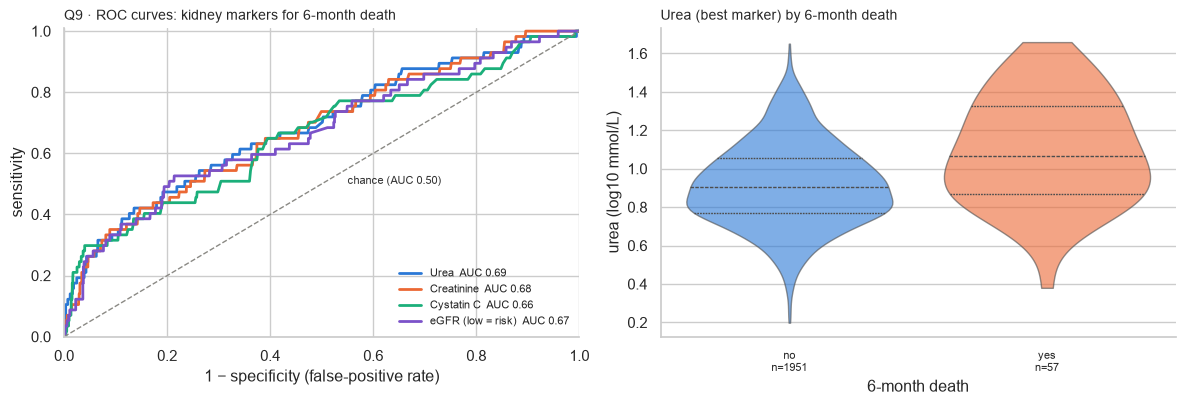

In [22]:
# Q9 · Extra charts: ROC curves of the four kidney markers + urea distribution by death
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
roc_plot({"Urea": "urea", "Creatinine": "creatinine_enzymatic_method", "Cystatin C": "cystatin", "eGFR (low = risk)": "-glomerular_filtration_rate"},
         DEATH, ax=axes[0], title="Q9 · ROC curves: kidney markers for 6-month death")
violin("urea", DEATH, log=True, ax=axes[1], title="Urea (best marker) by 6-month death")
axes[1].set_ylabel("urea (log10 mmol/L)")
plt.tight_layout(); plt.show()

**Chart types — Q9 (additional charts)**
* **ROC curve** — *left: the four kidney markers overlaid for 6-month death (eGFR reversed: low = risk).* How to read it: plots sensitivity (deaths correctly flagged) against the false-positive rate for every possible cut-off of the marker. The more the curve bows towards the top-left corner the better; the dashed diagonal is chance. The AUC in the legend summarises it (0.5 = chance, 0.7 = acceptable, 0.8 = good, 1 = perfect).
* **Violin plot** — *right: urea (log10) in patients who died vs survived.* How to read it: the width of each shape shows how many patients have that value (a smoothed distribution); the dashed line is the median and the dotted lines are the quartiles. It shows the whole spread, e.g. whether one group is shifted or has a long tail, not just the average.

In [ ]:
# Q9 · Correlation: Spearman rank correlation between the markers and outcomes of this question
display(spearman_table(["urea", "creatinine_enzymatic_method", "cystatin", "glomerular_filtration_rate"], [DEATH]))

marker,correlated with,Spearman ρ,direction,strength,p-value,significant (p < 0.05),n
urea,6-month death,0.107,positive (+),weak,1.6e-06,yes,2008
creatinine_enzymatic_method,6-month death,0.103,positive (+),weak,3.8e-06,yes,2008
cystatin,6-month death,0.091,positive (+),negligible,4.6e-05,yes,2008
glomerular_filtration_rate,6-month death,-0.097,negative (−),negligible,1.4e-05,yes,2008


**Correlation:** All four markers correlate with death in the expected direction — **urea +0.11, creatinine +0.10, cystatin C +0.09, eGFR −0.10** (all p < 10⁻⁴). The ranking matches the AUCs: urea is marginally strongest, and the differences between markers are small.

**Evidence:** all four kidney markers separate deaths from survivors (all p ≤ 5 × 10⁻⁵). **Urea discriminates best (AUC 0.69**; median 11.6 vs 8.0 mmol/L), followed by creatinine (0.68), eGFR (0.67) and cystatin C (0.66).

**How it influences HF / action:** urea rises not only with kidney failure but also with low cardiac output and neurohormonal activation, so it captures *both* organs — consistent with its known prognostic role in HF. Urea is therefore the preferred kidney marker for the Category 4 mortality model and the dashboard.

---
## Q10. Is low sodium (hyponatraemia) a warning sign?
**Markers chosen:** `sodium` (< 135 mmol/L) → 6-month death and readmission

**Why these markers / how they influence HF:** Hyponatraemia in HF is caused by **neurohormonal activation** (vasopressin, renin–angiotensin) and water retention, and by heavy diuretic use.
It is a classic marker of advanced HF. If it is linked to outcomes here, sodium — a cheap, routine test — can flag high-risk patients.

6-month death by hyponatraemia: chi-square p = 0.011 | trend p = 0.0028
6-month readmission by hyponatraemia: chi-square p = 0.0039 | trend p = 0.021
              6-month death                         6-month readmission                         
                          n events rate %    95% CI                   n events rate %     95% CI
hyponatraemia                                                                                   
<130 severe             106      7    6.6  3.2–13.0                 106     42   39.6  30.8–49.1
130-134                 281     12    4.3   2.5–7.3                 281    133   47.3  41.6–53.2
≥135 normal            1621     38    2.3   1.7–3.2                1621    598   36.9  34.6–39.3
Logistic regression (n = 2008): death_within_6_months ~ I(sodium < 135) + age_mid + killip
                            OR  CI low  CI high      p
I(sodium < 135)[T.True]  1.869    1.04     3.36  0.036


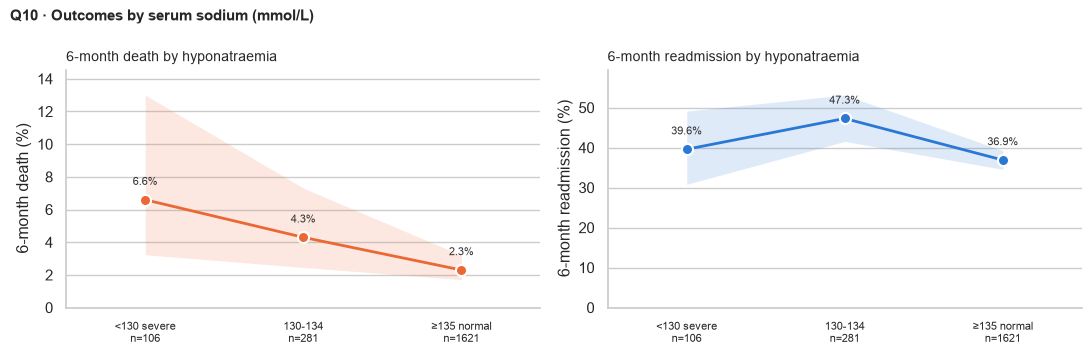

In [23]:
df["hyponatraemia"] = pd.cut(df["sodium"], [0, 130, 135, 1000], right=False, labels=["<130 severe", "130-134", "≥135 normal"])
display(two_outcomes("hyponatraemia", suptitle="Q10 · Outcomes by serum sodium (mmol/L)"))
display(adjusted_or("death_within_6_months ~ I(sodium < 135) + age_mid + killip", show=["sodium"]))

**Chart type — Q10**
* **Trend line with 95% CI band** — *6-month death (left) and readmission (right) by sodium band.* How to read it: each dot is the event rate (%) in one group, joined in the groups' natural order; the shaded band is the 95% Wilson confidence interval and n is printed under each group. A line that climbs or falls step by step means a dose–response; a wide band means few patients or few events in that group.

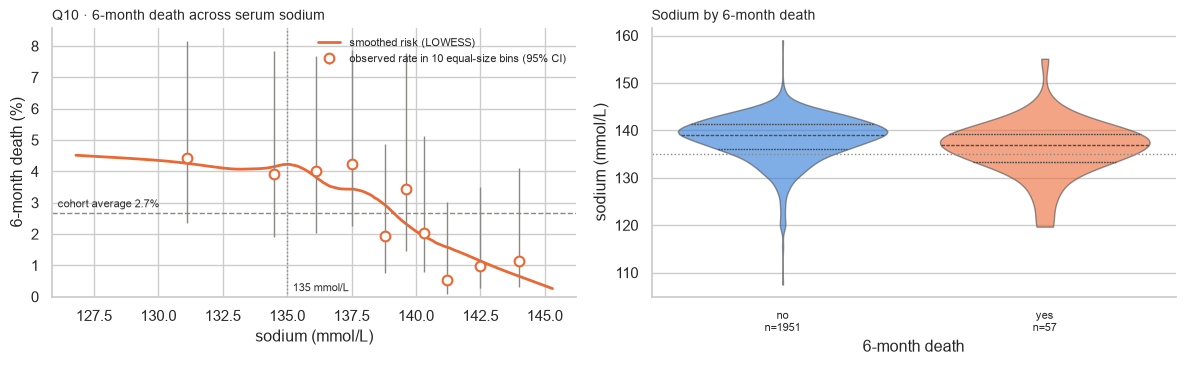

In [24]:
# Q10 · Extra charts: continuous death-risk curve across sodium + violin of sodium by death
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
risk_curve("sodium", DEATH, ax=axes[0], title="Q10 · 6-month death across serum sodium")
axes[0].axvline(135, color=GREY, ls=":", lw=1)
axes[0].annotate("135 mmol/L", (135, 0), xytext=(4, 4), textcoords="offset points", fontsize=8, color=INK)
axes[0].legend(frameon=False, fontsize=8, loc="upper right")
axes[0].set_xlabel("sodium (mmol/L)")
violin("sodium", DEATH, ax=axes[1], title="Sodium by 6-month death")
axes[1].axhline(135, color=GREY, ls=":", lw=1); axes[1].set_ylabel("sodium (mmol/L)")
plt.tight_layout(); plt.show()

**Chart types — Q10 (additional charts)**
* **Risk curve (binned rates + LOWESS smooth)** — *left: 6-month death across serum sodium (dotted line = 135 mmol/L).* How to read it: the marker is kept continuous instead of being cut into groups. Open dots are the observed event rate in equal-size bins of the marker (with 95% CI); the solid line is a LOWESS smooth of the risk; the dashed line is the cohort average. It reveals the shape of the risk — straight, threshold or U-shaped. Only the central 95 % of values is shown, because sparse tails make the smooth unreliable.
* **Violin plot** — *right: sodium by 6-month death.* How to read it: the width of each shape shows how many patients have that value (a smoothed distribution); the dashed line is the median and the dotted lines are the quartiles. It shows the whole spread, e.g. whether one group is shifted or has a long tail, not just the average.

In [ ]:
# Q10 · Correlation: Spearman rank correlation between the markers and outcomes of this question
display(spearman_table(["sodium"], [DEATH, READM]))

marker,correlated with,Spearman ρ,direction,strength,p-value,significant (p < 0.05),n
sodium,6-month death,-0.078,negative (−),negligible,0.00043,yes,2008
sodium,6-month readmission,-0.086,negative (−),negligible,0.00012,yes,2008


**Correlation:** Sodium correlates negatively with **death (ρ = −0.08, p = 0.0004)** and **readmission (ρ = −0.09, p = 0.0001)**: the lower the sodium, the worse the outcome.

**Evidence:** death rises as sodium falls — **2.3 % (≥ 135) → 4.3 % (130–134) → 6.6 % (< 130 mmol/L)** (trend p = 0.003). Hyponatraemia remains a risk factor after adjusting for age and Killip grade (**OR 1.87, 95 % CI 1.04–3.36, p = 0.036**). Readmission is also higher with mild hyponatraemia (47.3 % vs 36.9 %).

**How it influences HF / action:** low sodium reflects neurohormonal activation and water retention — advanced HF. A sodium < 135 on a routine panel should flag a patient for review of fluid intake and diuretic strategy.

---
## Q11. Is spironolactone safe for patients with poor kidneys — how common is high potassium?
**Markers chosen:** `potassium`, `glomerular_filtration_rate`, `rx_spironolactone_tablet`

**Why these markers / how they influence HF:** Spironolactone (an MRA) is a guideline drug in HF, used here by 91 % of patients. It keeps potassium in the body, and the kidneys are the
main route for removing potassium — so the **combination of MRA + low eGFR** risks dangerous hyperkalaemia. This question shows where
potassium monitoring is most needed. (Potassium is the admission value, so this describes risk, not a drug effect.)

hyperkalaemia by ckd_stage: chi-square p = 4.3e-20 | trend p = 8.1e-18
             n  events  rate %     95% CI
ckd_stage                                
<30        192      30    15.6  11.2–21.4
30-44      284      20     7.0   4.6–10.6
45-59      312       8     2.6    1.3–5.0
60-89      579       8     1.4    0.7–2.7
≥90        466       6     1.3    0.6–2.8
Spearman rho(glomerular_filtration_rate, potassium) = -0.339, p = 4.7e-55, n = 2008


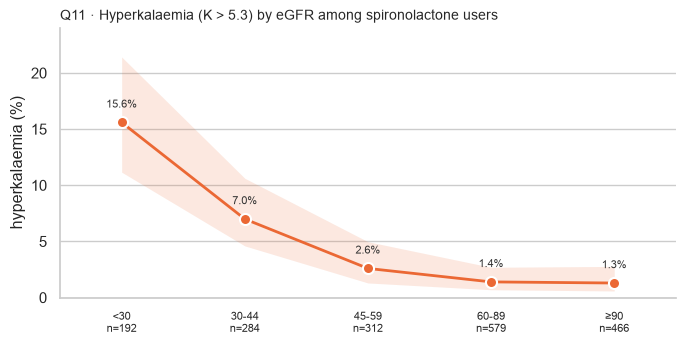

In [25]:
df["hyperkalaemia"] = (df["potassium"] > 5.3).astype(int).where(df["potassium"].notna())   # dictionary upper limit 5.3
d = df[df["rx_spironolactone_tablet"] == 1]
fig, ax = plt.subplots(figsize=(7, 3.6))
tab = rate_by("ckd_stage", "hyperkalaemia", data=d, ax=ax, color=ORANGE,
              title="Q11 · Hyperkalaemia (K > 5.3) by eGFR among spironolactone users")
ax.set_ylabel("hyperkalaemia (%)"); plt.tight_layout(); plt.show()
display(tab)
corr("glomerular_filtration_rate", "potassium")

**Chart type — Q11**
* **Trend line with 95% CI band** — *hyperkalaemia (K > 5.3) by eGFR stage among spironolactone users.* How to read it: each dot is the event rate (%) in one group, joined in the groups' natural order; the shaded band is the 95% Wilson confidence interval and n is printed under each group. A line that climbs or falls step by step means a dose–response; a wide band means few patients or few events in that group.

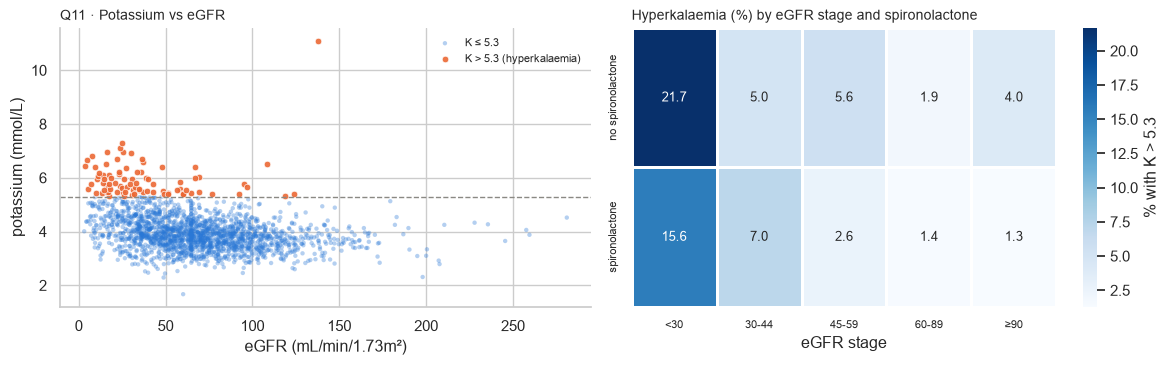

In [26]:
# Q11 · Extra charts: potassium vs eGFR scatter with the 5.3 threshold + heatmap by drug and eGFR stage
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
d = df.dropna(subset=["potassium", "glomerular_filtration_rate"])
hi = d["potassium"] > 5.3
axes[0].scatter(d.loc[~hi, "glomerular_filtration_rate"], d.loc[~hi, "potassium"], s=10, alpha=0.35, color=BLUE, edgecolors="none", label="K ≤ 5.3")
axes[0].scatter(d.loc[hi, "glomerular_filtration_rate"], d.loc[hi, "potassium"], s=22, alpha=0.9, color=ORANGE, edgecolors="white", lw=0.5, label="K > 5.3 (hyperkalaemia)")
axes[0].axhline(5.3, color=GREY, ls="--", lw=1)
axes[0].set_xlabel("eGFR (mL/min/1.73m²)"); axes[0].set_ylabel("potassium (mmol/L)")
axes[0].set_title("Q11 · Potassium vs eGFR", loc="left", fontsize=10); axes[0].legend(frameon=False, fontsize=8)
hk = (df.dropna(subset=["hyperkalaemia", "ckd_stage"])
        .assign(spiro=lambda x: x["rx_spironolactone_tablet"].map({1: "spironolactone", 0: "no spironolactone"}))
        .pivot_table(index="spiro", columns="ckd_stage", values="hyperkalaemia", aggfunc="mean", observed=True) * 100)
heat(hk, ax=axes[1], title="Hyperkalaemia (%) by eGFR stage and spironolactone", cbar_label="% with K > 5.3")
axes[1].set_xlabel("eGFR stage"); axes[1].set_ylabel("")
plt.tight_layout(); plt.show()

**Chart types — Q11 (additional charts)**
* **Scatter plot with threshold highlighting** — *left: potassium against eGFR, K > 5.3 in orange.* How to read it: each point is one patient; orange points are above the clinical threshold (dashed line), blue points below. It shows where along the x-axis the abnormal values pile up.
* **Heatmap** — *right: hyperkalaemia (%) by eGFR stage, with vs without spironolactone.* How to read it: each cell is shaded by its value on a single-colour scale (darker = higher) and the number is written inside the cell, so you can scan for the darkest corner and still read exact values.

In [ ]:
# Q11 · Correlation: Spearman rank correlation between the markers and outcomes of this question
display(spearman_table(["glomerular_filtration_rate"], ["potassium", "hyperkalaemia"], data=df[df["rx_spironolactone_tablet"] == 1]))

marker,correlated with,Spearman ρ,direction,strength,p-value,significant (p < 0.05),n
glomerular_filtration_rate,potassium,-0.325,negative (−),moderate,3.2e-46,yes,1833
glomerular_filtration_rate,hyperkalaemia,-0.189,negative (−),weak,2.9e-16,yes,1833


**Correlation:** Among spironolactone users, eGFR is **moderately negatively correlated with potassium (ρ = −0.33, p = 3 × 10⁻⁴⁶)** and with hyperkalaemia (ρ = −0.19, p = 3 × 10⁻¹⁶): the poorer the kidneys, the higher the potassium.

**Evidence:** among spironolactone users, **hyperkalaemia (K > 5.3) rises from 1.3–1.4 % (eGFR ≥ 60) to 7.0 % (30–44) and 15.6 % (< 30)** — a 12-fold increase (trend p = 8 × 10⁻¹⁸). Across the cohort, potassium is moderately negatively correlated with eGFR (ρ = −0.34, p = 5 × 10⁻⁵⁵).

**How it influences HF / action:** the kidneys are the only route for potassium removal, and MRAs block it further. The data supports the guideline rule: in patients with eGFR < 30 on spironolactone, check potassium within 3 days and at 1 week, and reduce or stop the dose if K > 5.5.

---
## Q12. Does poor nutrition (low albumin, low BMI) predict worse outcomes and longer stays?
**Markers chosen:** `albumin` (< 35 g/L) and `bmi` (Asian categories) → 6-month death, readmission, `dischargeday`

**Why these markers / how they influence HF:** Albumin falls with **malnutrition, inflammation and liver congestion**, and low albumin lets fluid leak into tissues (oedema). Category 2
showed 25 % of patients are underweight, so nutrition may be a hidden driver of outcomes. We also test the **obesity paradox** — in HF a
*higher* BMI is often linked to better survival, while very low BMI reflects cardiac cachexia.

6-month death by low_albumin: chi-square p = 0.15 | trend p = 0.12
6-month readmission by low_albumin: chi-square p = 0.087 | trend p = 0.036
            6-month death                        6-month readmission                         
                        n events rate %   95% CI                   n events rate %     95% CI
low_albumin                                                                                  
<30                   177      6    3.4  1.6–7.2                 177     61   34.5  27.9–41.7
30-34.9               471     19    4.0  2.6–6.2                 471    166   35.2  31.1–39.7
≥35                  1360     32    2.4  1.7–3.3                1360    546   40.1  37.6–42.8
             count  median  mean
low_albumin                     
<30            177     8.0   9.9
30-34.9        471     8.0   9.9
≥35           1360     7.0   9.2
Kruskal-Wallis p (length of stay) = 0.002
6-month death by bmi_cat: chi-square p = 0.84 | trend p = 0.56
6-month readmission by b

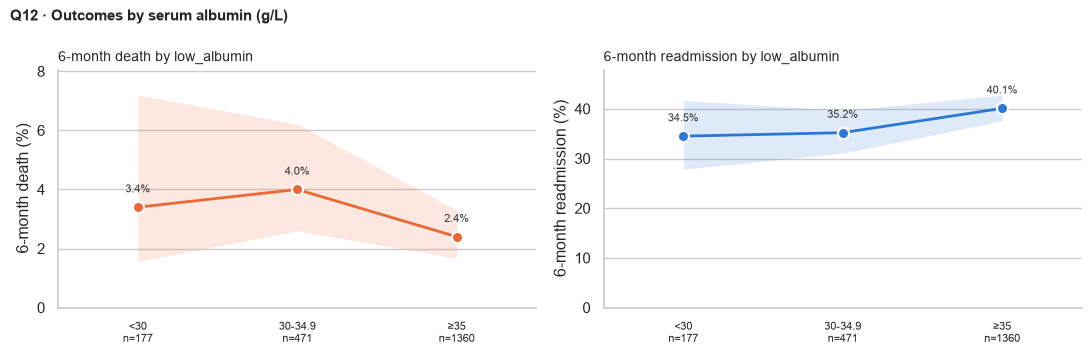

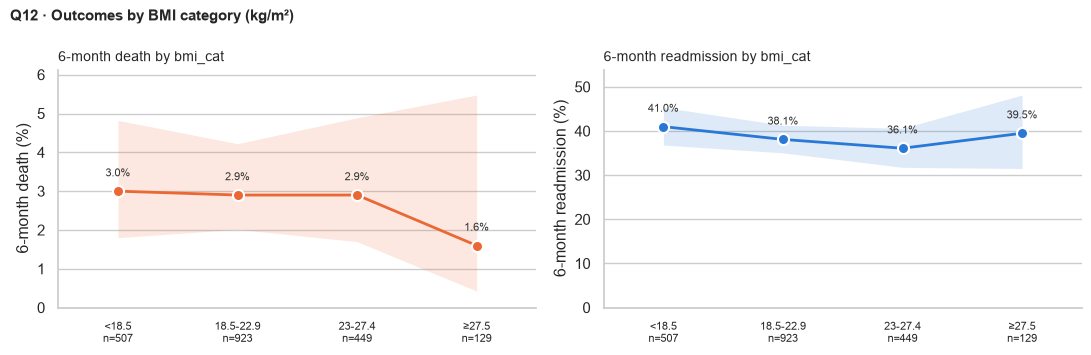

In [27]:
df["low_albumin"] = pd.cut(df["albumin"], [0, 30, 35, 100], right=False, labels=["<30", "30-34.9", "≥35"])
display(two_outcomes("low_albumin", suptitle="Q12 · Outcomes by serum albumin (g/L)"))
display(df.groupby("low_albumin", observed=True)["dischargeday"].agg(["count", "median", "mean"]).round(1))
print("Kruskal-Wallis p (length of stay) =",
      f"{kruskal(*[g['dischargeday'] for _, g in df.dropna(subset=['low_albumin']).groupby('low_albumin', observed=True)]).pvalue:.2g}")
df["bmi_cat"] = pd.cut(df["bmi"], [0, 18.5, 23, 27.5, 100], right=False, labels=["<18.5", "18.5-22.9", "23-27.4", "≥27.5"])
display(two_outcomes("bmi_cat", suptitle="Q12 · Outcomes by BMI category (kg/m²)"))

**Chart types — Q12**
* **Trend line with 95% CI band** — *first figure: 6-month death and readmission by albumin band.* How to read it: each dot is the event rate (%) in one group, joined in the groups' natural order; the shaded band is the 95% Wilson confidence interval and n is printed under each group. A line that climbs or falls step by step means a dose–response; a wide band means few patients or few events in that group.
* **Trend line with 95% CI band** — *second figure: 6-month death and readmission by BMI category.* How to read it: each dot is the event rate (%) in one group, joined in the groups' natural order; the shaded band is the 95% Wilson confidence interval and n is printed under each group. A line that climbs or falls step by step means a dose–response; a wide band means few patients or few events in that group.

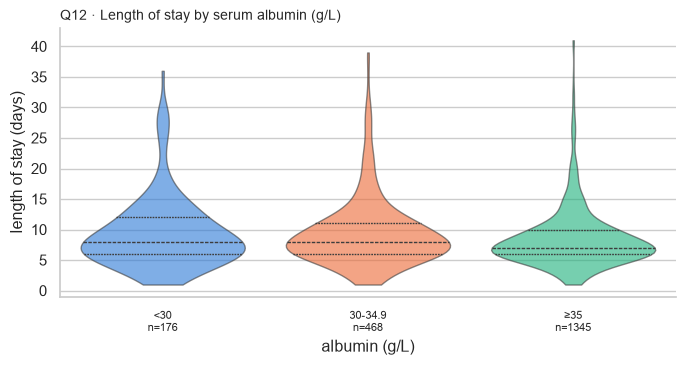

In [28]:
# Q12 · Extra chart: length-of-stay distribution by albumin (violin)
fig, ax = plt.subplots(figsize=(7, 3.8))
violin("dischargeday", "low_albumin", ax=ax, clip_q=0.99, title="Q12 · Length of stay by serum albumin (g/L)")
ax.set_ylabel("length of stay (days)"); ax.set_xlabel("albumin (g/L)")
plt.tight_layout(); plt.show()

**Chart type — Q12 (additional charts)**
* **Violin plot** — *length of stay by albumin band (top 1 % of stays trimmed).* How to read it: the width of each shape shows how many patients have that value (a smoothed distribution); the dashed line is the median and the dotted lines are the quartiles. It shows the whole spread, e.g. whether one group is shifted or has a long tail, not just the average.

In [ ]:
# Q12 · Correlation: Spearman rank correlation between the markers and outcomes of this question
display(spearman_table(["albumin", "bmi"], [DEATH, READM, "dischargeday"]))

marker,correlated with,Spearman ρ,direction,strength,p-value,significant (p < 0.05),n
albumin,6-month death,-0.053,negative (−),negligible,0.018,yes,2008
albumin,6-month readmission,0.037,positive (+),negligible,0.093,no,2008
albumin,length of stay (days),-0.094,negative (−),negligible,2.3e-05,yes,2008
bmi,6-month death,-0.002,negative (−),negligible,0.92,no,2008
bmi,6-month readmission,-0.038,negative (−),negligible,0.09,no,2008
bmi,length of stay (days),-0.019,negative (−),negligible,0.4,no,2008


**Correlation:** Albumin is weakly negatively correlated with **length of stay (ρ = −0.09, p = 2 × 10⁻⁵)** and death (ρ = −0.05, p = 0.02 — just significant as a continuous value, although the grouped trend, p = 0.12, is not), and not with readmission (p = 0.09). **BMI shows no correlation with any outcome** (all |ρ| ≤ 0.04, p ≥ 0.09) — no obesity paradox.

**Evidence:** low albumin is linked to **longer stays** (median 8 vs 7 days, Kruskal–Wallis p = 0.002). Death is somewhat higher below 35 g/L (**4.0 % at 30–34.9 and 3.4 % below 30 vs 2.4 % at ≥ 35**), but the difference is **not statistically significant** (trend p = 0.12). Readmission is actually slightly *lower* with low albumin (34.5–35.2 % vs 40.1 %; trend p = 0.04), likely because sicker, malnourished patients die or are discharged to care facilities rather than readmitted. BMI shows **no** association with death (1.6–3.0 %, p = 0.84) or readmission (p = 0.46) — no obesity paradox is visible in this lean cohort.

**How it influences HF / action:** in this data nutrition markers mainly affect **length of stay**, not 6-month death or readmission. Albumin < 35 g/L should still prompt a nutrition assessment, which may shorten recovery, but it is not a strong risk marker on its own. (Note: 102 missing albumin values were median-filled in cleaning, which moves them into the ≥ 35 group and may dilute differences.)

---
## Q13. Does high uric acid predict readmission and death?
**Markers chosen:** `uric_acid` (µmol/L; reference 150–440) → 6-month readmission and death

**Why these markers / how they influence HF:** Uric acid is the end product of purine breakdown by **xanthine oxidase**, an enzyme that is up-regulated in HF and produces oxygen free radicals.
High uric acid also reflects **diuretic use and reduced kidney excretion**, and tissue hypoxia. It is therefore a cheap marker combining
oxidative stress, congestion treatment and kidney function — and we adjust for eGFR to see if it adds information beyond the kidneys.

6-month death by uric_band: chi-square p = 0.0015 | trend p = 0.0019
6-month readmission by uric_band: chi-square p = 0.00036 | trend p = 7.2e-05
          6-month death                        6-month readmission                         
                      n events rate %   95% CI                   n events rate %     95% CI
uric_band                                                                                  
<360                496      9    1.8  1.0–3.4                 496    162   32.7  28.7–36.9
360-440             421      9    2.1  1.1–4.0                 421    160   38.0  33.5–42.7
441-600             664     15    2.3  1.4–3.7                 664    253   38.1  34.5–41.9
>600                427     24    5.6  3.8–8.2                 427    198   46.4  41.7–51.1
uric_acid: Mann-Whitney p = 8.1e-06 | AUC for 6-month readmission = 0.559
                              n  median     Q1     Q3
6-month readmission = yes   773   475.0  378.0  604.0
no                         1

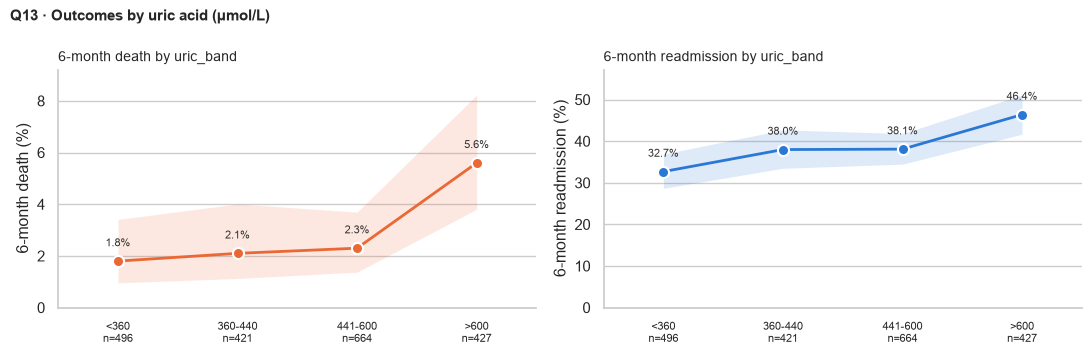

In [29]:
df["uric_band"] = pd.cut(df["uric_acid"], [0, 360, 440, 600, 5000], labels=["<360", "360-440", "441-600", ">600"])
display(two_outcomes("uric_band", suptitle="Q13 · Outcomes by uric acid (µmol/L)"))
display(compare("uric_acid", READM))
display(adjusted_or("re_admission_within_6_months ~ I(uric_acid/100) + glomerular_filtration_rate + age_mid + male", show=["uric"]))
print("OR per 100 µmol/L higher uric acid, adjusted for eGFR, age and sex")

**Chart type — Q13**
* **Trend line with 95% CI band** — *6-month death (left) and readmission (right) by uric-acid band.* How to read it: each dot is the event rate (%) in one group, joined in the groups' natural order; the shaded band is the 95% Wilson confidence interval and n is printed under each group. A line that climbs or falls step by step means a dose–response; a wide band means few patients or few events in that group.

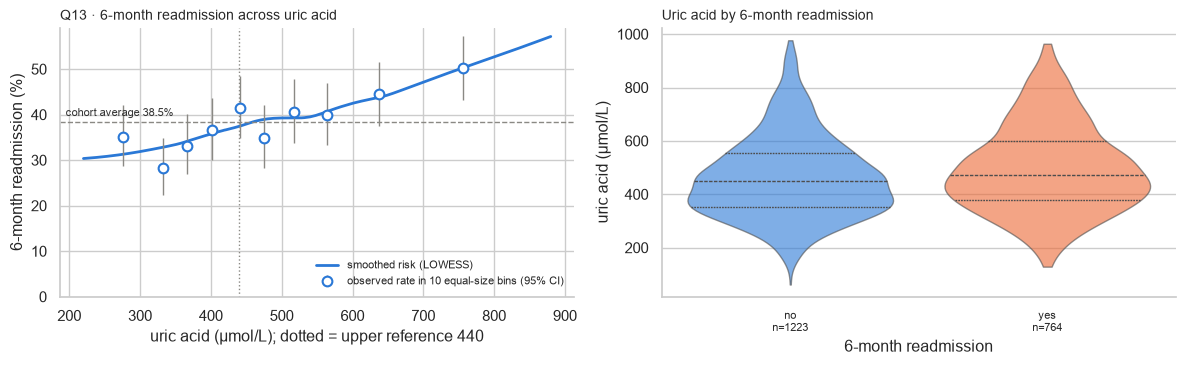

In [30]:
# Q13 · Extra charts: continuous readmission risk curve across uric acid + violin by readmission
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
risk_curve("uric_acid", READM, ax=axes[0], title="Q13 · 6-month readmission across uric acid")
axes[0].axvline(440, color=GREY, ls=":", lw=1); axes[0].set_xlabel("uric acid (µmol/L); dotted = upper reference 440")
violin("uric_acid", READM, ax=axes[1], clip_q=0.99, title="Uric acid by 6-month readmission")
axes[1].set_ylabel("uric acid (µmol/L)")
plt.tight_layout(); plt.show()

**Chart types — Q13 (additional charts)**
* **Risk curve (binned rates + LOWESS smooth)** — *left: 6-month readmission across uric acid (dotted line = 440 µmol/L).* How to read it: the marker is kept continuous instead of being cut into groups. Open dots are the observed event rate in equal-size bins of the marker (with 95% CI); the solid line is a LOWESS smooth of the risk; the dashed line is the cohort average. It reveals the shape of the risk — straight, threshold or U-shaped. Only the central 95 % of values is shown, because sparse tails make the smooth unreliable.
* **Violin plot** — *right: uric acid by readmission.* How to read it: the width of each shape shows how many patients have that value (a smoothed distribution); the dashed line is the median and the dotted lines are the quartiles. It shows the whole spread, e.g. whether one group is shifted or has a long tail, not just the average.

In [ ]:
# Q13 · Correlation: Spearman rank correlation between the markers and outcomes of this question
display(spearman_table(["uric_acid"], [READM, DEATH, "glomerular_filtration_rate"]))

marker,correlated with,Spearman ρ,direction,strength,p-value,significant (p < 0.05),n
uric_acid,6-month readmission,0.100,positive (+),negligible,7.7e-06,yes,2008
uric_acid,6-month death,0.070,positive (+),negligible,0.0016,yes,2008
uric_acid,glomerular_filtration_rate,-0.513,negative (−),strong,3.5e-135,yes,2008


**Correlation:** Uric acid correlates positively with **readmission (ρ = +0.10, p = 8 × 10⁻⁶)** and **death (ρ = +0.07, p = 0.002)**, and **strongly negatively with eGFR (ρ = −0.51)** — which is why the regression adjusts for eGFR; the readmission link survives that adjustment.

**Evidence:** patients with uric acid > 600 µmol/L have the highest **readmission (46.4 % vs 32.7 % below 360; trend p = 7 × 10⁻⁵)** and **death (5.6 % vs 1.8–2.2 %; trend p = 0.002)**. The readmission link survives adjustment for eGFR, age and sex (**OR 1.09 per 100 µmol/L, 95 % CI 1.02–1.16, p = 0.01**).

**How it influences HF / action:** uric acid adds information beyond kidney function, consistent with the oxidative-stress (xanthine oxidase) pathway and diuretic effect. Very high uric acid (> 600) is a cheap flag for closer follow-up; whether lowering it improves HF outcomes is unproven, so it is a risk marker, not a treatment target.

---
## Q14. Does anaemia add risk, and is it tied to kidney disease?
**Markers chosen:** `hemoglobin` (WHO anaemia: < 120 g/L women, < 130 g/L men), `glomerular_filtration_rate` → outcomes

**Why these markers / how they influence HF:** Anaemia reduces oxygen delivery, so the heart must pump harder; in HF it is often caused by **CKD (less erythropoietin)**, iron deficiency
and inflammation. We test both the outcome link and the kidney link, because if anaemia simply mirrors CKD, treating the kidneys is the lever.

Anaemia prevalence: 61.4%
6-month death by anaemia_label: chi-square p = 0.49
6-month readmission by anaemia_label: chi-square p = 0.025
              6-month death                        6-month readmission                         
                          n events rate %   95% CI                   n events rate %     95% CI
anaemia_label                                                                                  
anaemic                1233     38    3.1  2.3–4.2                1233    499   40.5  37.8–43.2
not anaemic             775     19    2.5  1.6–3.8                 775    274   35.4  32.1–38.8
Spearman rho(glomerular_filtration_rate, hemoglobin) = 0.318, p = 1.7e-48, n = 2008
Logistic regression (n = 2008): re_admission_within_6_months ~ anaemia + glomerular_filtration_rate + age_mid + male
                               OR  CI low  CI high      p
anaemia                     1.156   0.952    1.403  0.143
glomerular_filtration_rate  0.995   0.992    0.998  0.000


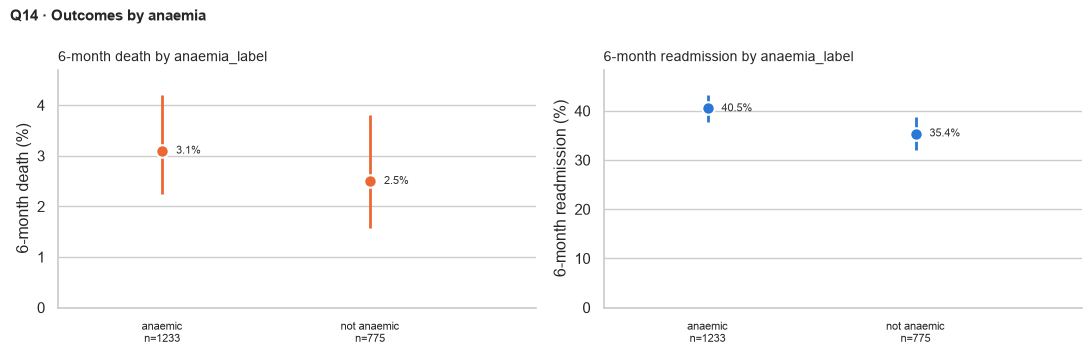

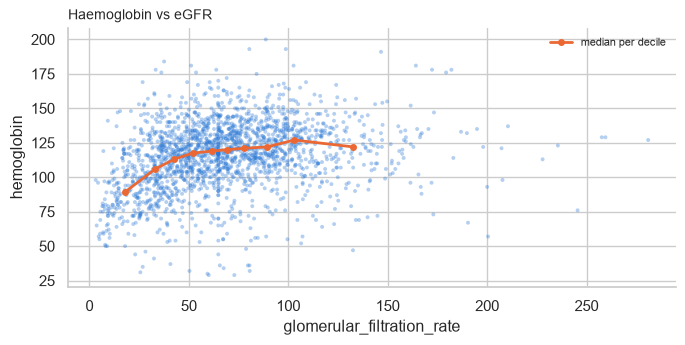

In [31]:
thr = np.where(df["gender"] == "Male", 130, 120)
df["anaemia"] = np.where(df["hemoglobin"].isna(), np.nan, (df["hemoglobin"] < thr).astype(float))
df["anaemia_label"] = df["anaemia"].map({1.0: "anaemic", 0.0: "not anaemic"})
print(f"Anaemia prevalence: {df['anaemia'].mean()*100:.1f}%")
display(two_outcomes("anaemia_label", ordered=False, suptitle="Q14 · Outcomes by anaemia"))
fig, ax = plt.subplots(figsize=(7, 3.6))
corr("glomerular_filtration_rate", "hemoglobin", ax=ax)
ax.set_title("Haemoglobin vs eGFR", loc="left", fontsize=10); plt.tight_layout(); plt.show()
display(adjusted_or("re_admission_within_6_months ~ anaemia + glomerular_filtration_rate + age_mid + male", show=["anaemia", "glomerular"]))

**Chart types — Q14**
* **Dot plot with 95% CI whiskers** — *first figure: 6-month death and readmission, anaemic vs not anaemic.* How to read it: each dot is the event rate (%) in one group; the groups have no natural order, so they are not joined. The vertical whisker is the 95% Wilson confidence interval — when two groups' whiskers do not overlap, the difference is unlikely to be chance.
* **Scatter plot with binned-median trend line** — *second figure: haemoglobin against eGFR.* How to read it: each blue dot is one patient; the orange line joins the median y-value within each tenth (decile) of x, so it shows the trend without being pulled by outliers. The Spearman ρ printed above the chart gives its strength.

anaemia prevalence by ckd_stage: chi-square p = 3.9e-28 | trend p = 4.3e-29
Logistic regression (n = 2008): re_admission_within_6_months ~ anaemia + I(glomerular_filtration_rate/10) + age_mid + male


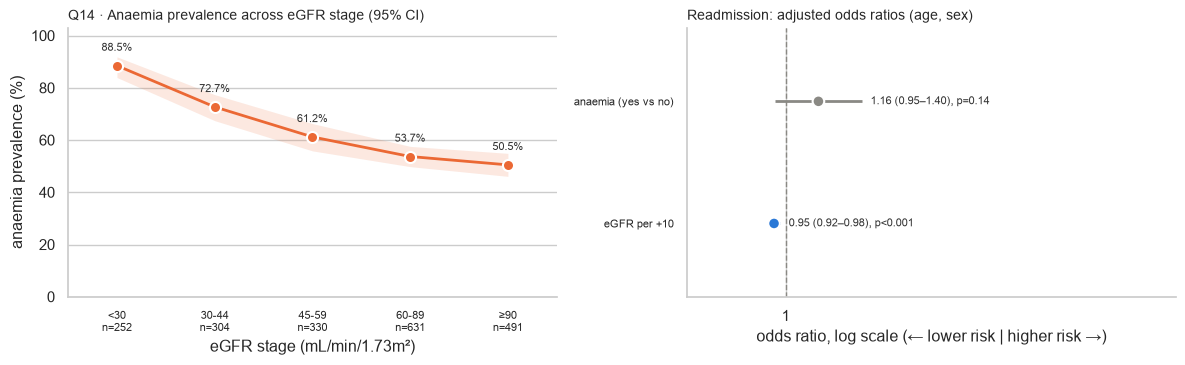

In [32]:
# Q14 · Extra charts: anaemia prevalence rising as eGFR falls + forest plot (anaemia vs eGFR)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
LABEL["anaemia"] = "anaemia prevalence"
rate_by("ckd_stage", "anaemia", ax=axes[0], color=ORANGE, title="Q14 · Anaemia prevalence across eGFR stage (95% CI)")
axes[0].set_xlabel("eGFR stage (mL/min/1.73m²)")
ors = adjusted_or("re_admission_within_6_months ~ anaemia + I(glomerular_filtration_rate/10) + age_mid + male",
                  show=["anaemia", "glomerular"]).rename(index={"anaemia": "anaemia (yes vs no)",
                                                                  "I(glomerular_filtration_rate / 10)": "eGFR per +10"})
forest(ors, ax=axes[1], title="Readmission: adjusted odds ratios (age, sex)")
plt.tight_layout(); plt.show()

**Chart types — Q14 (additional charts)**
* **Trend line with 95% CI band** — *left: anaemia prevalence by eGFR stage.* How to read it: each dot is the event rate (%) in one group, joined in the groups' natural order; the shaded band is the 95% Wilson confidence interval and n is printed under each group. A line that climbs or falls step by step means a dose–response; a wide band means few patients or few events in that group.
* **Forest plot** — *right: adjusted OR of readmission for anaemia and per 10 units higher eGFR.* How to read it: each dot is an odds ratio (OR) from a logistic regression, with its 95% CI as a horizontal line, on a log scale. The dashed line at OR = 1 means no association; to the right = higher odds of the outcome, to the left = lower. Blue = the CI excludes 1 (statistically significant), grey = not significant. The value, CI and p-value are written beside each line.

In [ ]:
# Q14 · Correlation: Spearman rank correlation between the markers and outcomes of this question
display(spearman_table(["hemoglobin"], [READM, DEATH, "glomerular_filtration_rate"]))

marker,correlated with,Spearman ρ,direction,strength,p-value,significant (p < 0.05),n
hemoglobin,6-month readmission,-0.050,negative (−),negligible,0.025,yes,2008
hemoglobin,6-month death,-0.037,negative (−),negligible,0.094,no,2008
hemoglobin,glomerular_filtration_rate,0.318,positive (+),moderate,1.7e-48,yes,2008


**Correlation:** Haemoglobin correlates **moderately with eGFR (ρ = +0.32, p = 2 × 10⁻⁴⁸)** but only negligibly with readmission (ρ = −0.05, p = 0.03) and not with death (p = 0.09) — supporting the view that anaemia's risk runs through the kidneys.

**Evidence:** **61.4 %** of patients are anaemic. Anaemic patients are readmitted more often (**40.5 % vs 35.4 %, p = 0.025**) but death does not differ (3.1 % vs 2.5 %, p = 0.5). Haemoglobin correlates with eGFR (ρ = 0.32, p = 10⁻⁴⁸), and once eGFR is added to the model, anaemia is no longer significant (OR 1.16, p = 0.14) while eGFR remains (p < 0.001).

**How it influences HF / action:** anaemia's link with readmission runs largely **through kidney disease** (renal anaemia). The lever is the cardiorenal pathway (Q8), plus iron studies — guidelines recommend IV iron for iron-deficient HF patients.

---
# C. Heart injury, perfusion, inflammation and congestion (Q15–Q22)

---
## Q15. Does heart-muscle injury (troponin) predict death?
**Markers chosen:** `high_sensitivity_troponin` (quartiles) → 6-month death

**Why these markers / how they influence HF:** Troponin is released when **heart muscle cells are damaged** — by ischaemia, high wall stress or inflammation. In HF, even small rises
indicate ongoing myocyte loss. (The unit of this column is uncertain — its values do not match the dictionary's pg/mL range — so we use quartiles, which do not depend on the unit.)

6-month death by trop_quartile: chi-square p = 4.3e-06 | trend p = 6.1e-07
                 n  events  rate %   95% CI
trop_quartile                              
Q1 low         502       5     1.0  0.4–2.3
Q2             502       5     1.0  0.4–2.3
Q3             502      19     3.8  2.4–5.8
Q4 high        502      28     5.6  3.9–7.9
6-month death by trop_quartile: chi-square p = 4.3e-06 | trend p = 6.1e-07
high_sensitivity_troponin: Mann-Whitney p = 3.7e-07 | AUC for 6-month death = 0.697
                        n  median    Q1    Q3
6-month death = yes    57    0.11  0.07  0.20
no                   1951    0.06  0.02  0.11


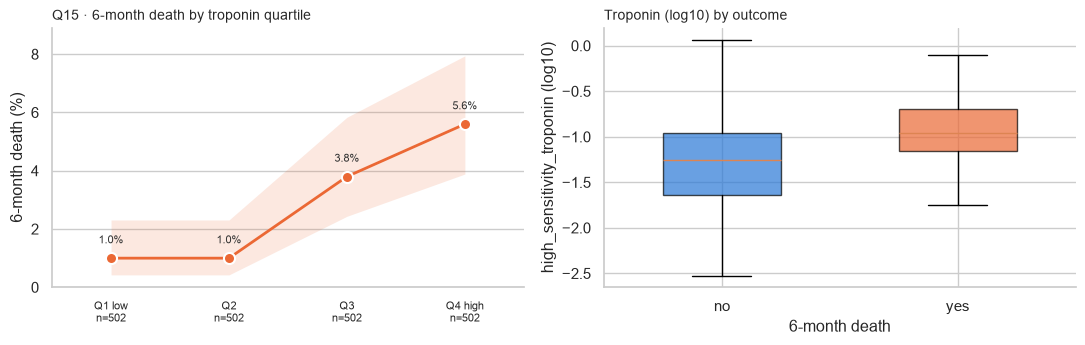

In [33]:
df["trop_quartile"] = pd.qcut(df["high_sensitivity_troponin"].rank(method="first"), 4, labels=["Q1 low", "Q2", "Q3", "Q4 high"])
tab = rate_by("trop_quartile", DEATH); display(tab)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
rate_by("trop_quartile", DEATH, ax=axes[0], color=ORANGE, title="Q15 · 6-month death by troponin quartile")
display(compare("high_sensitivity_troponin", DEATH, log=True, ax=axes[1]))
axes[1].set_title("Troponin (log10) by outcome", loc="left", fontsize=10); plt.tight_layout(); plt.show()

**Chart types — Q15**
* **Trend line with 95% CI band** — *left: 6-month death by troponin quartile.* How to read it: each dot is the event rate (%) in one group, joined in the groups' natural order; the shaded band is the 95% Wilson confidence interval and n is printed under each group. A line that climbs or falls step by step means a dose–response; a wide band means few patients or few events in that group.
* **Box plot** — *right: troponin (log10) in patients who died vs survived.* How to read it: the box covers the middle 50 % of patients (Q1 to Q3) and the line inside it is the median; whiskers reach the furthest values within 1.5 × IQR (outliers hidden). Compare the medians and how far the boxes overlap.

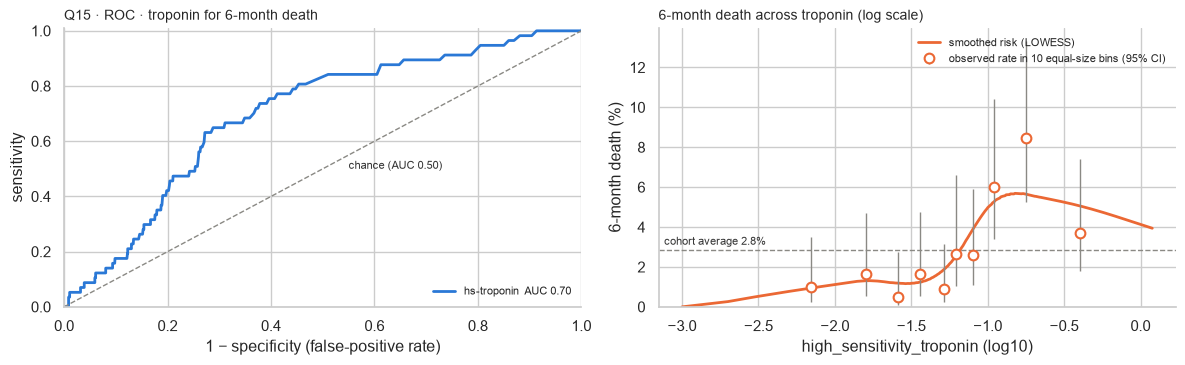

In [34]:
# Q15 · Extra charts: ROC curve for troponin + continuous death-risk curve (log troponin)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
roc_plot({"hs-troponin": "high_sensitivity_troponin"}, DEATH, ax=axes[0], title="Q15 · ROC · troponin for 6-month death")
risk_curve("high_sensitivity_troponin", DEATH, logx=True, ax=axes[1], title="6-month death across troponin (log scale)")
plt.tight_layout(); plt.show()

**Chart types — Q15 (additional charts)**
* **ROC curve** — *left: troponin for 6-month death.* How to read it: plots sensitivity (deaths correctly flagged) against the false-positive rate for every possible cut-off of the marker. The more the curve bows towards the top-left corner the better; the dashed diagonal is chance. The AUC in the legend summarises it (0.5 = chance, 0.7 = acceptable, 0.8 = good, 1 = perfect).
* **Risk curve (binned rates + LOWESS smooth)** — *right: 6-month death across troponin (log10).* How to read it: the marker is kept continuous instead of being cut into groups. Open dots are the observed event rate in equal-size bins of the marker (with 95% CI); the solid line is a LOWESS smooth of the risk; the dashed line is the cohort average. It reveals the shape of the risk — straight, threshold or U-shaped. Only the central 95 % of values is shown, because sparse tails make the smooth unreliable.

In [ ]:
# Q15 · Correlation: Spearman rank correlation between the markers and outcomes of this question
display(spearman_table(["high_sensitivity_troponin"], [DEATH, READM]))

marker,correlated with,Spearman ρ,direction,strength,p-value,significant (p < 0.05),n
high_sensitivity_troponin,6-month death,0.113,positive (+),weak,3.4e-07,yes,2008
high_sensitivity_troponin,6-month readmission,0.071,positive (+),negligible,0.0014,yes,2008


**Correlation:** Troponin correlates positively with **6-month death (ρ = +0.11, p = 3 × 10⁻⁷)** and slightly with readmission (ρ = +0.07, p = 0.001).

**Evidence:** death is low in the two lowest troponin quartiles (1.0 %, 1.0 %) and jumps to **3.8 % (Q3) and 5.6 % (Q4)** (trend p = 6 × 10⁻⁷). Median troponin is almost 2 × higher in patients who died (0.11 vs 0.06; AUC 0.70).

**How it influences HF / action:** ongoing heart-muscle injury marks progressive disease. Troponin in the top half should prompt a search for ischaemia and is one of the best single mortality markers for the Category 4 model.

---
## Q16. Does reduced consciousness (GCS) signal imminent death?
**Markers chosen:** `gcs` (Glasgow Coma Scale) and `consciousness` → 28-day and 6-month death

**Why these markers / how they influence HF:** A low GCS in HF means the **brain is under-perfused** (low output, shock) or poisoned by CO₂ (respiratory failure). It is a sign of
multi-organ failure. Because such deaths happen fast, we look at 28-day as well as 6-month death.

28-day death by gcs_group: chi-square p = 1.3e-66 | trend p = 3.2e-62
6-month death by gcs_group: chi-square p = 4.8e-52 | trend p = 2.6e-49
             28-day death                          6-month death                         
                        n events rate %     95% CI             n events rate %     95% CI
gcs_group                                                                                
3-8 severe             19     10   52.6  31.7–72.7            19     11   57.9  36.3–76.9
9-14 reduced           38      5   13.2   5.8–27.3            38      6   15.8   7.4–30.4
15 normal            1951     22    1.1    0.7–1.7          1951     40    2.1    1.5–2.8


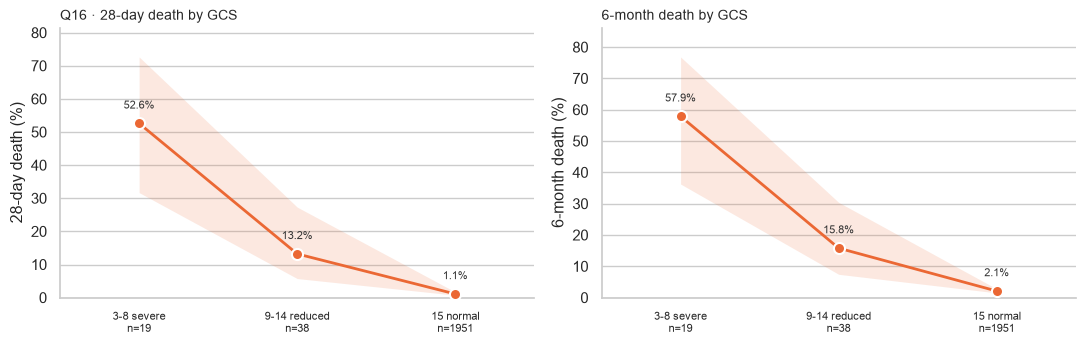

In [35]:
df["gcs_group"] = pd.cut(df["gcs"], [0, 8, 14, 15], labels=["3-8 severe", "9-14 reduced", "15 normal"])
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
t28 = rate_by("gcs_group", "death_within_28_days", ax=axes[0], color=ORANGE, title="Q16 · 28-day death by GCS")
t6 = rate_by("gcs_group", DEATH, ax=axes[1], color=ORANGE, title="6-month death by GCS")
plt.tight_layout(); plt.show()
display(pd.concat({"28-day death": t28, "6-month death": t6}, axis=1))

**Chart type — Q16**
* **Trend line with 95% CI band** — *28-day death (left) and 6-month death (right) by GCS group.* How to read it: each dot is the event rate (%) in one group, joined in the groups' natural order; the shaded band is the 95% Wilson confidence interval and n is printed under each group. A line that climbs or falls step by step means a dose–response; a wide band means few patients or few events in that group.

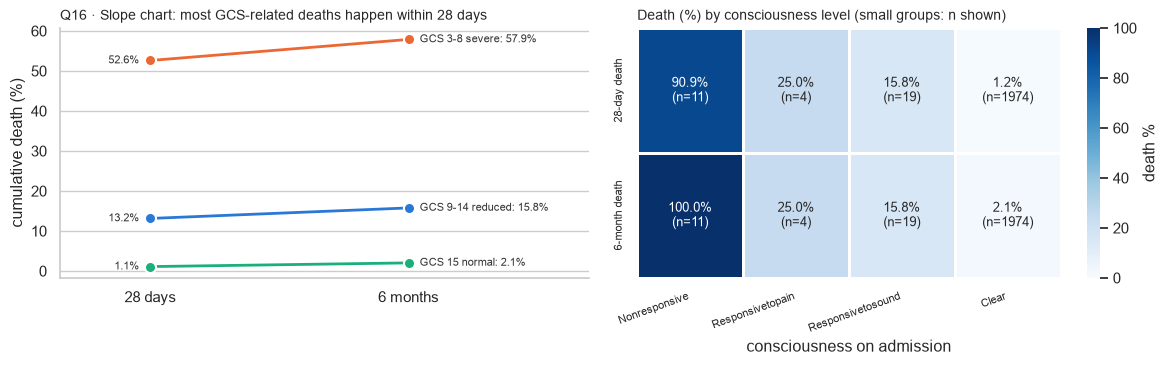

In [36]:
# Q16 · Extra charts: slope chart 28-day → 6-month death per GCS group + trend across consciousness level
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
sl = df.dropna(subset=["gcs_group"]).groupby("gcs_group", observed=True)[["death_within_28_days", DEATH]].mean().mul(100)
for (grp, r), c in zip(sl.iterrows(), [ORANGE, BLUE, AQUA]):
    axes[0].plot([0, 1], r.values, color=c, lw=2, marker="o", ms=8, mec="white", mew=1.5)
    axes[0].annotate(f"GCS {grp}: {r.iloc[1]:.1f}%", (1, r.iloc[1]), xytext=(8, 0), textcoords="offset points", va="center", fontsize=8, color=INK)
    axes[0].annotate(f"{r.iloc[0]:.1f}%", (0, r.iloc[0]), xytext=(-8, 0), textcoords="offset points", va="center", ha="right", fontsize=8, color=INK)
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(["28 days", "6 months"]); axes[0].set_xlim(-0.35, 1.7)
axes[0].set_ylabel("cumulative death (%)"); axes[0].grid(axis="x", visible=False)
axes[0].set_title("Q16 · Slope chart: most GCS-related deaths happen within 28 days", loc="left", fontsize=10)
cs = df.groupby("consciousness", observed=True)[["death_within_28_days", DEATH]]
rates = cs.mean().mul(100).T.rename(index={"death_within_28_days": "28-day death", DEATH: "6-month death"})
labels = rates.round(1).astype(str) + "%\n(n=" + cs.size().astype(str).reindex(rates.columns).values + ")"
heat(rates, ax=axes[1], annot=labels, fmt="", vmin=0, vmax=100, cbar_label="death %",
     title="Death (%) by consciousness level (small groups: n shown)")
axes[1].set_xlabel("consciousness on admission"); axes[1].set_ylabel("")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=20, ha="right")
plt.tight_layout(); plt.show()

**Chart types — Q16 (additional charts)**
* **Slope chart** — *left: 28-day → 6-month death for each GCS group.* How to read it: each line joins one group's cumulative death rate at 28 days (left) to 6 months (right). A nearly flat line means most of that group's deaths had already happened by day 28.
* **Heatmap** — *right: 28-day and 6-month death (%) by consciousness level, with n per group (small groups).* How to read it: each cell is shaded by its value on a single-colour scale (darker = higher) and the number is written inside the cell, so you can scan for the darkest corner and still read exact values.

In [ ]:
# Q16 · Correlation: Spearman rank correlation between the markers and outcomes of this question
display(spearman_table(["gcs"], ["death_within_28_days", DEATH]))

marker,correlated with,Spearman ρ,direction,strength,p-value,significant (p < 0.05),n
gcs,28-day death,-0.314,negative (−),moderate,3.1e-47,yes,2008
gcs,6-month death,-0.281,negative (−),weak,1.1e-37,yes,2008


**Correlation:** GCS is **negatively correlated with 28-day death (ρ = −0.31, p = 3 × 10⁻⁴⁷)** and 6-month death (ρ = −0.28, p = 10⁻³⁷) — one of the strongest outcome correlations in the notebook. The link is tighter for early death, matching the slope chart.

**Evidence:** the effect is dramatic. With GCS 3–8, **52.6 % die within 28 days** (57.9 % by 6 months) vs **1.1 %** with a normal GCS of 15 (28-day trend p = 3 × 10⁻⁶²). Even a mildly reduced GCS (9–14) carries 13.2 % 28-day mortality. The numbers are small (19 and 38 patients), but the CIs do not overlap with the normal group.

**How it influences HF / action:** impaired consciousness signals brain hypoperfusion or CO₂ narcosis — multi-organ failure. Any GCS < 15 in an HF admission should trigger immediate senior/ICU review and a goals-of-care discussion.

---
## Q17. Do patients with low blood pressure come back to hospital more often?
**Markers chosen:** `systolic_blood_pressure` (bands) → 6-month readmission and death

**Why these markers / how they influence HF:** Low systolic pressure means the heart **cannot generate enough output** to perfuse organs (low-output HF / shock), and it limits the use of
vasodilators and beta-blockers. High pressure, by contrast, is a treatable trigger. We look at the whole range in bands.

6-month death by sbp_band: chi-square p = 0.72 | trend p = 0.54
6-month readmission by sbp_band: chi-square p = 0.0044 | trend p = 0.00023
         6-month death                        6-month readmission                         
                     n events rate %   95% CI                   n events rate %     95% CI
sbp_band                                                                                  
<100               153      7    4.6  2.2–9.1                 153     75   49.0  41.2–56.9
100-119            446     11    2.5  1.4–4.4                 446    190   42.6  38.1–47.2
120-139            653     19    2.9  1.9–4.5                 653    245   37.5  33.9–41.3
140-159            472     12    2.5  1.5–4.4                 472    167   35.4  31.2–39.8
≥160               284      8    2.8  1.4–5.5                 284     96   33.8  28.5–39.5
Logistic regression (n = 2008): re_admission_within_6_months ~ I(systolic_blood_pressure/10) + age_mid + male + nyha + glomerular_fil

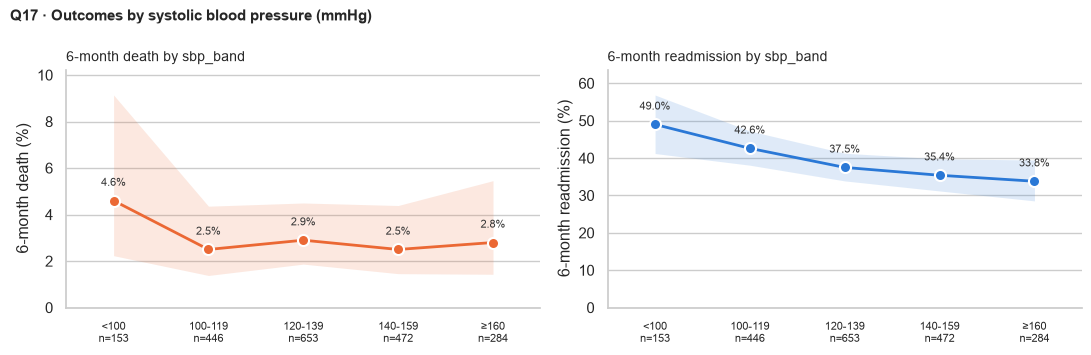

In [37]:
df["sbp_band"] = pd.cut(df["systolic_blood_pressure"], [0, 100, 120, 140, 160, 400], right=False,
                        labels=["<100", "100-119", "120-139", "140-159", "≥160"])
display(two_outcomes("sbp_band", suptitle="Q17 · Outcomes by systolic blood pressure (mmHg)"))
display(adjusted_or("re_admission_within_6_months ~ I(systolic_blood_pressure/10) + age_mid + male + nyha + glomerular_filtration_rate",
                    show=["systolic"]))
print("OR per 10 mmHg higher systolic pressure")

**Chart type — Q17**
* **Trend line with 95% CI band** — *6-month death (left) and readmission (right) by systolic BP band.* How to read it: each dot is the event rate (%) in one group, joined in the groups' natural order; the shaded band is the 95% Wilson confidence interval and n is printed under each group. A line that climbs or falls step by step means a dose–response; a wide band means few patients or few events in that group.

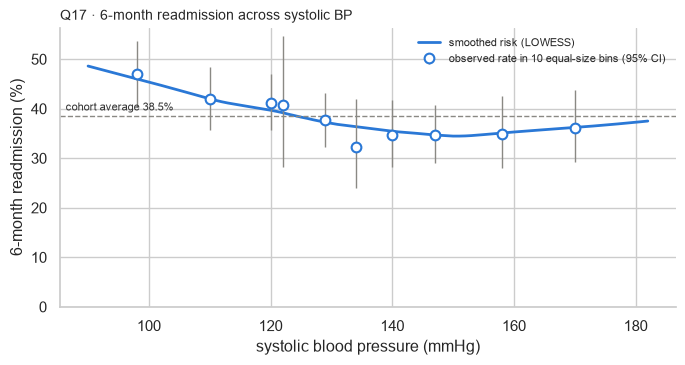

In [38]:
# Q17 · Extra chart: continuous readmission risk curve across systolic BP
fig, ax = plt.subplots(figsize=(7, 3.8))
risk_curve("systolic_blood_pressure", READM, ax=ax, title="Q17 · 6-month readmission across systolic BP")
ax.set_xlabel("systolic blood pressure (mmHg)")
plt.tight_layout(); plt.show()

**Chart type — Q17 (additional charts)**
* **Risk curve (binned rates + LOWESS smooth)** — *6-month readmission across systolic blood pressure.* How to read it: the marker is kept continuous instead of being cut into groups. Open dots are the observed event rate in equal-size bins of the marker (with 95% CI); the solid line is a LOWESS smooth of the risk; the dashed line is the cohort average. It reveals the shape of the risk — straight, threshold or U-shaped. Only the central 95 % of values is shown, because sparse tails make the smooth unreliable.

In [ ]:
# Q17 · Correlation: Spearman rank correlation between the markers and outcomes of this question
display(spearman_table(["systolic_blood_pressure"], [READM, DEATH]))

marker,correlated with,Spearman ρ,direction,strength,p-value,significant (p < 0.05),n
systolic_blood_pressure,6-month readmission,-0.083,negative (−),negligible,0.00021,yes,2008
systolic_blood_pressure,6-month death,-0.019,negative (−),negligible,0.39,no,2008


**Correlation:** Systolic BP correlates negatively with **readmission (ρ = −0.08, p = 0.0002)** but **not with death (ρ = −0.02, p = 0.39)**.

**Evidence:** readmission falls steadily as systolic pressure rises — **49.0 % (< 100 mmHg) → 33.8 % (≥ 160)** (trend p = 0.0002). After adjusting for age, sex, NYHA and eGFR, every 10 mmHg higher SBP lowers readmission odds by **6.4 % (OR 0.936, 0.900–0.973)**. Death is not significantly different across bands (p = 0.72).

**How it influences HF / action:** low blood pressure reflects a weak pump and limits the use of protective drugs, so these patients are discharged fragile. Patients with SBP < 100 need careful up-titration of therapy and early follow-up rather than aggressive vasodilation.

---
## Q18. Does systemic inflammation (neutrophil-to-lymphocyte ratio) predict death?
**Markers chosen:** `neutrophil_count` / `lymphocyte_count` (NLR) → 6-month death

**Why these markers / how they influence HF:** Stress hormones in decompensated HF raise neutrophils and lower lymphocytes; infection (a common trigger of decompensation) does the same.
The **NLR** combines both into a cheap inflammation marker from a routine blood count.

              min    max
nlr_quartile            
Q1 low        0.7    3.3
Q2            3.3    5.2
Q3            5.2    8.5
Q4 high       8.5  113.3
6-month death by nlr_quartile: chi-square p = 0.0042 | trend p = 0.00048
nlr: Mann-Whitney p = 0.0001 | AUC for 6-month death = 0.651
                        n  median    Q1     Q3
6-month death = yes    57    7.45  4.59  17.70
no                   1951    5.17  3.25   8.48
                n  events  rate %   95% CI
nlr_quartile                              
Q1 low        502       4     0.8  0.3–2.0
Q2            521      13     2.5  1.5–4.2
Q3            483      19     3.9  2.5–6.1
Q4 high       502      21     4.2  2.8–6.3


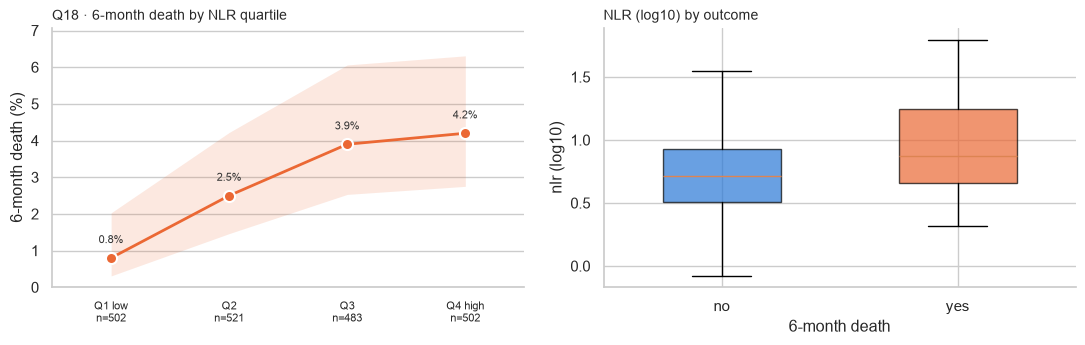

In [39]:
df["nlr"] = df["neutrophil_count"] / df["lymphocyte_count"]
df["nlr_quartile"] = pd.qcut(df["nlr"], 4, labels=["Q1 low", "Q2", "Q3", "Q4 high"])
print(df.groupby("nlr_quartile", observed=True)["nlr"].agg(["min", "max"]).round(1))
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
tab = rate_by("nlr_quartile", DEATH, ax=axes[0], color=ORANGE, title="Q18 · 6-month death by NLR quartile")
display(compare("nlr", DEATH, log=True, ax=axes[1])); axes[1].set_title("NLR (log10) by outcome", loc="left", fontsize=10)
plt.tight_layout(); plt.show(); display(tab)

**Chart types — Q18**
* **Trend line with 95% CI band** — *left: 6-month death by NLR quartile.* How to read it: each dot is the event rate (%) in one group, joined in the groups' natural order; the shaded band is the 95% Wilson confidence interval and n is printed under each group. A line that climbs or falls step by step means a dose–response; a wide band means few patients or few events in that group.
* **Box plot** — *right: NLR (log10) in patients who died vs survived.* How to read it: the box covers the middle 50 % of patients (Q1 to Q3) and the line inside it is the median; whiskers reach the furthest values within 1.5 × IQR (outliers hidden). Compare the medians and how far the boxes overlap.

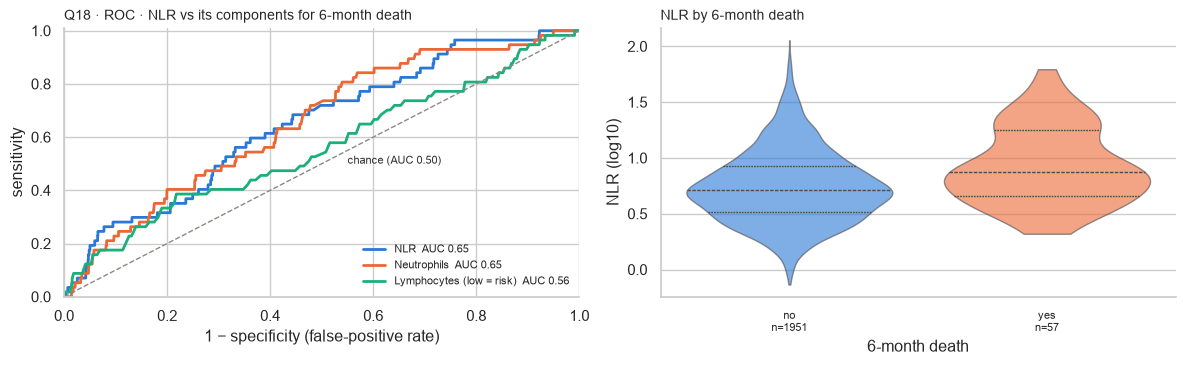

In [40]:
# Q18 · Extra charts: ROC curve for NLR + violin of NLR (log) by death
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
roc_plot({"NLR": "nlr", "Neutrophils": "neutrophil_count", "Lymphocytes (low = risk)": "-lymphocyte_count"},
         DEATH, ax=axes[0], title="Q18 · ROC · NLR vs its components for 6-month death")
violin("nlr", DEATH, log=True, ax=axes[1], title="NLR by 6-month death")
axes[1].set_ylabel("NLR (log10)")
plt.tight_layout(); plt.show()

**Chart types — Q18 (additional charts)**
* **ROC curve** — *left: NLR, neutrophils and lymphocytes (reversed) for 6-month death.* How to read it: plots sensitivity (deaths correctly flagged) against the false-positive rate for every possible cut-off of the marker. The more the curve bows towards the top-left corner the better; the dashed diagonal is chance. The AUC in the legend summarises it (0.5 = chance, 0.7 = acceptable, 0.8 = good, 1 = perfect).
* **Violin plot** — *right: NLR (log10) by 6-month death.* How to read it: the width of each shape shows how many patients have that value (a smoothed distribution); the dashed line is the median and the dotted lines are the quartiles. It shows the whole spread, e.g. whether one group is shifted or has a long tail, not just the average.

In [ ]:
# Q18 · Correlation: Spearman rank correlation between the markers and outcomes of this question
display(spearman_table(["nlr", "neutrophil_count", "lymphocyte_count"], [DEATH]))

marker,correlated with,Spearman ρ,direction,strength,p-value,significant (p < 0.05),n
nlr,6-month death,0.087,positive (+),negligible,9.7e-05,yes,2008
neutrophil_count,6-month death,0.089,positive (+),negligible,6.7e-05,yes,2008
lymphocyte_count,6-month death,-0.034,negative (−),negligible,0.12,no,2008


**Correlation:** NLR (ρ = +0.09, p = 10⁻⁴) and neutrophil count (ρ = +0.09, p = 7 × 10⁻⁵) correlate positively with death; lymphocyte count alone does not (ρ = −0.03, p = 0.12) — the neutrophil side drives the signal.

**Evidence:** death rises across NLR quartiles — **0.8 % (NLR ≤ 3.3) → 4.2 % (NLR > 8.5)** (trend p = 0.0005). Patients who died had a median NLR of 7.5 vs 5.2 (AUC 0.65).

**How it influences HF / action:** inflammation and stress-hormone activation accompany severe decompensation and infection. NLR is free (it comes from the routine blood count) and a value > 8.5 identifies a 5-fold higher-risk group.

---
## Q19. Is C-reactive protein (inflammation) linked to longer stays and death?
**Markers chosen:** `high_sensitivity_protein` (hs-CRP, mg/L) → `dischargeday`, 6-month death

**Why these markers / how they influence HF:** CRP rises with **infection and inflammation**. If infection triggered the decompensation, treatment takes longer and the risk is higher.
CRP was measured in only 47 % of patients (probably those suspected of infection), so results apply to the tested subgroup.

           count  median  mean
crp_group                     
<5 normal    306     8.0   9.2
5-19         331     8.0  10.0
≥20 high     304     9.0  11.1
Kruskal-Wallis p (length of stay) = 3.6e-05
6-month death by crp_group: chi-square p = 0.024 | trend p = 0.0096
Spearman rho(high_sensitivity_protein, dischargeday) = 0.139, p = 1.8e-05, n = 941


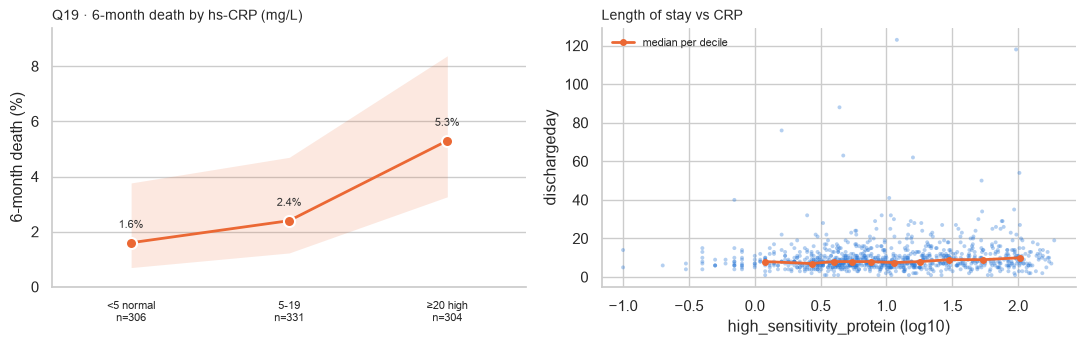

In [41]:
d = df.dropna(subset=["high_sensitivity_protein"]).copy()
d["crp_group"] = pd.cut(d["high_sensitivity_protein"], [0, 5, 20, 1000], right=False, labels=["<5 normal", "5-19", "≥20 high"])
display(d.groupby("crp_group", observed=True)["dischargeday"].agg(["count", "median", "mean"]).round(1))
print("Kruskal-Wallis p (length of stay) =", f"{kruskal(*[g['dischargeday'] for _, g in d.groupby('crp_group', observed=True)]).pvalue:.2g}")
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
rate_by("crp_group", DEATH, data=d, ax=axes[0], color=ORANGE, title="Q19 · 6-month death by hs-CRP (mg/L)")
corr("high_sensitivity_protein", "dischargeday", data=d, ax=axes[1], logx=True)
axes[1].set_title("Length of stay vs CRP", loc="left", fontsize=10); plt.tight_layout(); plt.show()

**Chart types — Q19**
* **Trend line with 95% CI band** — *left: 6-month death by hs-CRP group.* How to read it: each dot is the event rate (%) in one group, joined in the groups' natural order; the shaded band is the 95% Wilson confidence interval and n is printed under each group. A line that climbs or falls step by step means a dose–response; a wide band means few patients or few events in that group.
* **Scatter plot with binned-median trend line** — *right: length of stay against hs-CRP (log10).* How to read it: each blue dot is one patient; the orange line joins the median y-value within each tenth (decile) of x, so it shows the trend without being pulled by outliers. The Spearman ρ printed above the chart gives its strength.

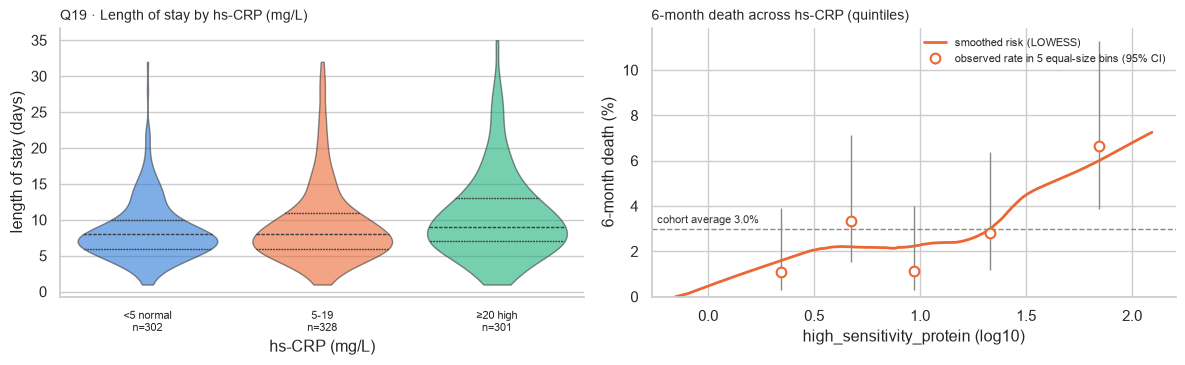

In [42]:
# Q19 · Extra charts: length-of-stay violins by CRP group + continuous death-risk curve (CRP subset)
d = df.dropna(subset=["high_sensitivity_protein"]).copy()
d["crp_group"] = pd.cut(d["high_sensitivity_protein"], [0, 5, 20, 1000], right=False, labels=["<5 normal", "5-19", "≥20 high"])
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
violin("dischargeday", "crp_group", data=d, ax=axes[0], clip_q=0.99, title="Q19 · Length of stay by hs-CRP (mg/L)")
axes[0].set_ylabel("length of stay (days)"); axes[0].set_xlabel("hs-CRP (mg/L)")
risk_curve("high_sensitivity_protein", DEATH, data=d, logx=True, bins=5, ax=axes[1], title="6-month death across hs-CRP (quintiles)")
plt.tight_layout(); plt.show()

**Chart types — Q19 (additional charts)**
* **Violin plot** — *left: length of stay by hs-CRP group.* How to read it: the width of each shape shows how many patients have that value (a smoothed distribution); the dashed line is the median and the dotted lines are the quartiles. It shows the whole spread, e.g. whether one group is shifted or has a long tail, not just the average.
* **Risk curve (binned rates + LOWESS smooth)** — *right: 6-month death across hs-CRP (log10), 5 bins.* How to read it: the marker is kept continuous instead of being cut into groups. Open dots are the observed event rate in equal-size bins of the marker (with 95% CI); the solid line is a LOWESS smooth of the risk; the dashed line is the cohort average. It reveals the shape of the risk — straight, threshold or U-shaped. Only the central 95 % of values is shown, because sparse tails make the smooth unreliable.

In [ ]:
# Q19 · Correlation: Spearman rank correlation between the markers and outcomes of this question
display(spearman_table(["high_sensitivity_protein"], ["dischargeday", DEATH]))

marker,correlated with,Spearman ρ,direction,strength,p-value,significant (p < 0.05),n
high_sensitivity_protein,length of stay (days),0.139,positive (+),weak,1.8e-05,yes,941
high_sensitivity_protein,6-month death,0.096,positive (+),negligible,0.0034,yes,941


**Correlation:** In the 941 patients with a CRP result, CRP correlates positively with **length of stay (ρ = +0.14, p = 2 × 10⁻⁵)** and with **6-month death (ρ = +0.10, p = 0.003)**.

**Evidence:** in the 941 patients with CRP, higher CRP means **longer stays** (median 9 days when CRP ≥ 20 vs 8 when < 5; Kruskal–Wallis p = 4 × 10⁻⁵; ρ = 0.14) and higher 6-month death (trend p = 0.01).

**How it influences HF / action:** infection is a common trigger of decompensation and slows recovery. A high CRP on admission should prompt a search for (and early treatment of) infection, which may shorten the stay.

---
## Q20. Does D-dimer (clotting activation) predict death?
**Markers chosen:** `d_dimer` (mg/L; reference < 0.55) → 6-month death

**Why these markers / how they influence HF:** HF causes **blood stasis** in dilated chambers and veins, and immobility adds risk — so clots (pulmonary embolism, stroke) are common.
D-dimer rises when clots form and break down, and also with inflammation. We test whether it adds prognostic information.

6-month death by ddimer_group: chi-square p = 3.5e-05 | trend p = 5.9e-06
6-month readmission by ddimer_group: chi-square p = 0.00066 | trend p = 0.00053
             6-month death                         6-month readmission                         
                         n events rate %    95% CI                   n events rate %     95% CI
ddimer_group                                                                                   
<0.55 normal           101      1    1.0   0.2–5.4                 101     41   40.6  31.5–50.3
0.55-1.99             1384     29    2.1   1.5–3.0                1384    556   40.2  37.6–42.8
2-4.99                 355     13    3.7   2.2–6.2                 355    136   38.3  33.4–43.5
≥5                     168     14    8.3  5.0–13.5                 168     40   23.8  18.0–30.8
d_dimer: Mann-Whitney p = 0.00023 | AUC for 6-month death = 0.643
                        n  median    Q1    Q3
6-month death = yes    57    1.89  1.13  4.60
no              

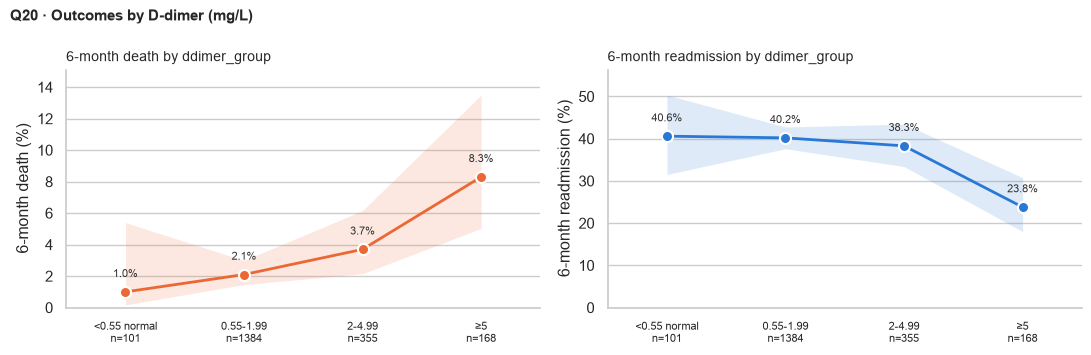

In [43]:
df["ddimer_group"] = pd.cut(df["d_dimer"], [0, 0.55, 2, 5, 1000], right=False, labels=["<0.55 normal", "0.55-1.99", "2-4.99", "≥5"])
display(two_outcomes("ddimer_group", suptitle="Q20 · Outcomes by D-dimer (mg/L)"))
display(compare("d_dimer", DEATH))

**Chart type — Q20**
* **Trend line with 95% CI band** — *6-month death (left) and readmission (right) by D-dimer band.* How to read it: each dot is the event rate (%) in one group, joined in the groups' natural order; the shaded band is the 95% Wilson confidence interval and n is printed under each group. A line that climbs or falls step by step means a dose–response; a wide band means few patients or few events in that group.

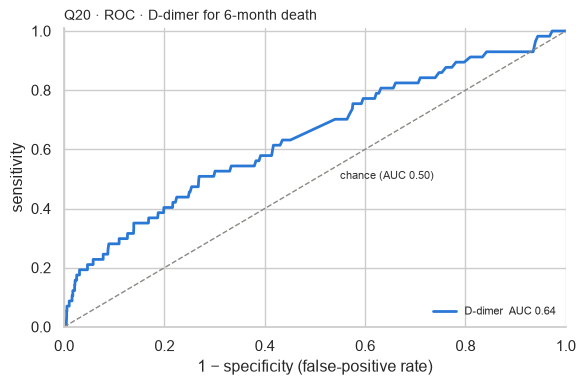

In [44]:
# Q20 · Extra chart: ROC curve for D-dimer
fig, ax = plt.subplots(figsize=(6, 4))
roc_plot({"D-dimer": "d_dimer"}, DEATH, ax=ax, title="Q20 · ROC · D-dimer for 6-month death")
plt.tight_layout(); plt.show()

**Chart type — Q20 (additional charts)**
* **ROC curve** — *D-dimer for 6-month death.* How to read it: plots sensitivity (deaths correctly flagged) against the false-positive rate for every possible cut-off of the marker. The more the curve bows towards the top-left corner the better; the dashed diagonal is chance. The AUC in the legend summarises it (0.5 = chance, 0.7 = acceptable, 0.8 = good, 1 = perfect).

In [ ]:
# Q20 · Correlation: Spearman rank correlation between the markers and outcomes of this question
display(spearman_table(["d_dimer"], [DEATH, READM]))

marker,correlated with,Spearman ρ,direction,strength,p-value,significant (p < 0.05),n
d_dimer,6-month death,0.082,positive (+),negligible,0.00022,yes,2008
d_dimer,6-month readmission,-0.067,negative (−),negligible,0.0025,yes,2008


**Correlation:** D-dimer correlates **positively with death (ρ = +0.08, p = 0.0002)** but **negatively with readmission (ρ = −0.07, p = 0.003)** — the competing-risk pattern: the sickest patients die rather than come back.

**Evidence:** 6-month death rises with D-dimer — **1.0 % (normal) → 2.1 % → 3.7 % → 8.3 % (≥ 5 mg/L)** (trend p = 6 × 10⁻⁶); median D-dimer is 1.9 in deaths vs 1.2 in survivors (AUC 0.64). Interestingly, readmission is *lower* at D-dimer ≥ 5 (23.8 %), probably because these very sick patients die before they can be readmitted (competing risk).

**How it influences HF / action:** clotting activation marks high-risk patients. Very high D-dimer should prompt assessment for pulmonary embolism/thrombus and review of anticoagulation.

---
## Q21. Does right-sided failure congest the liver?
**Markers chosen:** `type_of_heart_failure` vs `total_bilirubin`, `glutamyltranspeptidase` (GGT), `albumin`

**Why these markers / how they influence HF:** When the **right ventricle** fails, pressure backs up into the veins and the liver (**congestive hepatopathy**), raising bilirubin and GGT
(cholestatic pattern) and lowering albumin production. If liver markers are higher in right/biventricular failure, they can be used to
monitor congestion.

                        median (Both)  median (Left)  median (Right) Kruskal-Wallis p
marker                                                                               
total_bilirubin                  18.3           17.2            22.6          0.00065
glutamyltranspeptidase           39.0           39.0            43.0             0.14
albumin                          36.8           36.9            37.3             0.15
type_of_heart_failure
Both     1480
Left      477
Right      51
Name: count, dtype: int64


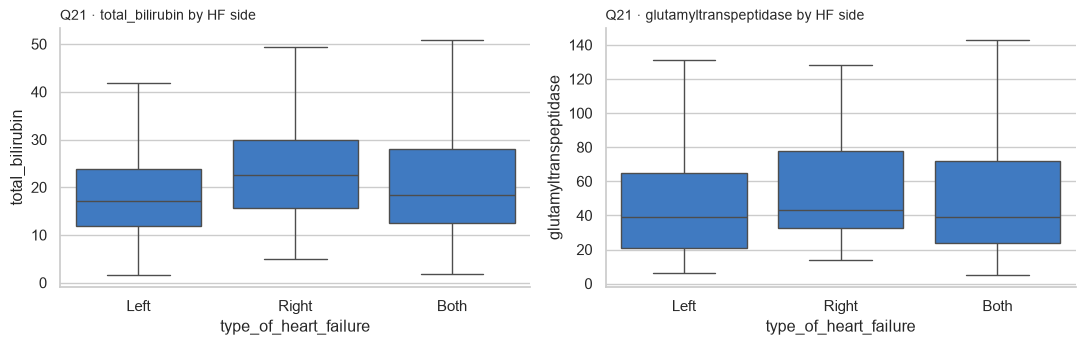

In [45]:
rows = []
for v in ["total_bilirubin", "glutamyltranspeptidase", "albumin"]:
    d = df[["type_of_heart_failure", v]].dropna()
    groups = [g[v] for _, g in d.groupby("type_of_heart_failure")]
    med = d.groupby("type_of_heart_failure")[v].median()
    rows.append({"marker": v, **{f"median ({k})": round(m, 1) for k, m in med.items()},
                 "Kruskal-Wallis p": f"{kruskal(*groups).pvalue:.2g}"})
display(pd.DataFrame(rows).set_index("marker"))
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, v in zip(axes, ["total_bilirubin", "glutamyltranspeptidase"]):
    sns.boxplot(data=df, x="type_of_heart_failure", y=v, order=["Left", "Right", "Both"], ax=ax, color=BLUE, showfliers=False)
    ax.set_title(f"Q21 · {v} by HF side", loc="left", fontsize=10)
plt.tight_layout(); plt.show()
print(df["type_of_heart_failure"].value_counts())

**Chart type — Q21**
* **Box plot** — *total bilirubin (left) and GGT (right) by side of heart failure.* How to read it: the box covers the middle 50 % of patients (Q1 to Q3) and the line inside it is the median; whiskers reach the furthest values within 1.5 × IQR (outliers hidden). Compare the medians and how far the boxes overlap.

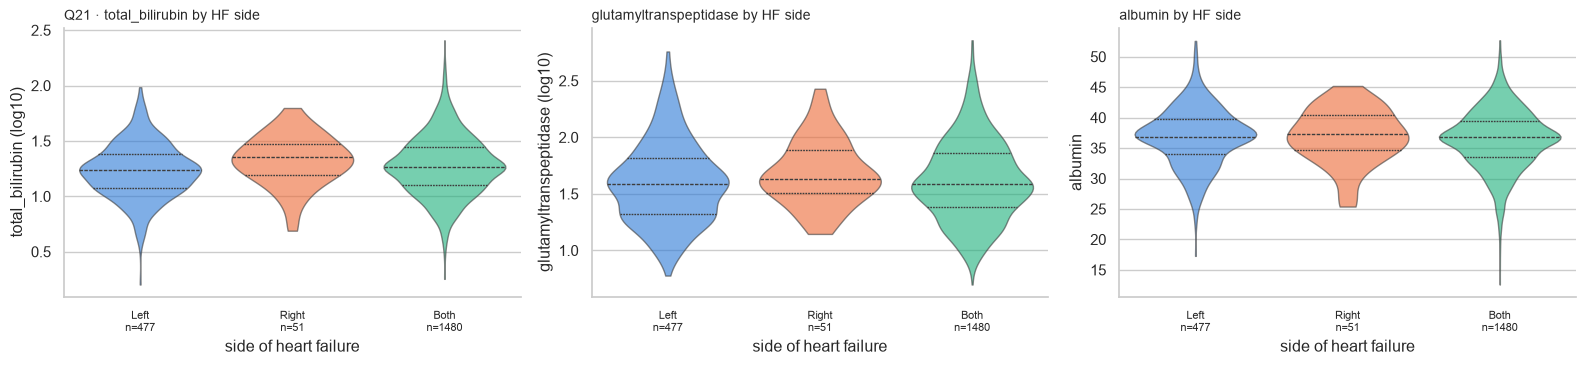

In [46]:
# Q21 · Extra charts: violins of liver markers by side of heart failure
fig, axes = plt.subplots(1, 3, figsize=(16, 3.8))
for ax, v, lg in zip(axes, ["total_bilirubin", "glutamyltranspeptidase", "albumin"], [True, True, False]):
    violin(v, "type_of_heart_failure", order=["Left", "Right", "Both"], log=lg, ax=ax, title=f"{v} by HF side")
    ax.set_xlabel("side of heart failure")
axes[0].set_title("Q21 · total_bilirubin by HF side", loc="left", fontsize=10)
plt.tight_layout(); plt.show()

**Chart type — Q21 (additional charts)**
* **Violin plot** — *total bilirubin (log10), GGT (log10) and albumin by side of heart failure.* How to read it: the width of each shape shows how many patients have that value (a smoothed distribution); the dashed line is the median and the dotted lines are the quartiles. It shows the whole spread, e.g. whether one group is shifted or has a long tail, not just the average.

In [ ]:
# Q21 · Correlation: Spearman rank correlation between the markers and outcomes of this question
df["right_sided_hf"] = df["type_of_heart_failure"].isin(["Right", "Both"]).astype(int).where(df["type_of_heart_failure"].notna())
LABEL["right_sided_hf"] = "right-sided involvement (Right/Both = 1)"
display(spearman_table(["total_bilirubin", "glutamyltranspeptidase", "albumin"], ["right_sided_hf"]))

marker,correlated with,Spearman ρ,direction,strength,p-value,significant (p < 0.05),n
total_bilirubin,right-sided involvement (Right/Both = 1),0.076,positive (+),negligible,0.00063,yes,2008
glutamyltranspeptidase,right-sided involvement (Right/Both = 1),0.029,positive (+),negligible,0.2,no,2008
albumin,right-sided involvement (Right/Both = 1),-0.039,negative (−),negligible,0.078,no,2008


**Correlation:** Only **bilirubin** correlates with right-sided involvement (ρ = +0.08, p = 0.0006); GGT (p = 0.20) and albumin (p = 0.08) do not — matching the group comparison.

**Evidence:** **bilirubin is highest in right-sided HF** (median 22.6 µmol/L) vs biventricular (18.3) and left-sided (17.2) (Kruskal–Wallis p = 0.0007). GGT and albumin do not differ significantly (p = 0.14, p = 0.15). Note only 51 patients have isolated right HF.

**How it influences HF / action:** backward pressure from the right heart congests the liver and raises bilirubin — congestive hepatopathy. Bilirubin can be used to monitor venous congestion in right/biventricular failure; the GGT/albumin pattern is not strong enough here to use.

---
## Q22. Among patients who had a blood gas, do lactate and pH identify those who die?
**Markers chosen:** `lactate`, `ph` (blood gas subset) → 6-month death

**Why these markers / how they influence HF:** **Lactate** rises when tissues lack oxygen (poor perfusion); a low **pH** (acidosis) reflects the same problem or CO₂ retention. Both are
markers of shock. Blood gases were taken in about half of patients (`had_blood_gas`), so results describe the tested subgroup.

Blood-gas subgroup: n = 993, 6-month deaths = 38
6-month death by lactate_group: chi-square p = 8e-06 | trend p = 0.00011
6-month death by acidosis: chi-square p = 2.2e-05
                 n  events  rate %    95% CI
lactate_group                               
<2 normal      551      14     2.5   1.5–4.2
2-3.9          361      13     3.6   2.1–6.1
≥4 high         81      11    13.6  7.8–22.7
                   n  events  rate %    95% CI
acidosis                                      
<7.35 acidosis   110      13    11.8  7.0–19.2
7.35-7.44        577      16     2.8   1.7–4.5
≥7.45 alkalosis  306       9     2.9   1.6–5.5


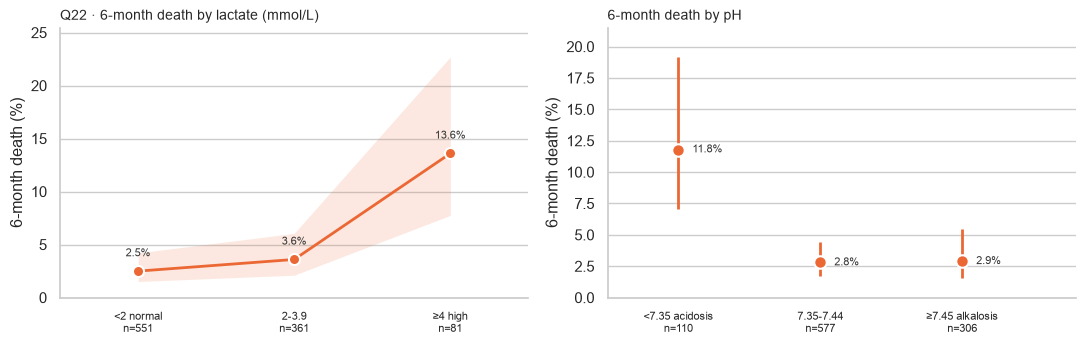

In [47]:
d = df[df["had_blood_gas"] == 1].copy()
print(f"Blood-gas subgroup: n = {len(d)}, 6-month deaths = {int(d[DEATH].sum())}")
d["lactate_group"] = pd.cut(d["lactate"], [0, 2, 4, 100], right=False, labels=["<2 normal", "2-3.9", "≥4 high"])
d["acidosis"] = pd.cut(d["ph"], [0, 7.35, 7.45, 10], right=False, labels=["<7.35 acidosis", "7.35-7.44", "≥7.45 alkalosis"])
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
t1 = rate_by("lactate_group", DEATH, data=d, ax=axes[0], color=ORANGE, title="Q22 · 6-month death by lactate (mmol/L)")
t2 = rate_by("acidosis", DEATH, data=d, ax=axes[1], ordered=False, color=ORANGE, title="6-month death by pH")
plt.tight_layout(); plt.show()
display(t1, t2)

**Chart types — Q22**
* **Trend line with 95% CI band** — *left: 6-month death by lactate band.* How to read it: each dot is the event rate (%) in one group, joined in the groups' natural order; the shaded band is the 95% Wilson confidence interval and n is printed under each group. A line that climbs or falls step by step means a dose–response; a wide band means few patients or few events in that group.
* **Dot plot with 95% CI whiskers** — *right: 6-month death by pH band (unordered categories).* How to read it: each dot is the event rate (%) in one group; the groups have no natural order, so they are not joined. The vertical whisker is the 95% Wilson confidence interval — when two groups' whiskers do not overlap, the difference is unlikely to be chance.

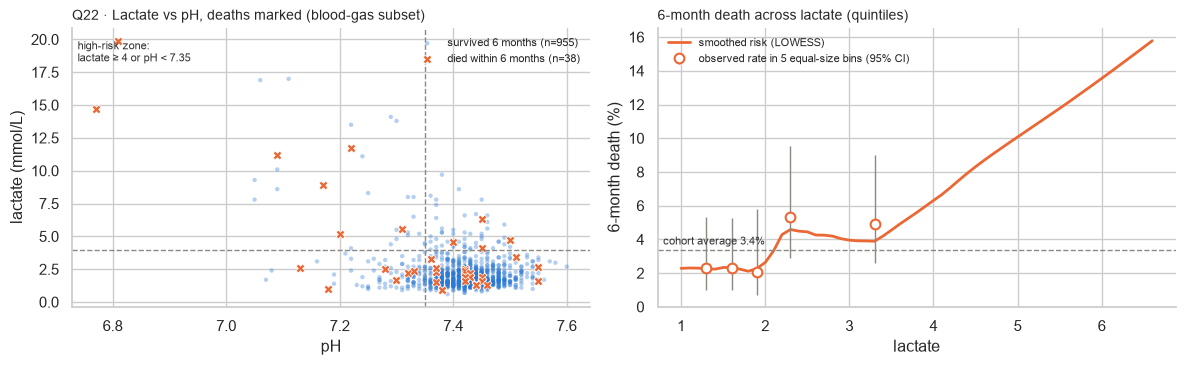

In [48]:
# Q22 · Extra charts: lactate vs pH scatter coloured by death + continuous lactate risk curve
d = df[df["had_blood_gas"] == 1].dropna(subset=["lactate", "ph"])
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
alive, died = d[d[DEATH] == 0], d[d[DEATH] == 1]
axes[0].scatter(alive["ph"], alive["lactate"], s=10, alpha=0.35, color=BLUE, edgecolors="none", label=f"survived 6 months (n={len(alive)})")
axes[0].scatter(died["ph"], died["lactate"], s=40, marker="X", color=ORANGE, edgecolors="white", lw=0.5, label=f"died within 6 months (n={len(died)})")
axes[0].axhline(4, color=GREY, ls="--", lw=1); axes[0].axvline(7.35, color=GREY, ls="--", lw=1)
axes[0].annotate("high-risk zone:\nlactate ≥ 4 or pH < 7.35", (axes[0].get_xlim()[0], axes[0].get_ylim()[1]), xytext=(4, -24),
                 textcoords="offset points", fontsize=8, color=INK)
axes[0].set_xlabel("pH"); axes[0].set_ylabel("lactate (mmol/L)"); axes[0].legend(frameon=False, fontsize=8, loc="upper right")
axes[0].set_title("Q22 · Lactate vs pH, deaths marked (blood-gas subset)", loc="left", fontsize=10)
risk_curve("lactate", DEATH, data=d, bins=5, ax=axes[1], title="6-month death across lactate (quintiles)")
plt.tight_layout(); plt.show()

**Chart types — Q22 (additional charts)**
* **Scatter plot with outcome highlighted** — *left: lactate against pH in the blood-gas subset, deaths marked.* How to read it: each point is one patient; orange crosses are patients who died within 6 months and blue dots survived. Dashed lines mark clinical thresholds, so you can see whether deaths cluster beyond them.
* **Risk curve (binned rates + LOWESS smooth)** — *right: 6-month death across lactate, 5 bins.* How to read it: the marker is kept continuous instead of being cut into groups. Open dots are the observed event rate in equal-size bins of the marker (with 95% CI); the solid line is a LOWESS smooth of the risk; the dashed line is the cohort average. It reveals the shape of the risk — straight, threshold or U-shaped. Only the central 95 % of values is shown, because sparse tails make the smooth unreliable.

In [ ]:
# Q22 · Correlation: Spearman rank correlation between the markers and outcomes of this question
display(spearman_table(["lactate", "ph"], [DEATH], data=df[df["had_blood_gas"] == 1]))

marker,correlated with,Spearman ρ,direction,strength,p-value,significant (p < 0.05),n
lactate,6-month death,0.100,positive (+),negligible,0.0017,yes,993
ph,6-month death,-0.078,negative (−),negligible,0.015,yes,993


**Correlation:** In the blood-gas subset, **lactate correlates positively (ρ = +0.10, p = 0.002)** and **pH negatively (ρ = −0.08, p = 0.015)** with 6-month death — hypoperfusion and acidosis go with mortality.

**Evidence:** in the 993 patients with a blood gas (38 deaths): lactate ≥ 4 mmol/L carries **13.6 % 6-month mortality vs 2.5 % with normal lactate** (trend p = 0.0001), and acidosis (pH < 7.35) carries **11.8 % vs 2.8 %** (p = 2 × 10⁻⁵).

**How it influences HF / action:** high lactate and acidosis mean tissues are not getting enough oxygen — hypoperfusion/shock. A lactate ≥ 4 or pH < 7.35 should escalate care. (These apply to the tested subgroup; blood gases are not taken in everyone.)

---
# D. Comorbidities and other organs (Q23–Q27)

---
## Q23. Do COPD and type II respiratory failure (CO₂ retention) worsen HF outcomes?
**Markers chosen:** `chronic_obstructive_pulmonary_disease`, `type_ii_respiratory_failure`, `partial_pressure_of_carbon_dioxide`

**Why these markers / how they influence HF:** COPD and HF share symptoms and aggravate each other: hypoxia raises lung pressures (right heart strain), and **type II respiratory failure**
(high CO₂) means breathing itself is failing. We first check that the type II flag matches the measured pCO₂, then test outcomes.

type_ii_respiratory_failure
0    34.0
1    39.0
Name: median pCO2 (mmHg), dtype: float64
6-month death by resp_group: chi-square p = 0.0004 | trend p = 0.0029
6-month readmission by resp_group: chi-square p = 0.62 | trend p = 0.44
                      6-month death                         6-month readmission                         
                                  n events rate %    95% CI                   n events rate %     95% CI
resp_group                                                                                              
Neither                        1691     43    2.5   1.9–3.4                1691    655   38.7  36.4–41.1
COPD only                       203      4    2.0   0.8–5.0                 203     79   38.9  32.5–45.8
Type II resp. failure           114     10    8.8  4.8–15.4                 114     39   34.2  26.1–43.3


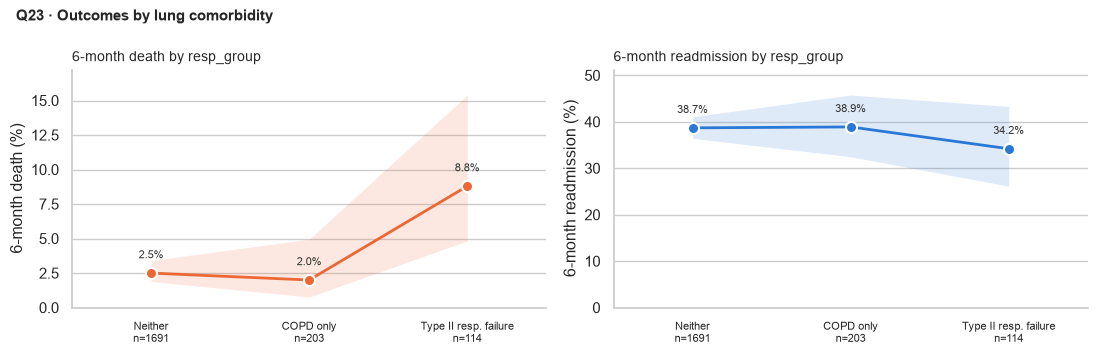

In [49]:
print(df.groupby("type_ii_respiratory_failure")["partial_pressure_of_carbon_dioxide"].median().rename("median pCO2 (mmHg)"))
df["resp_group"] = np.select([df["type_ii_respiratory_failure"] == 1, df["chronic_obstructive_pulmonary_disease"] == 1],
                             ["Type II resp. failure", "COPD only"], "Neither")
df["resp_group"] = pd.Categorical(df["resp_group"], ["Neither", "COPD only", "Type II resp. failure"], ordered=True)
display(two_outcomes("resp_group", suptitle="Q23 · Outcomes by lung comorbidity"))

**Chart type — Q23**
* **Trend line with 95% CI band** — *6-month death (left) and readmission (right) by lung comorbidity group.* How to read it: each dot is the event rate (%) in one group, joined in the groups' natural order; the shaded band is the 95% Wilson confidence interval and n is printed under each group. A line that climbs or falls step by step means a dose–response; a wide band means few patients or few events in that group.

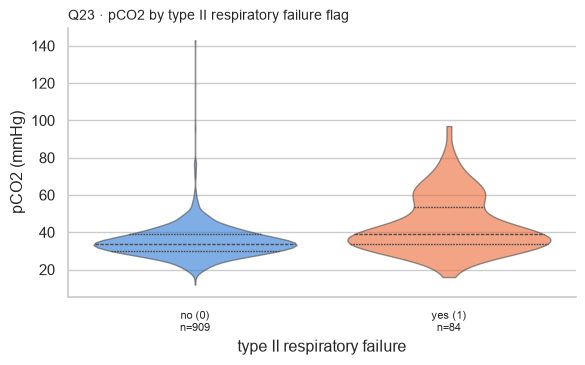

In [50]:
# Q23 · Extra chart: pCO2 distribution by type II respiratory failure flag (violin)
fig, ax = plt.subplots(figsize=(6, 3.8))
violin("partial_pressure_of_carbon_dioxide", "type_ii_respiratory_failure", ax=ax, title="Q23 · pCO2 by type II respiratory failure flag")
ax.set_xticklabels([t.get_text().replace("no", "no (0)").replace("yes", "yes (1)") for t in ax.get_xticklabels()], fontsize=8)
ax.set_xlabel("type II respiratory failure"); ax.set_ylabel("pCO2 (mmHg)")
plt.tight_layout(); plt.show()

**Chart type — Q23 (additional charts)**
* **Violin plot** — *pCO2 in patients with vs without the type II respiratory-failure flag.* How to read it: the width of each shape shows how many patients have that value (a smoothed distribution); the dashed line is the median and the dotted lines are the quartiles. It shows the whole spread, e.g. whether one group is shifted or has a long tail, not just the average.

In [ ]:
# Q23 · Correlation: Spearman rank correlation between the markers and outcomes of this question
display(spearman_table(["chronic_obstructive_pulmonary_disease", "type_ii_respiratory_failure", "partial_pressure_of_carbon_dioxide"], [DEATH, READM]))

marker,correlated with,Spearman ρ,direction,strength,p-value,significant (p < 0.05),n
chronic_obstructive_pulmonary_disease,6-month death,-0.024,negative (−),negligible,0.27,no,2008
chronic_obstructive_pulmonary_disease,6-month readmission,-0.002,negative (−),negligible,0.92,no,2008
type_ii_respiratory_failure,6-month death,0.088,positive (+),negligible,8.4e-05,yes,2008
type_ii_respiratory_failure,6-month readmission,-0.022,negative (−),negligible,0.33,no,2008
partial_pressure_of_carbon_dioxide,6-month death,0.018,positive (+),negligible,0.58,no,993
partial_pressure_of_carbon_dioxide,6-month readmission,-0.058,negative (−),negligible,0.066,no,993


**Correlation:** The **type II respiratory-failure flag correlates with death (ρ = +0.09, p = 8 × 10⁻⁵)**; COPD itself does not (ρ = −0.02, p = 0.27), and neither does measured pCO₂ as a continuous value (p = 0.58). No lung marker correlates with readmission.

**Evidence:** the type II respiratory-failure flag matches the measurements (median pCO₂ 39 vs 34 mmHg). Type II respiratory failure carries **8.8 % 6-month mortality vs 2.5 %** in patients with neither lung condition (p = 0.0004), whereas COPD without CO₂ retention does **not** raise risk (2.0 %). Readmission does not differ (p = 0.62).

**How it influences HF / action:** it is not COPD itself but **ventilatory failure** (CO₂ retention) that marks danger. These patients need respiratory co-management and careful oxygen targets to avoid worsening CO₂ retention.

---
## Q24. Are diabetic HF patients readmitted more often, and is this explained by their kidneys?
**Markers chosen:** `diabetes`, `glomerular_filtration_rate` → 6-month readmission

**Why these markers / how they influence HF:** Diabetes damages heart muscle directly (diabetic cardiomyopathy), accelerates coronary disease and damages the kidneys. We test whether
diabetes raises readmission, and then adjust for eGFR to see whether the effect runs **through the kidneys**.

6-month death by diabetes_label: chi-square p = 1
6-month readmission by diabetes_label: chi-square p = 0.00032
               6-month death                        6-month readmission                         
                           n events rate %   95% CI                   n events rate %     95% CI
diabetes_label                                                                                  
diabetes                 466     13    2.8  1.6–4.7                 466    213   45.7  41.2–50.2
no diabetes             1542     44    2.9  2.1–3.8                1542    560   36.3  34.0–38.7
Median eGFR: {'diabetes': 60.7, 'no diabetes': 64.8}
Logistic regression (n = 2008): re_admission_within_6_months ~ diabetes + age_mid + male
             OR  CI low  CI high    p
diabetes  1.493    1.21    1.842  0.0
Logistic regression (n = 2008): re_admission_within_6_months ~ diabetes + glomerular_filtration_rate + age_mid + male
                               OR  CI low  CI high    p
diabetes   

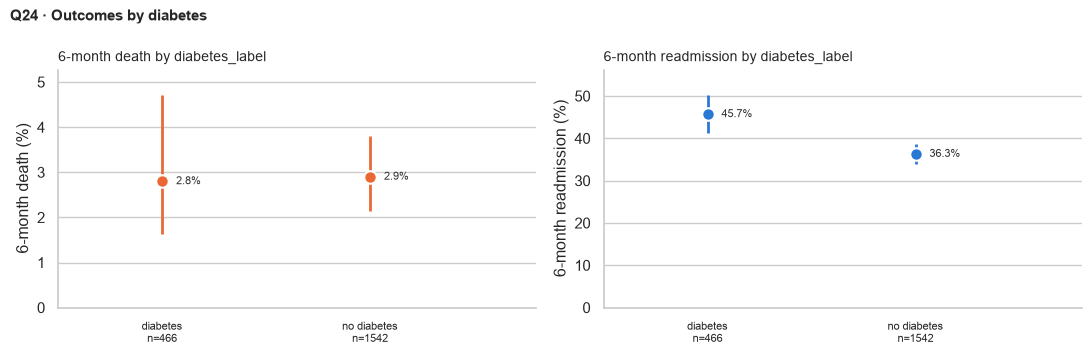

In [51]:
df["diabetes_label"] = df["diabetes"].map({1: "diabetes", 0: "no diabetes"})
display(two_outcomes("diabetes_label", ordered=False, suptitle="Q24 · Outcomes by diabetes"))
print("Median eGFR:", df.groupby("diabetes_label")["glomerular_filtration_rate"].median().round(1).to_dict())
display(adjusted_or("re_admission_within_6_months ~ diabetes + age_mid + male", show=["diabetes"]))
display(adjusted_or("re_admission_within_6_months ~ diabetes + glomerular_filtration_rate + age_mid + male", show=["diabetes", "glomerular"]))

**Chart type — Q24**
* **Dot plot with 95% CI whiskers** — *6-month death (left) and readmission (right), diabetes vs no diabetes.* How to read it: each dot is the event rate (%) in one group; the groups have no natural order, so they are not joined. The vertical whisker is the 95% Wilson confidence interval — when two groups' whiskers do not overlap, the difference is unlikely to be chance.

Logistic regression (n = 2008): re_admission_within_6_months ~ diabetes
Logistic regression (n = 2008): re_admission_within_6_months ~ diabetes + age_mid + male
Logistic regression (n = 2008): re_admission_within_6_months ~ diabetes + glomerular_filtration_rate + age_mid + male


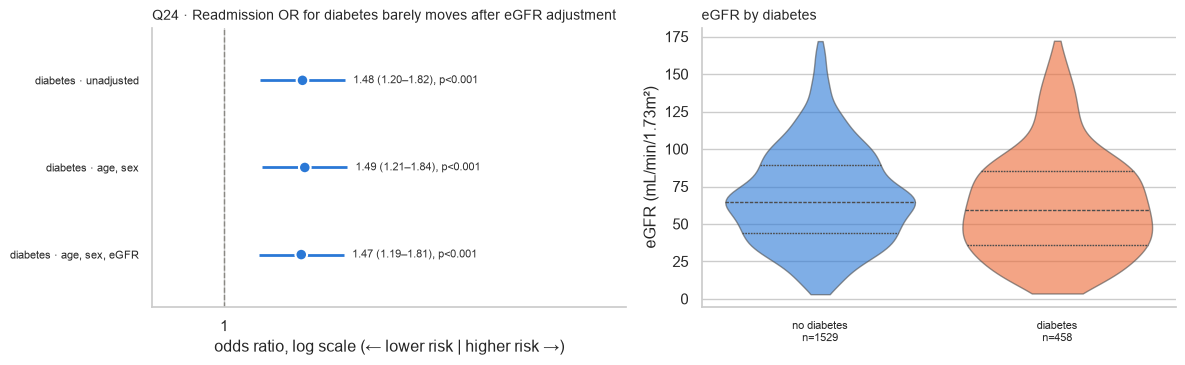

In [52]:
# Q24 · Extra charts: forest plot unadjusted vs eGFR-adjusted OR for diabetes + eGFR violin
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
ors = pd.concat([
    adjusted_or("re_admission_within_6_months ~ diabetes", show=["diabetes"]).rename(index={"diabetes": "diabetes · unadjusted"}),
    adjusted_or("re_admission_within_6_months ~ diabetes + age_mid + male", show=["diabetes"]).rename(index={"diabetes": "diabetes · age, sex"}),
    adjusted_or("re_admission_within_6_months ~ diabetes + glomerular_filtration_rate + age_mid + male", show=["diabetes"])
        .rename(index={"diabetes": "diabetes · age, sex, eGFR"})])
forest(ors, ax=axes[0], title="Q24 · Readmission OR for diabetes barely moves after eGFR adjustment")
violin("glomerular_filtration_rate", "diabetes_label", order=["no diabetes", "diabetes"], ax=axes[1], clip_q=0.99, title="eGFR by diabetes")
axes[1].set_ylabel("eGFR (mL/min/1.73m²)"); axes[1].set_xlabel("")
plt.tight_layout(); plt.show()

**Chart types — Q24 (additional charts)**
* **Forest plot** — *left: OR of readmission for diabetes — unadjusted, adjusted for age/sex, and also for eGFR.* How to read it: each dot is an odds ratio (OR) from a logistic regression, with its 95% CI as a horizontal line, on a log scale. The dashed line at OR = 1 means no association; to the right = higher odds of the outcome, to the left = lower. Blue = the CI excludes 1 (statistically significant), grey = not significant. The value, CI and p-value are written beside each line.
* **Violin plot** — *right: eGFR by diabetes.* How to read it: the width of each shape shows how many patients have that value (a smoothed distribution); the dashed line is the median and the dotted lines are the quartiles. It shows the whole spread, e.g. whether one group is shifted or has a long tail, not just the average.

In [ ]:
# Q24 · Correlation: Spearman rank correlation between the markers and outcomes of this question
display(spearman_table(["diabetes"], [READM, DEATH, "glomerular_filtration_rate"]))

marker,correlated with,Spearman ρ,direction,strength,p-value,significant (p < 0.05),n
diabetes,6-month readmission,0.081,positive (+),negligible,0.00026,yes,2008
diabetes,6-month death,-0.002,negative (−),negligible,0.94,no,2008
diabetes,glomerular_filtration_rate,-0.059,negative (−),negligible,0.0083,yes,2008


**Correlation:** Diabetes correlates positively with **readmission (ρ = +0.08, p = 0.0003)**, not with death (p = 0.94), and only negligibly with eGFR (ρ = −0.06) — which explains why adjusting for eGFR barely changes the diabetes effect.

**Evidence:** diabetes does not change death (2.8 % vs 2.9 %), but **readmission is 45.7 % vs 36.3 %** (p = 0.0003). Diabetics have lower eGFR (61 vs 65), yet the effect **persists after adjusting for eGFR**, age and sex (**OR 1.47, 95 % CI 1.19–1.81**) — almost unchanged from the unadjusted 1.49.

**How it influences HF / action:** diabetes raises readmission through pathways other than the kidneys (e.g. diabetic cardiomyopathy, coronary disease, fluid retention). Diabetic HF patients are a clear target for readmission-prevention; SGLT2 inhibitors (which treat both) are guideline-recommended but were not in this hospital's drug list.

---
## Q25. Does the overall comorbidity burden (Charlson index) raise readmission?
**Markers chosen:** `cci_score` → 6-month readmission and death

**Why these markers / how they influence HF:** Each additional chronic disease adds its own reasons to come back to hospital. The Charlson index is a validated summary of that burden.
A dose-response (higher score → more readmission) would support using CCI for discharge planning.

6-month death by cci_group: chi-square p = 0.15 | trend p = 0.14
6-month readmission by cci_group: chi-square p = 0.00031 | trend p = 0.00013
          6-month death                         6-month readmission                         
                      n events rate %    95% CI                   n events rate %     95% CI
cci_group                                                                                   
0-1                 826     21    2.5   1.7–3.9                 826    294   35.6  32.4–38.9
2                   704     19    2.7   1.7–4.2                 704    263   37.4  33.9–41.0
3                   368     10    2.7   1.5–4.9                 368    155   42.1  37.2–47.2
≥4                  110      7    6.4  3.1–12.6                 110     61   55.5  46.1–64.4


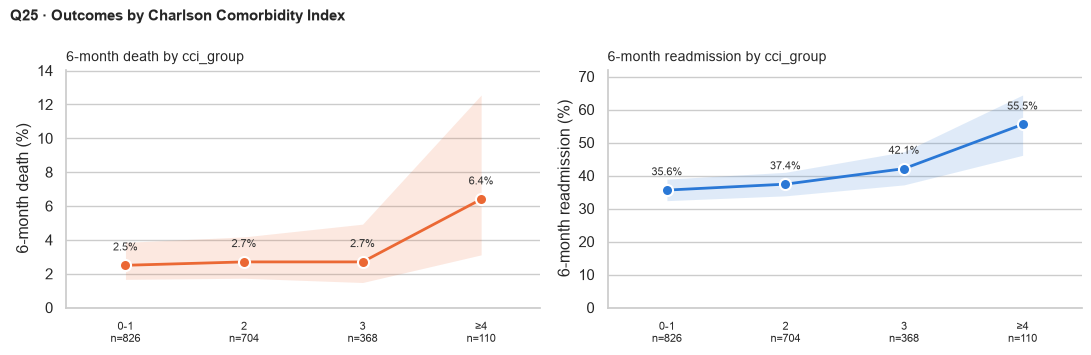

In [53]:
df["cci_group"] = pd.cut(df["cci_score"], [-1, 1, 2, 3, 10], labels=["0-1", "2", "3", "≥4"])
display(two_outcomes("cci_group", suptitle="Q25 · Outcomes by Charlson Comorbidity Index"))

**Chart type — Q25**
* **Trend line with 95% CI band** — *6-month death (left) and readmission (right) by Charlson index group.* How to read it: each dot is the event rate (%) in one group, joined in the groups' natural order; the shaded band is the 95% Wilson confidence interval and n is printed under each group. A line that climbs or falls step by step means a dose–response; a wide band means few patients or few events in that group.

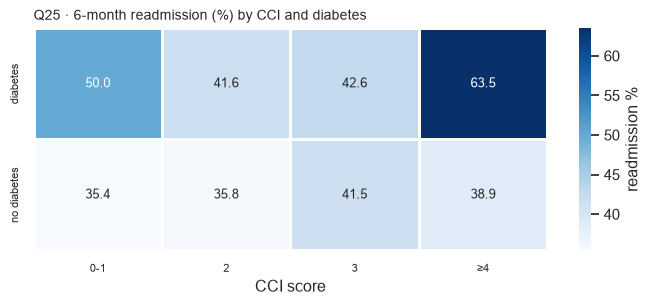

In [54]:
# Q25 · Extra chart: readmission heatmap by Charlson index and diabetes
fig, ax = plt.subplots(figsize=(7, 3.2))
hm = df.pivot_table(index="diabetes_label", columns="cci_group", values=READM, aggfunc="mean", observed=True) * 100
heat(hm, ax=ax, title="Q25 · 6-month readmission (%) by CCI and diabetes", cbar_label="readmission %")
ax.set_xlabel("CCI score"); ax.set_ylabel("")
plt.tight_layout(); plt.show()

**Chart type — Q25 (additional charts)**
* **Heatmap** — *6-month readmission (%) by Charlson index group and diabetes.* How to read it: each cell is shaded by its value on a single-colour scale (darker = higher) and the number is written inside the cell, so you can scan for the darkest corner and still read exact values.

In [ ]:
# Q25 · Correlation: Spearman rank correlation between the markers and outcomes of this question
display(spearman_table(["cci_score"], [READM, DEATH]))

marker,correlated with,Spearman ρ,direction,strength,p-value,significant (p < 0.05),n
cci_score,6-month readmission,0.071,positive (+),negligible,0.0015,yes,2008
cci_score,6-month death,0.015,positive (+),negligible,0.5,no,2008


**Correlation:** The Charlson index correlates positively with **readmission (ρ = +0.07, p = 0.002)** but **not with death (p = 0.5)**.

**Evidence:** readmission rises with comorbidity burden — **35.6 % (CCI 0–1) → 37.3 % → 42.1 % → 55.5 % (CCI ≥ 4)** (trend p = 0.0001). Death is higher only at CCI ≥ 4 (6.4 %) and not significant overall (p = 0.15).

**How it influences HF / action:** each extra chronic disease adds reasons to come back. Patients with CCI ≥ 4 (more than half readmitted within 6 months) need multidisciplinary discharge planning and coordinated follow-up.

---
## Q26. Is chronic liver disease a mortality multiplier in HF?
**Markers chosen:** `liver_disease` vs `total_bilirubin`, `albumin`, `international_normalized_ratio` → 6-month death

**Why these markers / how they influence HF:** The liver makes albumin and clotting factors and clears drugs. Chronic liver disease lowers albumin (oedema), prolongs clotting (bleeding risk
with anticoagulants) and blunts the response to diuretics. It is recorded for 84 patients (4.2 %) — enough to test, but CIs will be wide.

6-month death by liver_label: chi-square p = 4e-05
6-month readmission by liver_label: chi-square p = 0.67
                 6-month death                         6-month readmission                         
                             n events rate %    95% CI                   n events rate %     95% CI
liver_label                                                                                        
liver disease               84      9   10.7  5.7–19.1                  84     30   35.7  26.3–46.4
no liver disease          1924     48    2.5   1.9–3.3                1924    743   38.6  36.5–40.8
                  total_bilirubin  albumin  international_normalized_ratio
liver_label                                                               
liver disease               29.15    36.15                            1.33
no liver disease            18.30    36.80                            1.21
Logistic regression (n = 2008): death_within_6_months ~ liver_disease + age_mid + killip + gl

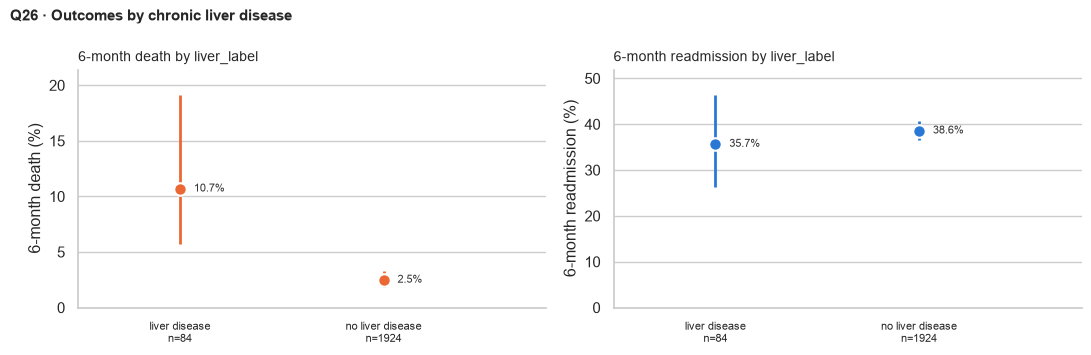

In [55]:
df["liver_label"] = df["liver_disease"].map({1: "liver disease", 0: "no liver disease"})
display(two_outcomes("liver_label", ordered=False, suptitle="Q26 · Outcomes by chronic liver disease"))
display(df.groupby("liver_label")[["total_bilirubin", "albumin", "international_normalized_ratio"]].median().round(2))
display(adjusted_or("death_within_6_months ~ liver_disease + age_mid + killip + glomerular_filtration_rate", show=["liver"]))

**Chart type — Q26**
* **Dot plot with 95% CI whiskers** — *6-month death (left) and readmission (right), liver disease vs none.* How to read it: each dot is the event rate (%) in one group; the groups have no natural order, so they are not joined. The vertical whisker is the 95% Wilson confidence interval — when two groups' whiskers do not overlap, the difference is unlikely to be chance.

Logistic regression (n = 2008): death_within_6_months ~ liver_disease + age_mid + killip + I(glomerular_filtration_rate/10)


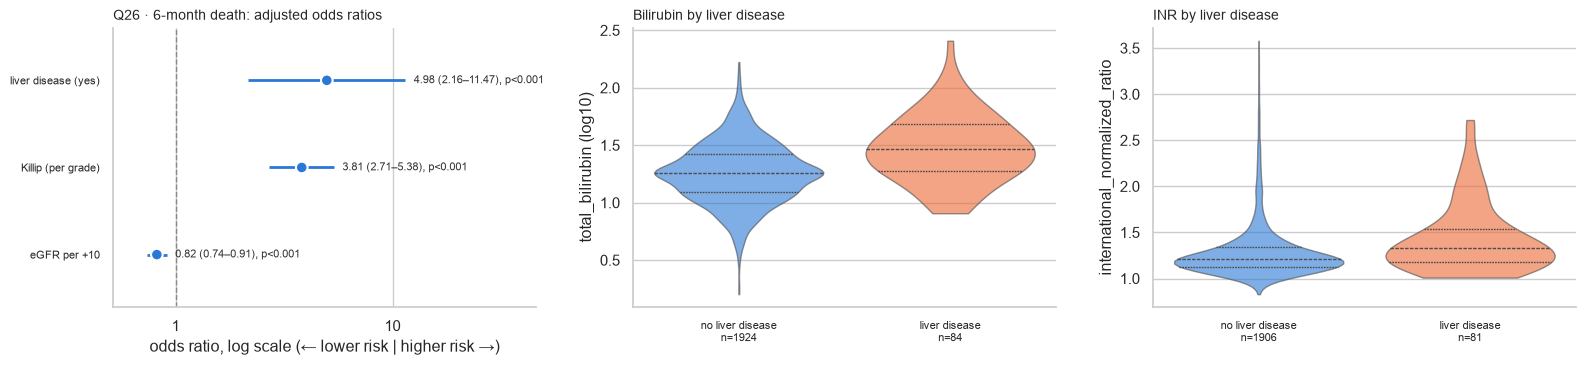

In [56]:
# Q26 · Extra charts: forest plot for liver disease + violins of bilirubin and INR
fig, axes = plt.subplots(1, 3, figsize=(16, 3.8))
ors = adjusted_or("death_within_6_months ~ liver_disease + age_mid + killip + I(glomerular_filtration_rate/10)",
                  show=["liver", "killip", "glomerular"]).rename(index={"liver_disease": "liver disease (yes)", "killip": "Killip (per grade)",
                                                                        "I(glomerular_filtration_rate / 10)": "eGFR per +10"})
forest(ors, ax=axes[0], title="Q26 · 6-month death: adjusted odds ratios")
order = ["no liver disease", "liver disease"]
violin("total_bilirubin", "liver_label", order=order, log=True, ax=axes[1], title="Bilirubin by liver disease"); axes[1].set_xlabel("")
violin("international_normalized_ratio", "liver_label", order=order, ax=axes[2], clip_q=0.99, title="INR by liver disease"); axes[2].set_xlabel("")
plt.tight_layout(); plt.show()

**Chart types — Q26 (additional charts)**
* **Forest plot** — *left: adjusted OR of 6-month death for liver disease, Killip grade and eGFR.* How to read it: each dot is an odds ratio (OR) from a logistic regression, with its 95% CI as a horizontal line, on a log scale. The dashed line at OR = 1 means no association; to the right = higher odds of the outcome, to the left = lower. Blue = the CI excludes 1 (statistically significant), grey = not significant. The value, CI and p-value are written beside each line.
* **Violin plot** — *middle and right: bilirubin (log10) and INR by liver disease.* How to read it: the width of each shape shows how many patients have that value (a smoothed distribution); the dashed line is the median and the dotted lines are the quartiles. It shows the whole spread, e.g. whether one group is shifted or has a long tail, not just the average.

In [ ]:
# Q26 · Correlation: Spearman rank correlation between the markers and outcomes of this question
display(spearman_table(["liver_disease", "total_bilirubin", "albumin", "international_normalized_ratio"], [DEATH]))

marker,correlated with,Spearman ρ,direction,strength,p-value,significant (p < 0.05),n
liver_disease,6-month death,0.099,positive (+),negligible,8.7e-06,yes,2008
total_bilirubin,6-month death,0.012,positive (+),negligible,0.58,no,2008
albumin,6-month death,-0.053,negative (−),negligible,0.018,yes,2008
international_normalized_ratio,6-month death,0.074,positive (+),negligible,0.00092,yes,2008


**Correlation:** **Liver disease correlates with death (ρ = +0.10, p = 9 × 10⁻⁶)**, as do INR (ρ = +0.07, p = 0.0009) and, weakly, low albumin (ρ = −0.05, p = 0.02); bilirubin alone does not (p = 0.58).

**Evidence:** patients with chronic liver disease have **4× higher 6-month mortality (10.7 % vs 2.5 %, p = 4 × 10⁻⁵)**, with higher bilirubin (29.2 vs 18.3 µmol/L) and INR (1.33 vs 1.21). The effect remains after adjusting for age, Killip grade and eGFR (**OR 5.0, 95 % CI 2.2–11.5**). Readmission is not different.

**How it influences HF / action:** combined heart and liver failure reduces the reserve to survive decompensation and complicates drug use (anticoagulants, diuretics). Liver disease is a strong mortality flag; these patients need careful anticoagulation and diuretic dosing and hepatology input.

---
## Q27. Does high serum phosphate identify patients who will die?
**Markers chosen:** `inorganic_phosphorus` (mmol/L; reference 0.85–1.51), `glomerular_filtration_rate` → 6-month death

**Why these markers / how they influence HF:** Phosphate is removed by the kidneys; when kidney function falls it accumulates and drives **vascular calcification** and left-ventricular
hypertrophy (the **CKD–mineral bone disorder** pathway). High phosphate is also released from damaged cells. It was measured in only 407 patients
(20 %), so this is a tested-subgroup analysis with 14 deaths.

6-month death by phos_band: chi-square p = 4.1e-09 | trend p = 1.5e-06
Spearman rho(glomerular_filtration_rate, inorganic_phosphorus) = -0.303, p = 4.2e-10, n = 407
                    n  events  rate %     95% CI
phos_band                                       
<0.85 low          75       0     0.0    0.0–4.9
0.85-1.51 normal  293       6     2.0    0.9–4.4
>1.51 high         39       8    20.5  10.8–35.5
inorganic_phosphorus: Mann-Whitney p = 1.1e-05 | AUC for 6-month death = 0.846
                       n  median    Q1    Q3
6-month death = yes   14    1.70  1.18  2.18
no                   393    1.03  0.90  1.18


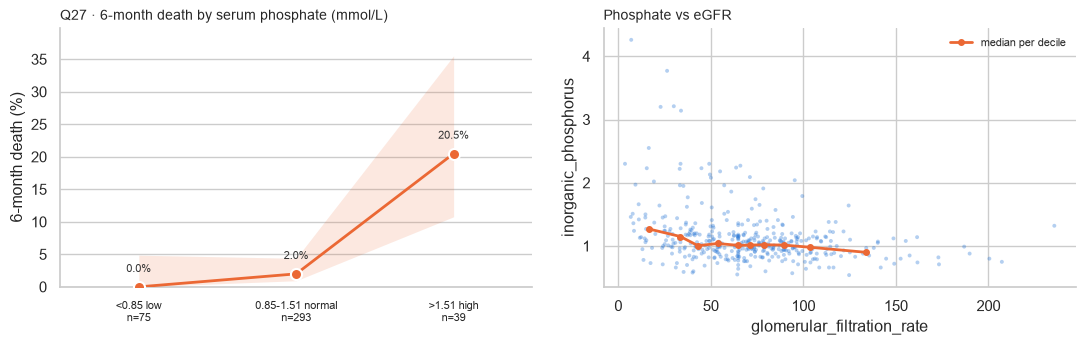

In [57]:
d = df.dropna(subset=["inorganic_phosphorus"]).copy()
d["phos_band"] = pd.cut(d["inorganic_phosphorus"], [0, 0.85, 1.51, 10], labels=["<0.85 low", "0.85-1.51 normal", ">1.51 high"])
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
tab = rate_by("phos_band", DEATH, data=d, ax=axes[0], color=ORANGE, title="Q27 · 6-month death by serum phosphate (mmol/L)")
corr("glomerular_filtration_rate", "inorganic_phosphorus", data=d, ax=axes[1])
axes[1].set_title("Phosphate vs eGFR", loc="left", fontsize=10); plt.tight_layout(); plt.show()
display(tab)
display(compare("inorganic_phosphorus", DEATH, data=d))

**Chart types — Q27**
* **Trend line with 95% CI band** — *left: 6-month death by phosphate band.* How to read it: each dot is the event rate (%) in one group, joined in the groups' natural order; the shaded band is the 95% Wilson confidence interval and n is printed under each group. A line that climbs or falls step by step means a dose–response; a wide band means few patients or few events in that group.
* **Scatter plot with binned-median trend line** — *right: phosphate against eGFR.* How to read it: each blue dot is one patient; the orange line joins the median y-value within each tenth (decile) of x, so it shows the trend without being pulled by outliers. The Spearman ρ printed above the chart gives its strength.

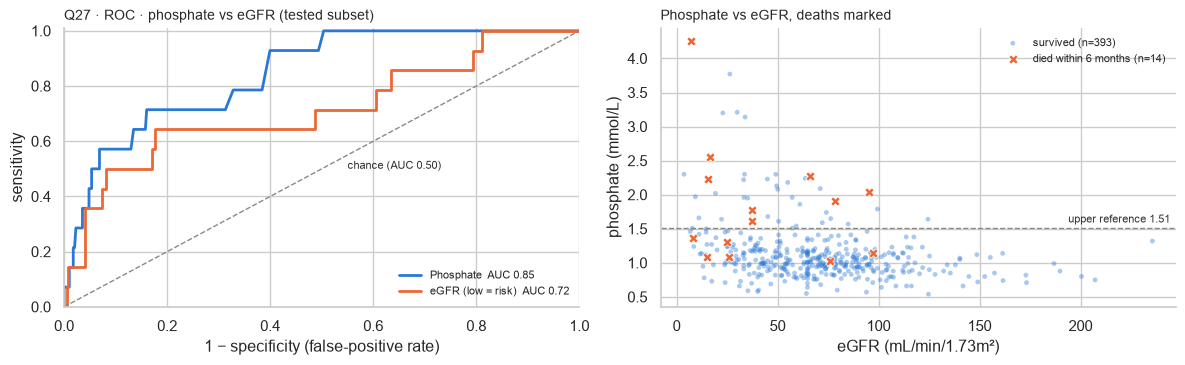

In [58]:
# Q27 · Extra charts: ROC for phosphate vs eGFR + phosphate–eGFR scatter with deaths marked
d = df.dropna(subset=["inorganic_phosphorus"])
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
roc_plot({"Phosphate": "inorganic_phosphorus", "eGFR (low = risk)": "-glomerular_filtration_rate"}, DEATH, data=d, ax=axes[0],
         title="Q27 · ROC · phosphate vs eGFR (tested subset)")
alive, died = d[d[DEATH] == 0], d[d[DEATH] == 1]
axes[1].scatter(alive["glomerular_filtration_rate"], alive["inorganic_phosphorus"], s=12, alpha=0.4, color=BLUE, edgecolors="none", label=f"survived (n={len(alive)})")
axes[1].scatter(died["glomerular_filtration_rate"], died["inorganic_phosphorus"], s=45, marker="X", color=ORANGE, edgecolors="white", lw=0.5, label=f"died within 6 months (n={len(died)})")
axes[1].axhline(1.51, color=GREY, ls="--", lw=1)
axes[1].annotate("upper reference 1.51", (axes[1].get_xlim()[1], 1.51), xytext=(-4, 4), textcoords="offset points", ha="right", fontsize=8, color=INK)
axes[1].set_xlabel("eGFR (mL/min/1.73m²)"); axes[1].set_ylabel("phosphate (mmol/L)"); axes[1].legend(frameon=False, fontsize=8)
axes[1].set_title("Phosphate vs eGFR, deaths marked", loc="left", fontsize=10)
plt.tight_layout(); plt.show()

**Chart types — Q27 (additional charts)**
* **ROC curve** — *left: phosphate vs eGFR for 6-month death (tested subset).* How to read it: plots sensitivity (deaths correctly flagged) against the false-positive rate for every possible cut-off of the marker. The more the curve bows towards the top-left corner the better; the dashed diagonal is chance. The AUC in the legend summarises it (0.5 = chance, 0.7 = acceptable, 0.8 = good, 1 = perfect).
* **Scatter plot with outcome highlighted** — *right: phosphate against eGFR, deaths marked (dashed = 1.51 mmol/L).* How to read it: each point is one patient; orange crosses are patients who died within 6 months and blue dots survived. Dashed lines mark clinical thresholds, so you can see whether deaths cluster beyond them.

In [ ]:
# Q27 · Correlation: Spearman rank correlation between the markers and outcomes of this question
display(spearman_table(["inorganic_phosphorus"], [DEATH, "glomerular_filtration_rate"]))

marker,correlated with,Spearman ρ,direction,strength,p-value,significant (p < 0.05),n
inorganic_phosphorus,6-month death,0.219,positive (+),weak,8.5e-06,yes,407
inorganic_phosphorus,glomerular_filtration_rate,-0.303,negative (−),moderate,4.2e-10,yes,407


**Correlation:** Phosphate correlates positively with **6-month death (ρ = +0.22, p = 9 × 10⁻⁶, n = 407)** — among the strongest marker–death correlations here — and **moderately negatively with eGFR (ρ = −0.30)**.

**Evidence:** in the 407 patients with a phosphate result, **20.5 % of those with high phosphate (> 1.51 mmol/L) died within 6 months vs 2.0 % with normal and 0 % with low phosphate** (trend p = 1.5 × 10⁻⁶). Phosphate alone separates deaths with an **AUC of 0.85** — the highest of any single marker in this notebook — and is linked to kidney function (ρ = −0.30 with eGFR).

**How it influences HF / action:** phosphate retention captures advanced kidney failure and cell damage. Only 20 % were tested (14 deaths, so the CI is wide), but the signal is strong enough to recommend **measuring phosphate routinely** in HF admissions with reduced eGFR.

---
# E. Care pathway and treatment (Q28–Q30)

---
## Q28. What happens to patients who leave hospital against medical advice?
**Markers chosen:** `outcome_during_hospitalization` (`Dischargeagainstorder`) → 28-day death, `dischargeday`

**Why these markers / how they influence HF:** 107 patients (5.3 %) left against medical advice. They leave before stabilisation, so we expect very high early death. If confirmed,
this group needs a specific intervention (counselling, palliative planning, early follow-up call).

28-day death by outcome_during_hospitalization: chi-square p = 2.9e-52
                                   n  events  rate %     95% CI
outcome_during_hospitalization                                 
Alive                           1890       8     0.4    0.2–0.8
Dischargeagainstorder            107      20    18.7  12.4–27.1
Median length of stay: {'Alive': 8.0, 'Dischargeagainstorder': 6.0}
Killip ≥3 share: {'Alive': 21.3, 'Dischargeagainstorder': 38.3}


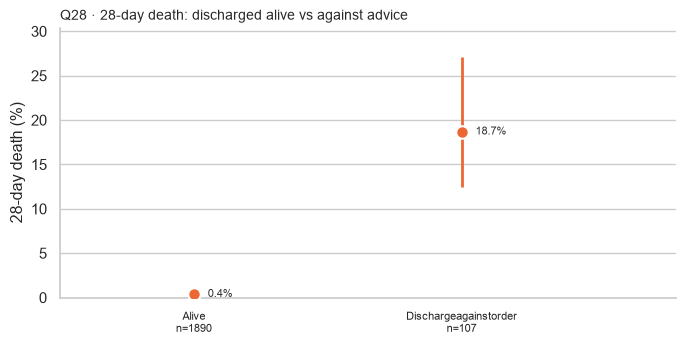

In [59]:
d = df[df["outcome_during_hospitalization"] != "Dead"]     # exclude in-hospital deaths
fig, ax = plt.subplots(figsize=(7, 3.6))
tab = rate_by("outcome_during_hospitalization", "death_within_28_days", data=d, ordered=False, ax=ax, color=ORANGE,
              title="Q28 · 28-day death: discharged alive vs against advice")
plt.tight_layout(); plt.show(); display(tab)
print("Median length of stay:", d.groupby("outcome_during_hospitalization")["dischargeday"].median().to_dict())
print("Killip ≥3 share:", d.groupby("outcome_during_hospitalization")["killip"].apply(lambda s: round((s >= 3).mean()*100, 1)).to_dict())

**Chart type — Q28**
* **Dot plot with 95% CI whiskers** — *28-day death, discharged normally vs left against medical advice.* How to read it: each dot is the event rate (%) in one group; the groups have no natural order, so they are not joined. The vertical whisker is the 95% Wilson confidence interval — when two groups' whiskers do not overlap, the difference is unlikely to be chance.

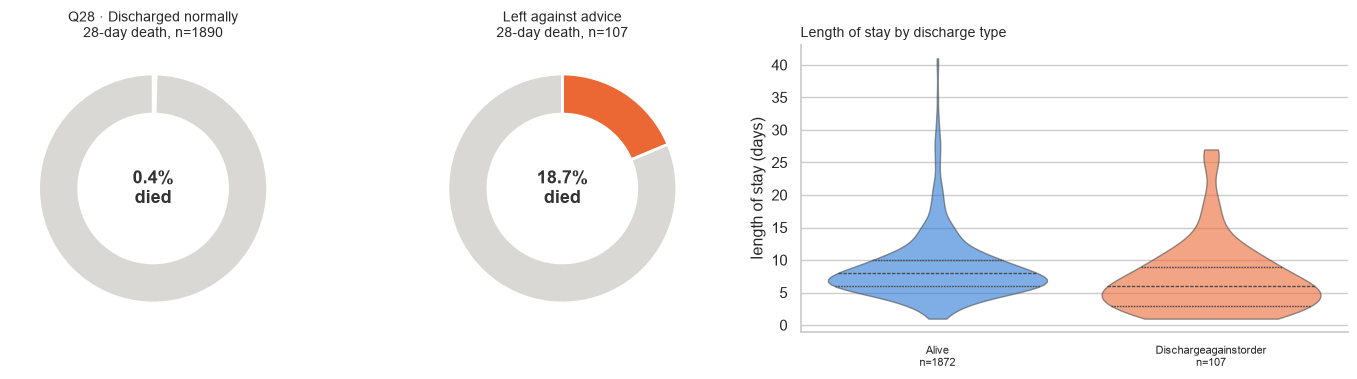

In [60]:
# Q28 · Extra charts: donuts of 28-day death by discharge type + length-of-stay violins
d = df[df["outcome_during_hospitalization"] != "Dead"]
fig = plt.figure(figsize=(14, 3.8)); gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1.6])
for k, grp in enumerate(["Alive", "Dischargeagainstorder"]):
    s = d.loc[d["outcome_during_hospitalization"] == grp, "death_within_28_days"]
    ax = fig.add_subplot(gs[0, k])
    donut(pd.Series([s.sum(), len(s) - s.sum()]), ax,
          title=("Q28 · Discharged normally" if k == 0 else "Left against advice") + f"\n28-day death, n={len(s)}")
ax = fig.add_subplot(gs[0, 2])
violin("dischargeday", "outcome_during_hospitalization", data=d, order=["Alive", "Dischargeagainstorder"], clip_q=0.99, ax=ax,
       title="Length of stay by discharge type")
ax.set_ylabel("length of stay (days)"); ax.set_xlabel("")
plt.tight_layout(); plt.show()

**Chart types — Q28 (additional charts)**
* **Donut chart** — *left and middle: 28-day death, discharged normally vs against advice.* How to read it: the whole ring is 100 % of the group; the orange arc is the share who died within 28 days, with the percentage in the centre. Two donuts side by side compare the groups at a glance.
* **Violin plot** — *right: length of stay by discharge type.* How to read it: the width of each shape shows how many patients have that value (a smoothed distribution); the dashed line is the median and the dotted lines are the quartiles. It shows the whole spread, e.g. whether one group is shifted or has a long tail, not just the average.

In [ ]:
# Q28 · Correlation: Spearman rank correlation between the markers and outcomes of this question
df["against_advice"] = (df["outcome_during_hospitalization"] == "Dischargeagainstorder").astype(int)
display(spearman_table(["against_advice"], ["death_within_28_days", "dischargeday"], data=df[df["outcome_during_hospitalization"] != "Dead"]))

marker,correlated with,Spearman ρ,direction,strength,p-value,significant (p < 0.05),n
against_advice,28-day death,0.350,positive (+),moderate,1.4e-58,yes,1997
against_advice,length of stay (days),-0.117,negative (−),weak,1.7e-07,yes,1997


**Correlation:** Leaving against medical advice is **moderately correlated with 28-day death (ρ = +0.35, p = 10⁻⁵⁸)** — the strongest outcome correlation in the notebook — and negatively with length of stay (ρ = −0.12): these patients leave earlier.

**Evidence:** **18.7 % of patients who left against medical advice died within 28 days**, versus **0.4 %** of those discharged normally (`Dischargeagainstorder` vs `Alive`) (p = 3 × 10⁻⁵²) — a 47-fold difference. They left after a shorter stay (median 6 vs 8 days) and were sicker (Killip ≥ 3 in 38.3 % vs 21.3 %).

**How it influences HF / action:** these patients leave before stabilisation, and many probably leave to die at home (a known cultural pattern in some regions). This group needs a specific protocol: counselling, palliative-care referral where appropriate, and a follow-up call within 48 hours.

---
## Q29. Are patients who received guideline therapy (beta-blocker, ACEi/ARB) readmitted or dying less?
**Markers chosen:** `rx_metoprolol_*`, `rx_benazepril_*`, `rx_valsartan_*` → 6-month death and readmission (adjusted for severity)

**Why these markers / how they influence HF:** Beta-blockers and ACEi/ARBs **block the harmful neurohormonal activation** that drives HF progression and are proven to reduce death and
readmission in HFrEF. Only ~38 % received each (Category 2). This is observational data: sicker patients (low BP, shock, poor kidneys) are
*less likely* to be given these drugs (**confounding by indication**), so we adjust for severity markers before interpreting.

6-month death by gdmt: chi-square p = 0.0074 | trend p = 0.0019
6-month readmission by gdmt: chi-square p = 0.055 | trend p = 0.39
        6-month death                        6-month readmission                         
                    n events rate %   95% CI                   n events rate %     95% CI
gdmt                                                                                     
neither           872     34    3.9  2.8–5.4                 872    316   36.2  33.1–39.5
one               740     20    2.7  1.8–4.1                 740    310   41.9  38.4–45.5
both              396      3    0.8  0.3–2.2                 396    147   37.1  32.5–42.0
Who gets therapy? (medians by group)
         systolic_blood_pressure  glomerular_filtration_rate  killip  age_mid
gdmt                                                                         
neither                    130.0                       60.86     2.0     74.0
one                        130.0                       64.

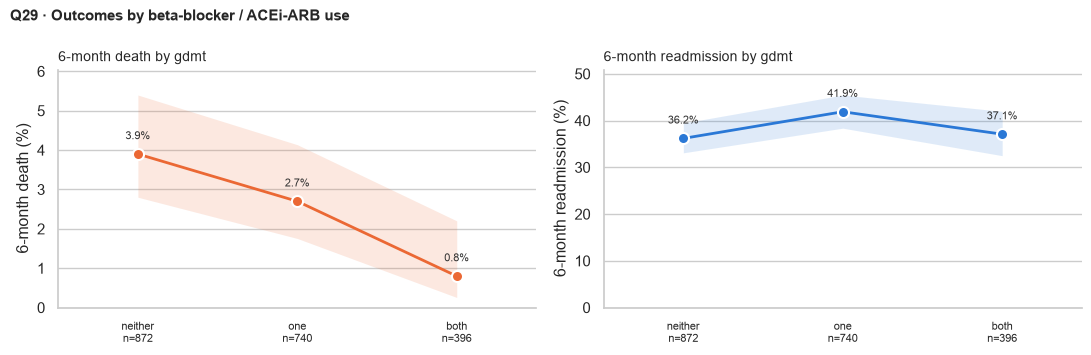

In [61]:
df["beta_blocker"] = ((df["rx_metoprolol_succinate_sustained_release_tablet"] == 1) | (df["rx_metoprolol_tartrate_injection"] == 1)).astype(int)
df["acei_arb"] = ((df["rx_benazepril_hydrochloride_tablet"] == 1) | (df["rx_valsartan_dispersible_tablet"] == 1)).astype(int)
df["gdmt"] = np.select([(df["beta_blocker"] == 1) & (df["acei_arb"] == 1), (df["beta_blocker"] == 1) | (df["acei_arb"] == 1)],
                       ["both", "one"], "neither")
df["gdmt"] = pd.Categorical(df["gdmt"], ["neither", "one", "both"], ordered=True)
display(two_outcomes("gdmt", suptitle="Q29 · Outcomes by beta-blocker / ACEi-ARB use"))
print("Who gets therapy? (medians by group)")
display(df.groupby("gdmt", observed=True)[["systolic_blood_pressure", "glomerular_filtration_rate", "killip", "age_mid"]].median())
display(adjusted_or("death_within_6_months ~ beta_blocker + acei_arb + age_mid + killip + systolic_blood_pressure + glomerular_filtration_rate",
                    show=["beta", "acei"]))
display(adjusted_or("re_admission_within_6_months ~ beta_blocker + acei_arb + age_mid + nyha + glomerular_filtration_rate",
                    show=["beta", "acei"]))

**Chart type — Q29**
* **Trend line with 95% CI band** — *6-month death (left) and readmission (right) by number of guideline drugs (neither / one / both).* How to read it: each dot is the event rate (%) in one group, joined in the groups' natural order; the shaded band is the 95% Wilson confidence interval and n is printed under each group. A line that climbs or falls step by step means a dose–response; a wide band means few patients or few events in that group.

Logistic regression (n = 2008): death_within_6_months ~ beta_blocker + acei_arb + age_mid + killip + systolic_blood_pressure + glomerular_filtration_rate
Logistic regression (n = 2008): re_admission_within_6_months ~ beta_blocker + acei_arb + age_mid + nyha + glomerular_filtration_rate


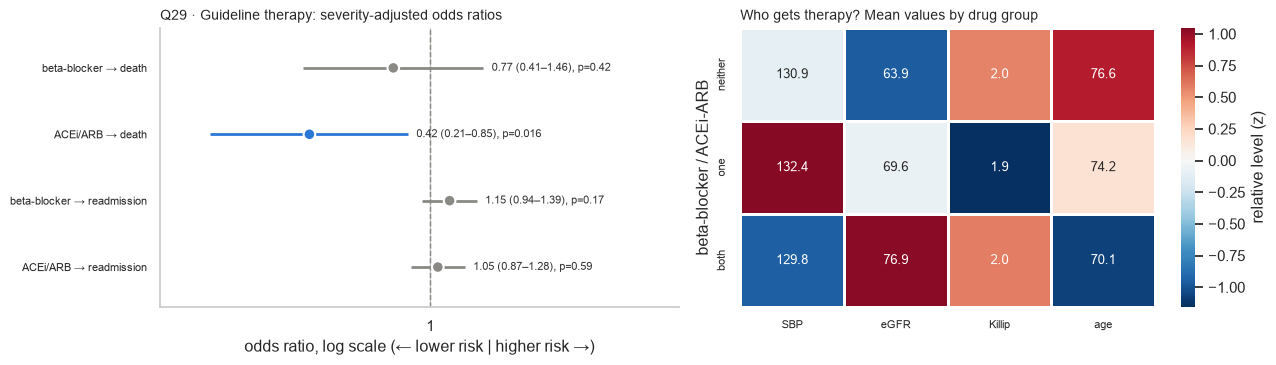

In [62]:
# Q29 · Extra charts: forest plot of adjusted ORs + heatmap showing who receives therapy (confounding)
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
o_d = adjusted_or("death_within_6_months ~ beta_blocker + acei_arb + age_mid + killip + systolic_blood_pressure + glomerular_filtration_rate",
                  show=["beta", "acei"]).rename(index=lambda s: f"{'beta-blocker' if 'beta' in s else 'ACEi/ARB'} → death")
o_r = adjusted_or("re_admission_within_6_months ~ beta_blocker + acei_arb + age_mid + nyha + glomerular_filtration_rate",
                  show=["beta", "acei"]).rename(index=lambda s: f"{'beta-blocker' if 'beta' in s else 'ACEi/ARB'} → readmission")
forest(pd.concat([o_d, o_r]), ax=axes[0], title="Q29 · Guideline therapy: severity-adjusted odds ratios")
cols = {"systolic_blood_pressure": "SBP", "glomerular_filtration_rate": "eGFR", "killip": "Killip", "age_mid": "age"}
avg = df.groupby("gdmt", observed=True)[list(cols)].mean().rename(columns=cols)
z = ((avg - avg.mean()) / avg.std().replace(0, 1)).fillna(0)   # colour = how far each group sits from the others
heat(z, ax=axes[1], annot=avg, fmt=".1f", cmap="RdBu_r", center=0, cbar_label="relative level (z)",
     title="Who gets therapy? Mean values by drug group")
axes[1].set_ylabel("beta-blocker / ACEi-ARB"); axes[1].set_xlabel("")
plt.tight_layout(); plt.show()

**Chart types — Q29 (additional charts)**
* **Forest plot** — *left: severity-adjusted OR of beta-blocker and ACEi/ARB for death and readmission.* How to read it: each dot is an odds ratio (OR) from a logistic regression, with its 95% CI as a horizontal line, on a log scale. The dashed line at OR = 1 means no association; to the right = higher odds of the outcome, to the left = lower. Blue = the CI excludes 1 (statistically significant), grey = not significant. The value, CI and p-value are written beside each line.
* **Diverging heatmap** — *right: mean SBP, eGFR, Killip and age by drug group (who gets therapy).* How to read it: each cell shows the group's actual mean; the colour shows how far that mean sits above (red) or below (blue) the other groups for the same column (z-score), so the columns can be compared even though their units differ.

In [ ]:
# Q29 · Correlation: Spearman rank correlation between the markers and outcomes of this question
df["n_gdmt_drugs"] = df["beta_blocker"] + df["acei_arb"]   # 0, 1 or 2 guideline drugs
display(spearman_table(["n_gdmt_drugs", "beta_blocker", "acei_arb"], [DEATH, READM, "glomerular_filtration_rate"]))

marker,correlated with,Spearman ρ,direction,strength,p-value,significant (p < 0.05),n
n_gdmt_drugs,6-month death,-0.068,negative (−),negligible,0.0024,yes,2008
n_gdmt_drugs,6-month readmission,0.024,positive (+),negligible,0.28,no,2008
n_gdmt_drugs,glomerular_filtration_rate,0.154,positive (+),weak,3.9e-12,yes,2008
beta_blocker,6-month death,-0.041,negative (−),negligible,0.065,no,2008
beta_blocker,6-month readmission,0.022,positive (+),negligible,0.33,no,2008
beta_blocker,glomerular_filtration_rate,0.111,positive (+),weak,6.3e-07,yes,2008
acei_arb,6-month death,-0.067,negative (−),negligible,0.0027,yes,2008
acei_arb,6-month readmission,0.008,positive (+),negligible,0.71,no,2008
acei_arb,glomerular_filtration_rate,0.135,positive (+),weak,1.1e-09,yes,2008


**Correlation:** The number of guideline drugs (0–2) correlates **negatively with death (ρ = −0.07, p = 0.002)**, driven by ACEi/ARB (ρ = −0.07, p = 0.003) rather than beta-blockers (ρ = −0.04, p = 0.07); there is no correlation with readmission. Drug use also **correlates positively with eGFR (ρ = +0.15)** — the confounding by indication that the adjusted model corrects for.

**Evidence:** 6-month death falls from **3.9 % (neither drug) to 2.7 % (one) to 0.8 % (both)** (trend p = 0.002). Patients given both drugs had better kidney function (eGFR 74 vs 61), showing **confounding by indication**. After adjusting for age, Killip, SBP and eGFR, **ACEi/ARB remains associated with lower mortality (OR 0.42, 95 % CI 0.21–0.85, p = 0.016)**; beta-blocker does not reach significance (OR 0.77, p = 0.42). Neither drug is associated with readmission (p = 0.17–0.59).

**How it influences HF / action:** the association is consistent with trial evidence that RAAS blockade improves survival. Because this is observational, it does not prove causation, but it supports prescribing guideline therapy wherever blood pressure and kidney function allow — only 19 % received triple therapy (Category 2).

---
## Q30. Do patients needing IV inotropes represent a distinct high-risk group?
**Markers chosen:** `rx_milrinone_injection`, `rx_dobutamine_hydrochloride_injection` vs BNP, LVEF, outcomes

**Why these markers / how they influence HF:** IV inotropes (milrinone, dobutamine) are given when the heart **cannot pump enough despite diuretics** — low-output HF. Their use is therefore a
marker of the sickest patients. We check that inotrope users really have worse markers (BNP, LVEF, blood pressure) and worse outcomes.

             brain_natriuretic_peptide  lvef  systolic_blood_pressure  dischargeday
inotrope                                                                           
IV inotrope                     1343.5  48.0                    124.0           9.0
no inotrope                      586.7  53.0                    130.0           7.0
brain_natriuretic_peptide: Mann-Whitney p = 4e-46
lvef: Mann-Whitney p = 7.4e-06
systolic_blood_pressure: Mann-Whitney p = 3.1e-10
6-month death by inotrope: chi-square p = 0.041
6-month readmission by inotrope: chi-square p = 0.00056
            6-month death                        6-month readmission                         
                        n events rate %   95% CI                   n events rate %     95% CI
inotrope                                                                                     
IV inotrope           713     28    3.9  2.7–5.6                 713    311   43.6  40.0–47.3
no inotrope          1295     29    2.2  1.6–3.2     

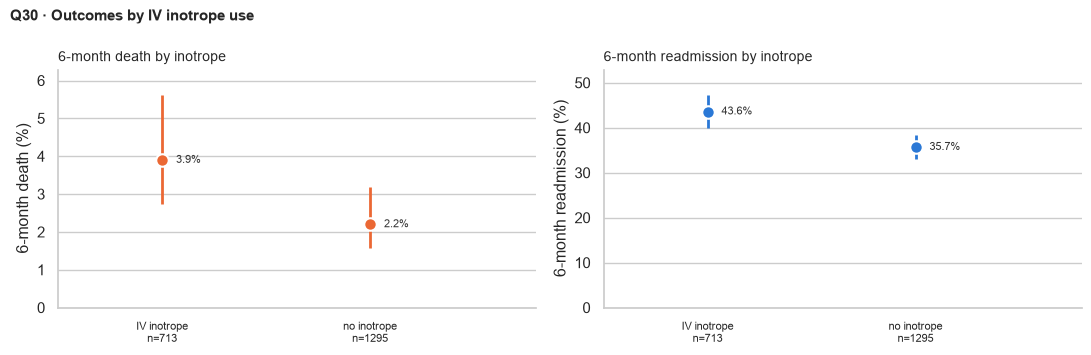

In [63]:
df["inotrope"] = ((df["rx_milrinone_injection"] == 1) | (df["rx_dobutamine_hydrochloride_injection"] == 1)).map({True: "IV inotrope", False: "no inotrope"})
cmp = df.groupby("inotrope")[["brain_natriuretic_peptide", "lvef", "systolic_blood_pressure", "dischargeday"]].median().round(1)
display(cmp)
for v in ["brain_natriuretic_peptide", "lvef", "systolic_blood_pressure"]:
    a_, b_ = [g[v].dropna() for _, g in df.groupby("inotrope")]
    print(f"{v}: Mann-Whitney p = {mannwhitneyu(a_, b_).pvalue:.2g}")
display(two_outcomes("inotrope", ordered=False, suptitle="Q30 · Outcomes by IV inotrope use"))

**Chart type — Q30**
* **Dot plot with 95% CI whiskers** — *6-month death (left) and readmission (right), IV inotrope vs none.* How to read it: each dot is the event rate (%) in one group; the groups have no natural order, so they are not joined. The vertical whisker is the 95% Wilson confidence interval — when two groups' whiskers do not overlap, the difference is unlikely to be chance.

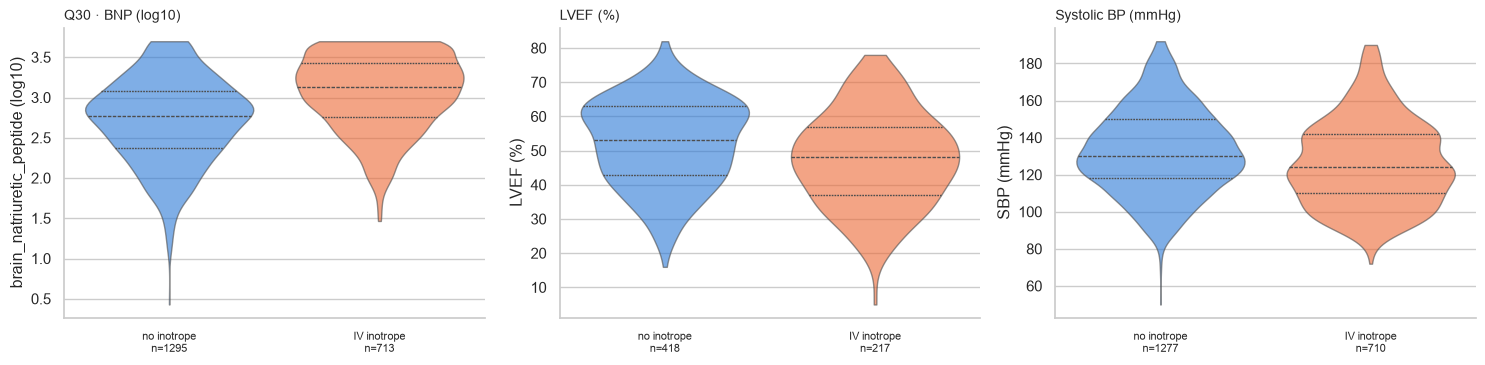

In [64]:
# Q30 · Extra charts: violins of severity markers by inotrope use
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
order = ["no inotrope", "IV inotrope"]
violin("brain_natriuretic_peptide", "inotrope", order=order, log=True, ax=axes[0], title="Q30 · BNP (log10)")
violin("lvef", "inotrope", order=order, ax=axes[1], title="LVEF (%)"); axes[1].set_ylabel("LVEF (%)")
violin("systolic_blood_pressure", "inotrope", order=order, ax=axes[2], clip_q=0.99, title="Systolic BP (mmHg)"); axes[2].set_ylabel("SBP (mmHg)")
for ax in axes:
    ax.set_xlabel("")
plt.tight_layout(); plt.show()

**Chart type — Q30 (additional charts)**
* **Violin plot** — *BNP (log10), LVEF and systolic BP by IV inotrope use.* How to read it: the width of each shape shows how many patients have that value (a smoothed distribution); the dashed line is the median and the dotted lines are the quartiles. It shows the whole spread, e.g. whether one group is shifted or has a long tail, not just the average.

In [ ]:
# Q30 · Correlation: Spearman rank correlation between the markers and outcomes of this question
df["inotrope_flag"] = (df["inotrope"] == "IV inotrope").astype(int)
display(spearman_table(["inotrope_flag"], [DEATH, READM, "brain_natriuretic_peptide", "lvef", "systolic_blood_pressure"]))

marker,correlated with,Spearman ρ,direction,strength,p-value,significant (p < 0.05),n
inotrope_flag,6-month death,0.049,positive (+),negligible,0.029,yes,2008
inotrope_flag,6-month readmission,0.078,positive (+),negligible,0.00046,yes,2008
inotrope_flag,brain_natriuretic_peptide,0.318,positive (+),moderate,1.7e-48,yes,2008
inotrope_flag,lvef,-0.178,negative (−),weak,6.4e-06,yes,635
inotrope_flag,systolic_blood_pressure,-0.140,negative (−),weak,2.6e-10,yes,2008


**Correlation:** Inotrope use correlates **moderately with BNP (ρ = +0.32)** and negatively with LVEF (ρ = −0.18) and systolic BP (ρ = −0.14), and weakly with readmission (ρ = +0.08, p = 0.0005) and death (ρ = +0.05, p = 0.03) — a marker of severity.

**Evidence:** patients given IV inotropes (35.5 %) have much higher BNP (median 1,344 vs 587 pg/mL, p = 4 × 10⁻⁴⁶), lower LVEF (48 % vs 53 %) and lower SBP (124 vs 130 mmHg), stay longer (9 vs 7 days), and have higher **death (3.9 % vs 2.2 %, p = 0.04)** and **readmission (43.6 % vs 35.7 %, p = 0.0006)**.

**How it influences HF / action:** inotrope use identifies a low-output, high-risk group. It should be read as a *severity marker*, not as a harmful drug effect. These patients should be flagged at discharge for early follow-up and consideration of advanced-HF referral.

---
## Transparency check — markers with no clear association
Before summarising, we re-check the demographic and pathway variables that did **not** show an association, so the summary can report
null findings with evidence rather than leaving them out.

In [65]:
null_checks = pd.concat({
    "age group": rate_by("age_group", DEATH),
    "sex": rate_by("gender", DEATH, ordered=False),
    "admission route": rate_by("admission_way", DEATH, ordered=False),
})
display(null_checks)
_ = rate_by("age_group", READM); _ = rate_by("gender", READM, ordered=False); _ = rate_by("admission_way", READM, ordered=False)

6-month death by age_group: chi-square p = 0.88 | trend p = 0.7
6-month death by gender: chi-square p = 0.22
6-month death by admission_way: chi-square p = 0.71
                                 n  events  rate %   95% CI
age group       <69            546      15     2.7  1.7–4.5
                69-79          715      19     2.7  1.7–4.1
                79+            747      23     3.1  2.1–4.6
sex             Female        1163      28     2.4  1.7–3.5
                Male           845      29     3.4  2.4–4.9
admission route Emergency      956      29     3.0  2.1–4.3
                Nonemergency  1052      28     2.7  1.8–3.8
6-month readmission by age_group: chi-square p = 0.087 | trend p = 0.34
6-month readmission by gender: chi-square p = 0.39
6-month readmission by admission_way: chi-square p = 0.96


---
# Summary — which markers influence heart-failure outcomes?

### Strongest mortality markers (6-month death)
| Marker | High-risk group | Death rate (high-risk vs reference) | Evidence |
|---|---|---|---|
| GCS (Q16) | GCS 3–8 | 57.9 % vs 2.1 % | trend p = 10⁻⁴⁹ |
| Killip grade (Q1) | Killip 4 | 26.7 % vs 0.8 % | adj. OR 4.1 per grade |
| Phosphate (Q27) | > 1.51 mmol/L | 20.5 % vs 2.0 % | AUC 0.85 (tested subset) |
| Lactate / pH (Q22) | lactate ≥ 4 / pH < 7.35 | 13.6 % / 11.8 % vs ~2.5 % | blood-gas subset |
| Liver disease (Q26) | yes | 10.7 % vs 2.5 % | adj. OR 5.0 |
| eGFR (Q8) | < 30 | 8.3 % vs 1.6 % | trend p = 10⁻⁵ |
| Type II resp. failure (Q23) | yes | 8.8 % vs 2.5 % | p = 0.0004 |
| D-dimer (Q20) | ≥ 5 mg/L | 8.3 % vs 1.0 % | trend p = 10⁻⁵ |
| Troponin (Q15), BNP (Q3), NLR (Q18), sodium (Q10), uric acid (Q13), LV dilation (Q6) | top group | 4–6 % vs 1–2 % | all trend p < 0.01 |

### Strongest readmission markers (6-month readmission)
| Marker | Readmission (high-risk vs reference) |
|---|---|
| Charlson index ≥ 4 (Q25) | 55.5 % vs 35.6 % |
| eGFR 30–44 (Q8) | 50.0 % vs 30.8 % |
| SBP < 100 (Q17) | 49.0 % vs 33.8 % |
| Uric acid > 600 (Q13) | 46.4 % vs 32.7 % |
| Diabetes (Q24) | 45.7 % vs 36.3 % (adj. OR 1.47) |
| NYHA IV (Q2) | 44.6 % vs 29.2 % |
| High mitral E-wave (Q7) | 39.3 % vs 22.4 % |

### Key patterns
1. **Death and readmission are driven by different markers.** Death follows acute severity (shock, consciousness, perfusion, organ failure); readmission follows chronic burden (kidneys, diabetes, comorbidity, low blood pressure, symptoms). → Category 4 builds **separate models** for each.
2. **The kidneys are central** — eGFR, urea, potassium, phosphate, uric acid and anaemia all point back to cardiorenal syndrome.
3. **HFpEF is not low-risk** (Q6); remodelling (LV dilation) is more prognostic than EF category.
4. **Guideline therapy is under-used** and ACEi/ARB use is associated with lower mortality after adjustment (Q29).
5. **Leaving against medical advice** is the single most dangerous discharge pattern (18.7 % 28-day death, Q28).

### Markers tested that showed *no* clear association (reported for transparency)
Albumin and BMI for death/readmission (Q12), HF phenotype by EF (Q6), age group (6-month death 2.7–3.1 %, p = 0.88), sex (2.4 % women vs 3.4 % men, p = 0.22) and admission route (emergency 3.0 % vs non-emergency 2.7 %, p = 0.71) — see the transparency check above. These nulls matter too: they tell clinicians *not* to rely on age, sex or BMI alone to judge risk in this cohort.

**Caveat:** all findings are associations from one hospital; several subgroup analyses (phosphate, blood gas, GCS 3–8, liver disease) are based on small numbers of deaths and should be confirmed in larger data.

**Data note:** the cleaned file median-imputes columns with < 10 % missing (e.g. BNP, eGFR, albumin, D-dimer). This keeps every patient in each analysis but places imputed patients in the middle group, which slightly weakens contrasts; conclusions were checked to be unchanged in direction versus the non-imputed data except for albumin (Q12), which is no longer statistically associated with death.